# Stroke Prediction - Project Introduction

This project aims to predict stroke occurrence among patients using machine learning techniques, with a focus on minimizing stroke patients among population. By leveraging Gradient Boosted Trees and robust feature engineering, the workflow integrates exploratory data analysis (EDA), statistical inference, and model optimization to identify the most influential predictors and ensure reliable, actionable insights.

**Objectives:**
- Develop a predictive model for stroke risk.
- Explain feature importance and model reasoning.
- Optimize for **sensitivity** (>80% recall) to catch as many positive cases as possible while keeping reasonable **precision** and **accuracy**.
- Validate findings with statistical tests and sensitivity analyses.

**Methods:**
- Perform EDA to understand relationships between variables.
- Use statistical inference to quantify associations between predictors and stroke outcome.
- Engineer features and apply cross-validation for model robustness.
- Tune hyperparameters and compare sampling strategies to address class imbalance and improve average precision.

This approach ensures both generated prediction robustness and practical utility to support data-driven decisions for healthcare strategies.


# Packages

Import necessary packages used in notebook:

In [ ]:
import subprocess
import datetime
import json
import atexit
import os
import random
import warnings
import dill
import eli5
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import PyALE
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from category_encoders import TargetEncoder
from eli5.sklearn import PermutationImportance
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from scipy.stats import (chi2_contingency, loguniform, pointbiserialr,
                         randint, stats, uniform, zscore)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (AdaBoostClassifier, RandomForestClassifier,
                              RandomForestRegressor)
from sklearn.experimental import enable_iterative_imputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, precision_recall_curve)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                     cross_val_score, cross_validate,
                                     train_test_split)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (FunctionTransformer, PolynomialFeatures,
                                   SplineTransformer, StandardScaler)
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError
from sklearn.base import clone
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats import multitest as sms
from scipy.stats import probplot, norm
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

Ignore all warnings generated by code cells for readability:

In [3]:
warnings.filterwarnings("ignore")

In [5]:
"""
Load notebook state from previous saved session.
"""

SESSION_FILE = 'notebook_state.db'
if os.path.exists(SESSION_FILE) and os.path.getsize(SESSION_FILE) > 0:
    try:
        dill.load_session(SESSION_FILE)
        print("Session loaded successfully.")
    except EOFError:
        print(f"Session file '{SESSION_FILE}' is empty or incomplete. Starting fresh.")
    except Exception as e:
        print(f"Failed to load session '{SESSION_FILE}': {e}. Starting fresh.")
else:
    print("No session file found. Starting fresh.")

Session loaded successfully.


In [ ]:
def save_session():
    """Save the current session state to a file."""
    dill.dump_session(SESSION_FILE)
    print("Session saved successfully.")


atexit.register(save_session)

<function __main__.save_session()>

In [ ]:
"""Set random seed for reproducibility."""
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# EDA

## EDA Section Introduction

In this section, we perform Exploratory Data Analysis (EDA) to understand the underlying structure and relationships within the stroke dataset. The goal is to:

- Assess the distribution and balance of the target variable (`stroke`) and key predictors.
- Identify missing values, outliers, and data quality issues.
- Explore associations between predictors and stroke occurrence, both numerically and visually.
- Quantify relationships using statistical summaries and correlation metrics.
- Prepare the data for statistical inference and machine learning modeling by guiding feature engineering and preprocessing choices.

This EDA will provide the foundation for subsequent statistical tests and predictive modeling, ensuring that insights and decisions are justified.

# Data Loading

What to do:
- Load CSV into `df` and inspect first rows, dtypes.
- Convert obvious categorical columns to `category` dtype for clearer summaries and faster grouping operations.

Why:
- Early dtype choices reduce memory and make summaries/tests (chi-square, proportions) straightforward.

In [204]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Data Information

Checks performed:
- df.info(): feature count, dtypes, non-null counts;
- Unique values per categorical predictor (detect rare categories);
- Summary statistics for numeric predictors (min, median, mean, IQR, max).

Outcomes:
- List of numeric vs categorical columns;
- Columns requiring cleaning or aggregation (rare categories → group as "other" if needed);
- Candidates for log / spline transforms (skewed numeric variables).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Check unique variables in predictors:

In [ ]:
df.drop(columns=['id']).apply(pd.Series.unique)

gender                                           [Male, Female, Other]
age                  [67.0, 61.0, 80.0, 49.0, 79.0, 81.0, 74.0, 69....
hypertension                                                    [0, 1]
heart_disease                                                   [1, 0]
ever_married                                                 [Yes, No]
work_type            [Private, Self-employed, Govt_job, children, N...
Residence_type                                          [Urban, Rural]
avg_glucose_level    [228.69, 202.21, 105.92, 171.23, 174.12, 186.2...
bmi                  [36.6, nan, 32.5, 34.4, 24.0, 29.0, 27.4, 22.8...
smoking_status        [formerly smoked, never smoked, smokes, Unknown]
stroke                                                          [1, 0]
dtype: object

**Summary of Variable Values**

- **gender**: Male, Female, Other  
- **age**: Range from 0 to 82 years (examples: 67.0, 61.0, 80.0, ...)  
- **hypertension**: 0 (No), 1 (Yes)  
- **heart_disease**: 0 (No), 1 (Yes)  
- **ever_married**: Yes, No  
- **work_type**: Private, Self-employed, Govt_job, children, Never_worked  
- **Residence_type**: Urban, Rural  
- **avg_glucose_level**: Range from ~55 to ~272 mg/dL (examples: 228.69, 202.21, ...)  
- **bmi**: Range from ~10 to ~97, with missing values (examples: 36.6, nan, 32.5, ...)  
- **smoking_status**: formerly smoked, never smoked, smokes, unknown  
- **stroke**: 0 (No), 1 (Yes)  

Most variables are categorical, with age, avg_glucose_level, and bmi as continuous. Some variables (e.g., bmi) contain missing values.

In [ ]:
num_cols = ['age', 'avg_glucose_level', 'bmi', 'id']
for col in df.columns.difference(num_cols):
    df[col] = df[col].astype('category')
num_cols = num_cols[:-1]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 5110 non-null   int64   
 1   gender             5110 non-null   category
 2   age                5110 non-null   float64 
 3   hypertension       5110 non-null   category
 4   heart_disease      5110 non-null   category
 5   ever_married       5110 non-null   category
 6   work_type          5110 non-null   category
 7   Residence_type     5110 non-null   category
 8   avg_glucose_level  5110 non-null   float64 
 9   bmi                4909 non-null   float64 
 10  smoking_status     5110 non-null   category
 11  stroke             5110 non-null   category
dtypes: category(8), float64(3), int64(1)
memory usage: 200.9 KB


## Outcome distribution

The following plot visualizes the distribution of stroke cases in the dataset, highlighting the degree of class imbalance and providing context for subsequent modeling and evaluation strategies.

Text(0.95, 0.95, 'Stroke Rate: 4.87%')

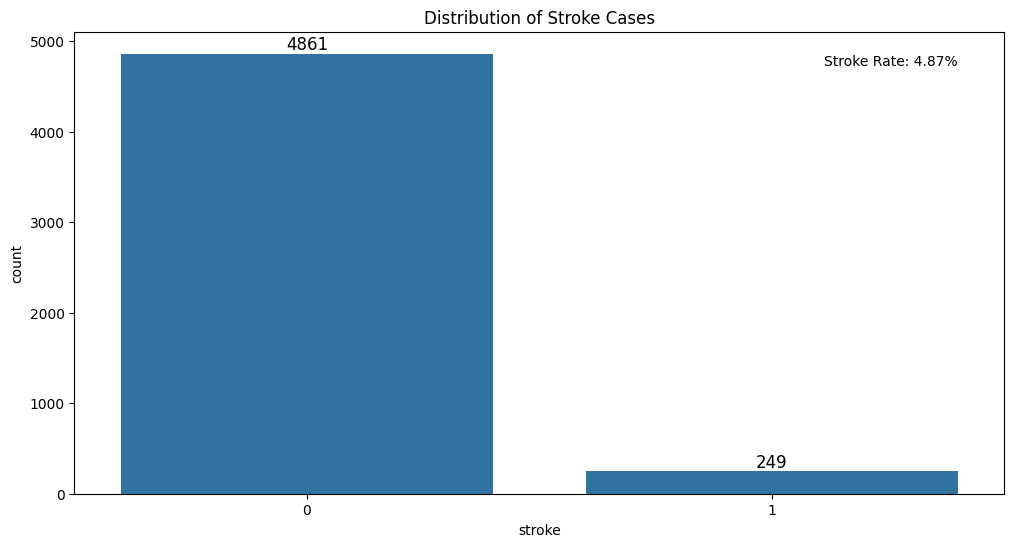

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='stroke', data=df)
plt.title('Distribution of Stroke Cases')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
stroke_rate = df['stroke'].astype(int).mean() * 100
ax.text(0.95, 0.95, f'Stroke Rate: {stroke_rate:.2f}%', transform=ax.transAxes,
        ha='right', va='top', fontsize=10)

Implications & recommended actions

- Class imbalance is substantial — optimize models for **recall / average precision** rather than accuracy.
- Use **stratified train/test splits** and **StratifiedKFold** for cross-validation to preserve class proportions.
- Evaluation:
  - Primary: average precision (AP), precision–recall curves, recall (sensitivity).
  - Secondary: F1, and calibration for predicted probabilities.
- Modeling strategies to consider:
  - Class-weighted losses (e.g., class_weight='balanced') and threshold tuning.
  - Resampling: SMOTE and it's variants in pipeline cross-validation.
  - Strong baseline: DummyClassifier (most_frequent), linear and tree models without preprocessing to report baseline AP ≈ prevalence.
- Reporting:
  - Always show confusion matrix, PR curve, AP and recall for chosen threshold(s).
  - Report metric confidence intervals in CV because positives are relatively few.

## Statistical Summaries

Split predictors into **numerical** and **categorical** columns and plot their distributions:

In [ ]:
numerical_cols = (
    df.drop(columns='id')
    .select_dtypes(include=['int64', 'float64'])
    .columns
    .tolist()
)
categorical_cols = (
    df.drop(columns='stroke')
    .select_dtypes(include=['category'])
    .columns
    .tolist()
)
df[numerical_cols].describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


- **Age**: Median 45 years (IQR: 25–61), range 0.08–82. Mean 43.2 (SD: 22.6).
- **Avg Glucose Level**: Median 91.9 mg/dL (IQR: 77.2–114.1), range 55.1–271.7. Mean 106.1 (SD: 45.3).
- **BMI**: Median 28.1 (IQR: 23.5–33.1), range 10.3–97.6. Mean 28.9 (SD: 7.85).  
    *Note: ~4% missing values in BMI.*

All three variables show wide ranges and moderate skew, with BMI and glucose having notable outliers.


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'avg_glucose_level'}>],
       [<Axes: title={'center': 'bmi'}>, <Axes: >]], dtype=object)

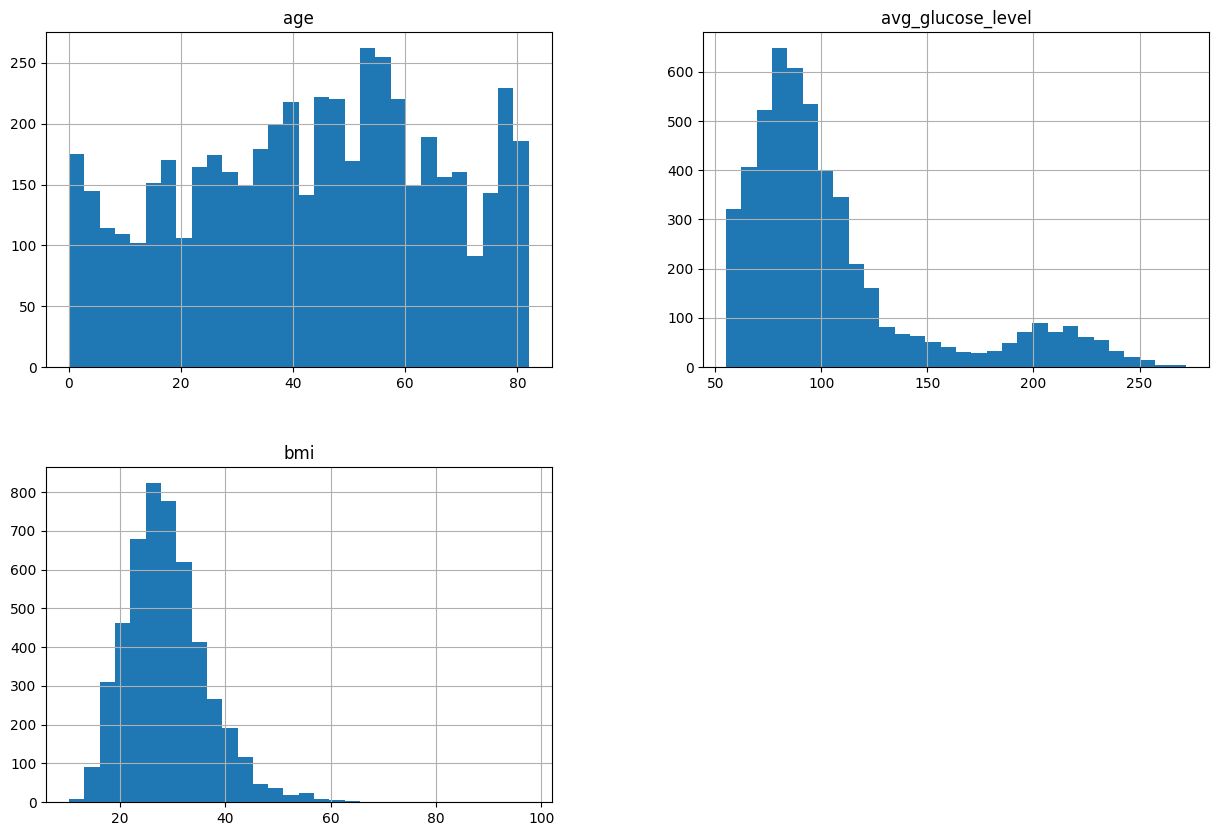

In [ ]:
df[numerical_cols].hist(bins=30, figsize=(15, 10), layout=(2, 2))

**Age**
- **Range:** ~0 to ~82 years
- **Shape:** Multi-modal; spread across adulthood with peaks in middle and older ages (not a single normal peak)
- **Notes:** Substantial mass across working-age and elderly groups. Age will likely be an important predictor and may interact with other features.

**Avg Glucose Level**
- **Shape:** Strongly right-skewed; large bulk around ~60–110 mg/dL, with a long tail up to ~250+, some indications of bi-modality
- **Notes:** Minority of very high glucose values create the tail and high variance.

**BMI**
- **Shape:** Right-skewed; most observations between ~15–40, peak in mid-20s, long thin tail to larger values
- **Notes:** Missing/imputed values present (handled earlier); a few extreme BMI values persist.

**Suggested Actions**
- **Transformations:** Apply log (or robust) transform to `avg_glucose_level` and possibly `bmi` before modeling, or use robust scalers. `Age` can remain as-is or be modeled with splines to capture nonlinearity.
- **Outliers:** Inspect and either winsorize or handle extreme glucose/BMI values (or use robust estimators), as they affect mean-based statistics and many models.

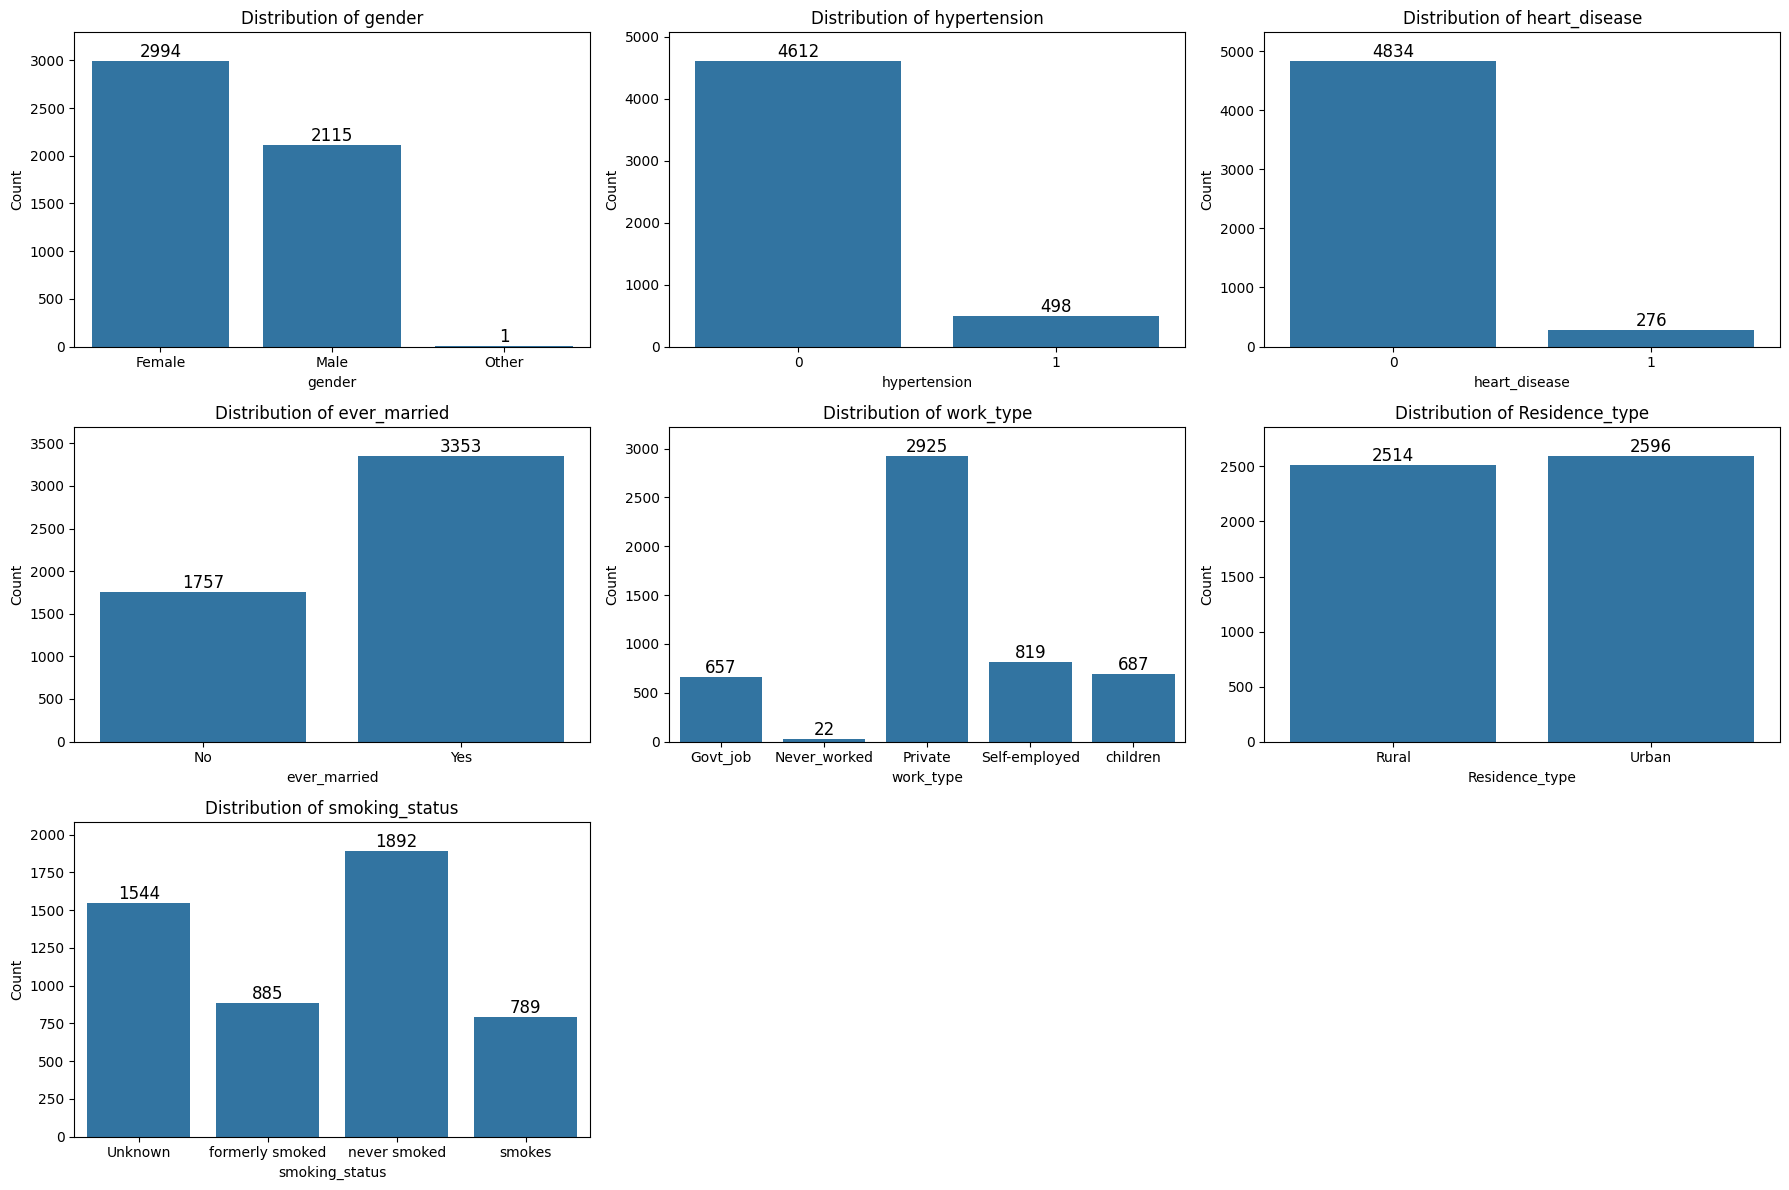

In [ ]:
"""
- Visualize the distribution of each categorical variable in the dataset.
- Create a grid of bar plots (countplots) for each categorical column, showing the frequency of each category.
- Each bar is annotated with its count, and the y-axis is scaled for clarity.
- Unused subplots are removed for a clean layout.
"""
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
used_axes = 0
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for ax in axes[i].patches:
        axes[i].text(ax.get_x() + ax.get_width() / 2.,
                     ax.get_height(),
                     f'{int(ax.get_height())}',
                     ha='center', va='bottom', fontsize=12)
    used_axes += 1
    axes[i].set_ylim(0, df[col].value_counts().max() * 1.1)
for j in range(used_axes, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**gender**  
- Female: 2,994; Male: 2,115; Other: 1  
- *Action:* Drop or merge "Other" (negligible).

**hypertension**  
- No: 4,612; Yes: 498  
- *Action:* Imbalanced binary; rare positives.

**heart_disease**  
- No: 4,834; Yes: 276  
- *Action:* Rare positive class.

**ever_married**  
- Yes: 3,353; No: 1,757  
- *Action:* Majority married; may correlate with age/health.

**work_type**  
- Private: 2,925; Self-employed: 819; Govt_job: 657; children: 687; Never_worked: 22  
- *Action:* Group "Never_worked" and "children" as "other".

**Residence_type**  
- Urban: 2,596; Rural: 2,514  
- *Action:* Balanced.

**smoking_status**  
- never smoked: 1,892; unknown: 1,544; formerly smoked: 885; smokes: 789  
- *Action:* Keep "unknown" as explicit category.

**Practical Modeling Tips**
- Collapse rare categories to avoid sparse dummies.
- Treat "unknown" smoking status as its own group.
- Use target/ordinal encoding for multi-level categoricals.
- Account for class imbalance in binary predictors when interpreting effects.

Merge rare categories into single predictors:

In [ ]:
other_index = np.where(df['gender'] == 'Other')[0]
df2 = df.copy()
df2 = df2.drop(index=other_index)
df2['gender'] = df2['gender'].cat.remove_unused_categories()

df2['work_type'].replace({'children': 'other', 'Never_worked': 'other'}, inplace=True)
df2['work_type'] = df2['work_type'].cat.remove_unused_categories()

df2['smoking_status'].replace({'smokes': 'ever_smoked',
                              'formerly smoked': 'ever_smoked'}, inplace=True)
df2['smoking_status'] = df2['smoking_status'].cat.remove_unused_categories()

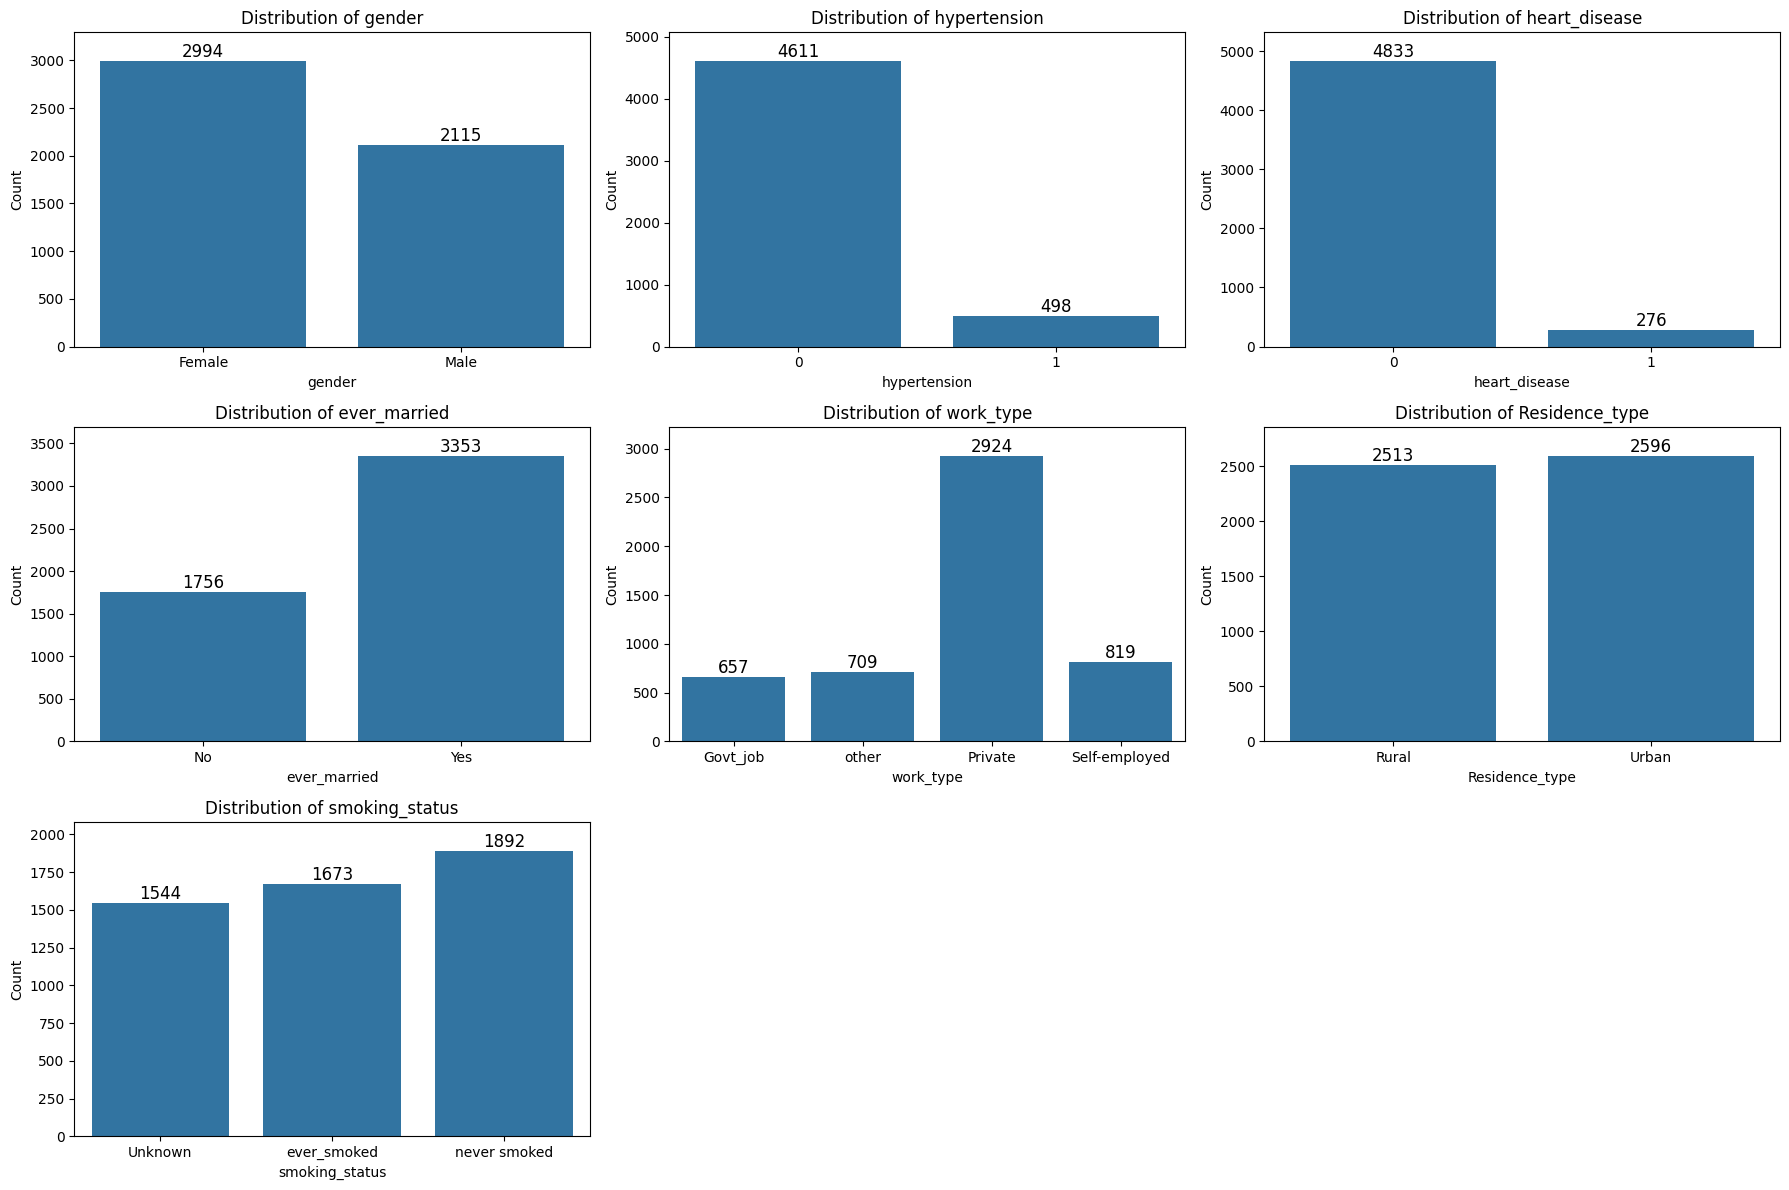

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
used_axes = 0
for i, col in enumerate(categorical_cols):
    """
    Iterate through each categorical column and plot its distribution as a countplot.
    Annotate each bar with its count, set axis labels and title, and adjust y-axis limits for clarity.
    """
    sns.countplot(data=df2, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for ax in axes[i].patches:
        axes[i].text(ax.get_x() + ax.get_width() / 2.,
                     ax.get_height(),
                     f'{int(ax.get_height())}',
                     ha='center', va='bottom', fontsize=12)
    used_axes += 1
    axes[i].set_ylim(0, df[col].value_counts().max() * 1.1)
for j in range(used_axes, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()

**Category Consolidation for Modeling**

- **Gender:**  
    - Removed the single "Other" row (dropped).  
    - Dataset now contains only "Male" and "Female".

- **Smoking Status:**  
    - Combined "smokes" and "formerly smoked" into a single category: **"ever_smoked"**.  
    - Kept "unknown" and "never smoked" as separate categories.

**Modeling Effects:**  
- Reduces sparse categories and one-hot columns if used.
- Fewer dummy variables, less memory usage, and faster training.

## Empty Values

The **missingno** package provides visualizations to quickly diagnose missing data patterns in a dataset. Here, we use it to display a matrix plot of df_imp, helping us identify which variables have missing values and assess their extent before proceeding with imputation or further analysis.

<Axes: >

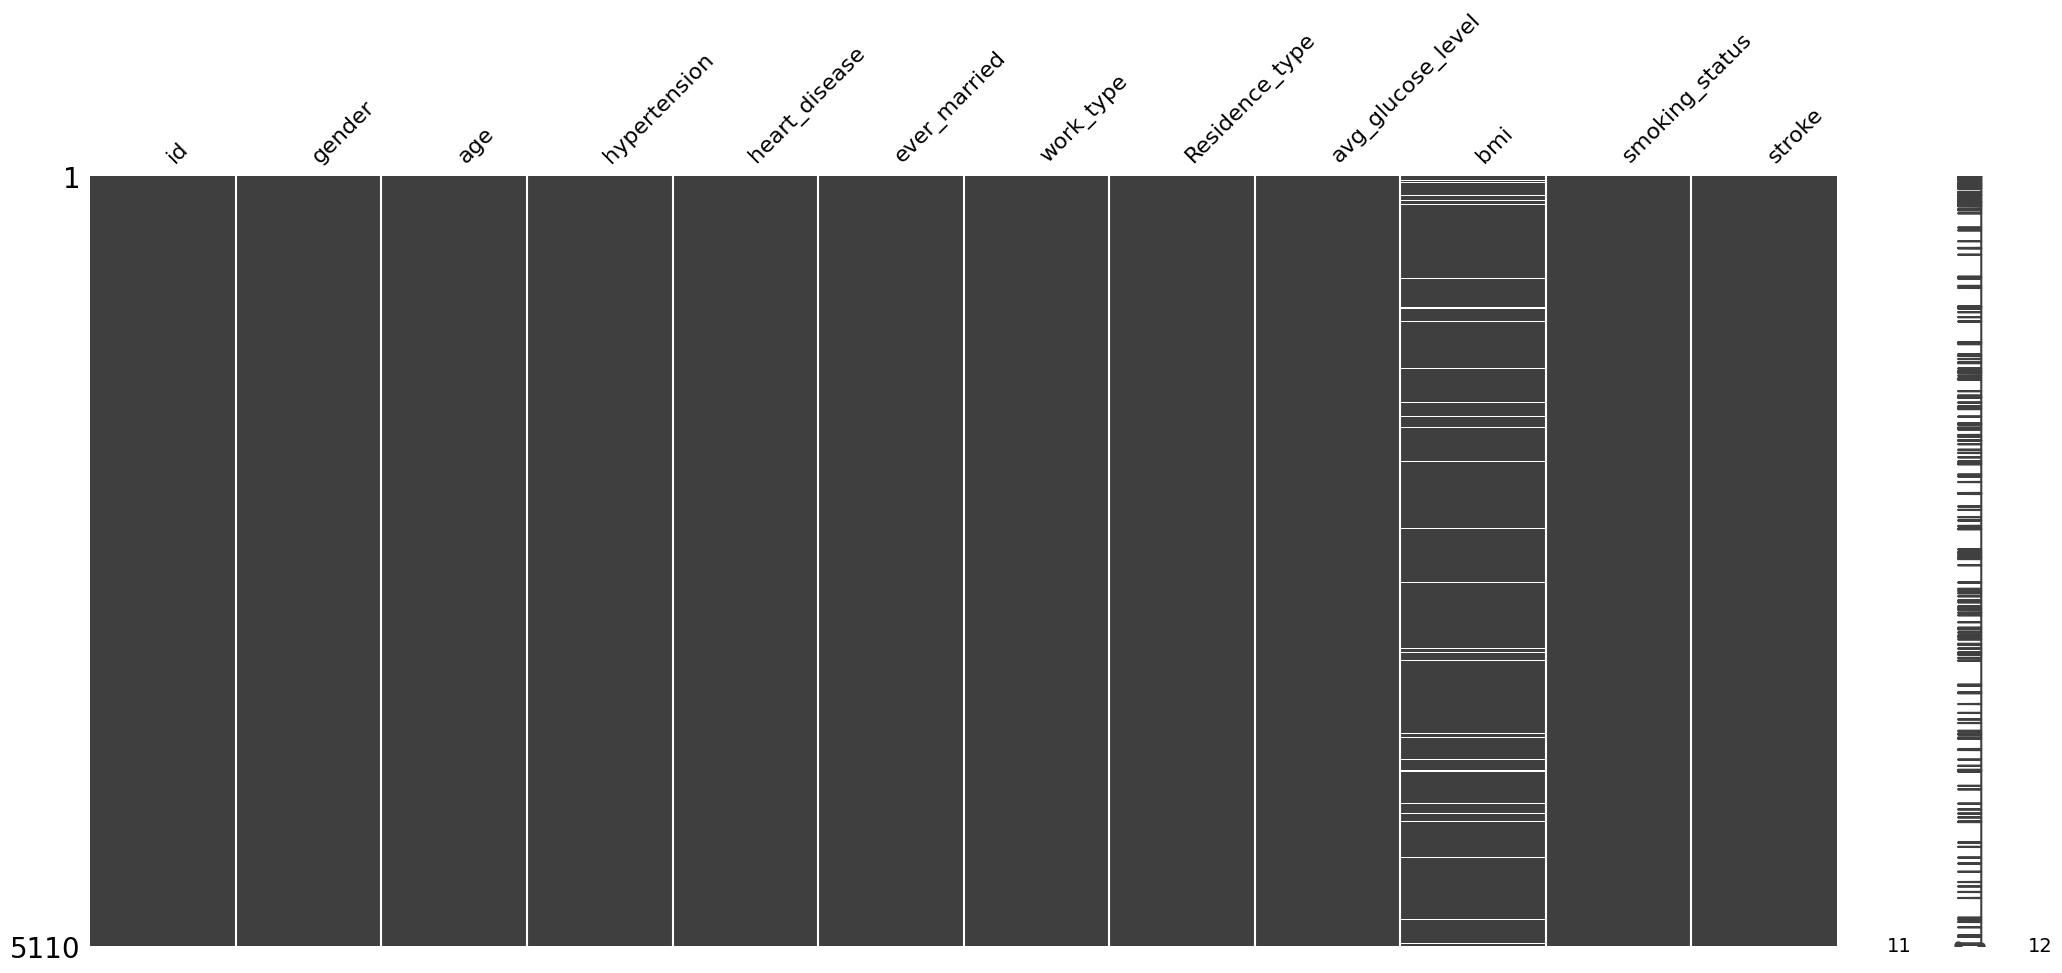

In [8]:
df_imp = df2.copy()
msno.matrix(df_imp)

From plot above, **bmi** has missing values only. Verify with pandas:

In [10]:
empty_columns = df_imp.columns[df_imp.isnull().any()].tolist()
display(df_imp[empty_columns].isnull().sum().sort_values(ascending=False))

bmi    201
dtype: int64

#### Missing Data Mechanisms: MCAR, MAR, MNAR

- **MCAR (Missing Completely At Random):**  
    Missingness is unrelated to any observed or unobserved data. If true, analyses remain unbiased.

- **MAR (Missing At Random):**  
    Missingness depends only on observed data (e.g., age, gender), not on the missing values themselves. Imputation methods can yield valid results if MAR holds.

- **MNAR (Missing Not At Random):**  
    Missingness depends on the unobserved value itself (e.g., people with extreme BMI are less likely to report it). Standard imputation may introduce bias.

**Application to BMI:**  
We test if BMI missingness is MCAR using Little’s test, and assess MAR by modeling missingness with observed predictors. Sensitivity analyses explore MNAR scenarios to check robustness of conclusions. This guides our choice of imputation and interpretation for downstream analyses.

In [ ]:
"""
Perform Little's MCAR test: select numeric columns, dummy-encode categoricals, concatenate, and test if missing data is MCAR.
"""
df_num = df_imp.select_dtypes(include=[np.number])
df_cat = df_imp.select_dtypes(exclude=[np.number])
df_cat = pd.get_dummies(df_cat, drop_first=True)
test_df = pd.concat([df_num, df_cat], axis=1)
mcar_test = MCARTest(method='little')
print("MCAR Test:")
print(mcar_test.little_mcar_test(test_df))

MCAR Test:
0.0


Little’s MCAR test evaluates whether missing data in your dataset is **Missing Completely At Random (MCAR)**.  
- **Test result:** `0.0` (p-value)
- **Interpretation:**  
    - If the p-value is **small** (typically < 0.05), you **reject** the MCAR hypothesis: missingness is **not** completely random.
    - If the p-value is **large** (≥ 0.05), you **fail to reject** MCAR: missingness could be random.
 
**Conclusion:**  
- The missing BMI values are **not MCAR** (missingness is related to observed/unobserved data).
- MAR/MNAR mechanisms are considered and tested below:

In [ ]:
def assess_mar(df, target):
    """
    Assess Missing At Random (MAR) mechanism for a variable.

    Steps:
    1. Create a missingness indicator (R): 1 if value is missing, 0 otherwise.
    2. Encode all observed predictors (numeric and categorical) as model features.
    3. Fit a logistic regression predicting R from observed predictors.
    4. If any predictors are significantly associated with R, missingness is MAR (depends on observed data).
    5. Print regression results and pseudo R-squared to quantify explained missingness.
    """
    df_mar = df.copy().drop(columns='id')
    df_mar = pd.get_dummies(df_mar, columns=df_mar.select_dtypes(exclude=[np.number]).columns.tolist(), drop_first=True)
    df_mar['R'] = df_mar[target].isna().astype(int)
    X = df_mar.drop(columns=[target, 'R'])
    X = sm.add_constant(X)  # Add constant for intercept
    X = X.astype(float)     # Make sure all columns are float

    # Drop columns with zero variance
    zero_var_cols = X.columns[X.nunique() <= 1]
    if len(zero_var_cols) > 0:
        X = X.drop(columns=zero_var_cols)

    y = df_mar['R']
    model = sm.Logit(y, X).fit(disp=0)
    print(f'Missingness assessment for {target}:\n {model.summary().tables[1]}')
    print(f"Pseudo R-squared: {model.prsquared:.4f}")


assess_mar(df, 'bmi')

Missingness assessment for bmi:
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
age                               -0.0284      0.005     -5.896      0.000      -0.038      -0.019
avg_glucose_level                 -0.0012      0.001     -0.849      0.396      -0.004       0.002
gender_Male                        0.0176      0.140      0.126      0.900      -0.256       0.291
gender_Other                     -13.6261   3570.832     -0.004      0.997   -7012.329    6985.077
hypertension_1                     1.0972      0.195      5.612      0.000       0.714       1.480
heart_disease_1                    1.2329      0.234      5.276      0.000       0.775       1.691
ever_married_Yes                  -0.2808      0.188     -1.493      0.135      -0.649       0.088
work_type_Never_worked            -2.8635      1.889     -1.515      0.130   

Pseudo R-squared quantifies how much variation in missingness is explained by observed predictors (higher = more explained). In MAR context, a low value means missingness is only weakly predictable from available data, so imputation is less likely to introduce bias from observed variables.

- Significant predictors of BMI missingness include **age**, **hypertension**, **heart disease**, **work type**, **residence type**, **smoking status**, and **stroke**.
- Pseudo R-squared is low (0.0146), indicating limited explained variance.
- At this stage, missingness is **not random**: it depends on observed variables, justifying imputation methods that use these predictors. 
- BMI **shift** test is conducted to evaluate how much **systematically** we have to over/under-impute `bmi` values for prediction to shift to opposite direction.


**Imputation Criterion Selection Based on Skewness**

To choose the optimal `criterion` for `IterativeImputer` (RandomForestRegressor):

- If skewness < 1: use `'squared_error'` (minimizes mean squared error, best for symmetric distributions).
- If skewness < 2: `'squared_error'` is likely sufficient.
- If skewness ≥ 2: use `'absolute_error'` (minimizes mean absolute error, more robust to outliers and heavy skew).

**Explanation:**  
Squared error is sensitive to outliers and works best for nearly normal data. Absolute error is less affected by extreme values, making it preferable for highly skewed distributions as per documentation.

In [11]:
"""
Step-by-step:
1. Calculate BMI skewness and print criterion recommendation.
2. Define IQR outlier detection function for a column.
3. Count BMI outliers using IQR method.
4. Print recommendation based on outlier proportion.
"""

bmi_skewness = df_imp['bmi'].skew()
if np.abs(bmi_skewness) < 1:
    print(f"BMI skewness: {bmi_skewness:.2f}, squared_error is optimal criterion.")
elif np.abs(bmi_skewness) < 2:
    print(f"BMI skewness: {bmi_skewness:.2f}, squared_error is likely sufficient.")
else:
    print(f"BMI skewness: {bmi_skewness:.2f}, consider using absolute_error criterion for better performance.")

# IQR method for outlier detection


def detect_outliers_iqr(data, column):
    Q1 = data[column].dropna().quantile(0.25)
    Q3 = data[column].dropna().quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(
        f'Outlier count in {column}: {data[(data[column] < lower_bound) | (data[column] > upper_bound)].shape[0]} out of {data.shape[0]}')
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)].shape[0]


outlier_count = detect_outliers_iqr(df_imp, 'bmi')
if outlier_count / df.shape[0] > 0.1:
    print("High outlier proportion detected, consider using absolute_error criterion.")
else:
    print("Low outlier proportion, squared_error criterion is sufficient.")

BMI skewness: 1.06, squared_error is likely sufficient.
Outlier count in bmi: 110 out of 5110
Low outlier proportion, squared_error criterion is sufficient.


#### Sensitivity Analysis: BMI–Stroke Relationship Under MNAR Assumptions

Code below performs a sensitivity analysis to assess how the estimated effect of BMI on stroke risk changes under different Missing Not At Random (MNAR) scenarios for BMI imputation.

**Key steps:**
- Impute missing BMI values using IterativeImputer with a RandomForestRegressor, leveraging all available predictors.
- For each imputed BMI value, apply a range of systematic shifts (`delta`) to simulate MNAR scenarios, where missing BMI values could be systematically higher or lower than predicted.
- Weight the shift for each imputed value by its distance from the median, scaled by the standard deviation, to reflect plausible MNAR mechanisms.
- For each scenario, fit a logistic regression of stroke outcome on BMI and record the coefficient.
- Summarize how the BMI–stroke association varies across MNAR scenarios, providing insight into the robustness of conclusions to untestable missing data assumptions.

This approach helps quantify the uncertainty in the BMI–stroke relationship due to possible MNAR missingness, supporting transparent reporting and sensitivity analysis in epidemiological modeling.


In [13]:
print("Testing sensitivity of BMI-stroke relationship to MNAR assumptions:\n")
"""
Step-by-step sensitivity analysis for BMI–stroke relationship under MNAR (Missing Not At Random) assumptions:

1. Impute missing BMI values using IterativeImputer with RandomForestRegressor, leveraging all predictors.
2. For each imputed BMI value, apply a range of shifts (delta), weighted by distance from the median, to simulate possible MNAR scenarios.
3. For each scenario, fit a logistic regression of stroke outcome on BMI and record the coefficient.
4. Summarize how the BMI–stroke association varies across MNAR scenarios, quantifying robustness to missing data assumptions.
"""

# Prepare data for imputation
imputation_data = test_df.drop(columns='id', errors='ignore').copy()
bool_cols = imputation_data.select_dtypes(include=['bool']).columns.tolist()
imputation_data[bool_cols] = imputation_data[bool_cols].astype(int)

# Initialize IterativeImputer
imp = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        criterion='squared_error',
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
    ),
    sample_posterior=False,
    max_iter=10,
    random_state=RANDOM_STATE,
    skip_complete=True
)

# Impute missing values
imputed_data = pd.DataFrame(
    imp.fit_transform(imputation_data),
    columns=imputation_data.columns,
    index=imputation_data.index
)

# Track which BMI values were imputed
bmi_missing_mask = imputation_data['bmi'].isna()
bmi_std = imputation_data['bmi'].dropna().std()
imputed_bmis = imputed_data.loc[bmi_missing_mask, 'bmi']
median_bmi = imputed_bmis.median()

# Calculate weights for each imputed BMI
w = np.minimum(1.0, np.abs(imputed_bmis - median_bmi) / bmi_std)

# Define the range of BMI shifts to test
delta = np.linspace(-8.0 * bmi_std, 8.0 * bmi_std, 30)

print(f"Testing MNAR scenarios with 8 standard deviation range:")
print(f'BMI standard deviation: {bmi_std:.2f} kg/m^2')
print(f'Testing range: {-8.0 * bmi_std:.1f} to {8.0 * bmi_std:.1f} BMI units')
print(f'Number of scenarios: {len(delta)}\n')


def bmi_effect(scenario_data):
    """
    This function estimates the effect of BMI on stroke risk for a given scenario.
    It takes a DataFrame (scenario_data) with all predictors and outcome.
    - X: uses only the 'bmi' column as the predictor.
    - y: uses the 'stroke_1' column as the binary outcome.
    It fits a logistic regression model (LogisticRegression) to predict stroke from BMI.
    Returns the estimated coefficient for BMI, which quantifies the association between BMI and stroke risk under the current MNAR scenario.
    """
    X = scenario_data['bmi']
    y = scenario_data['stroke_1']
    lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    lr.fit(X.values.reshape(-1, 1), y)
    return lr.coef_[0][0]


# Evaluate each MNAR scenario
results = []
for i, delta in enumerate(delta):
    scenario_data = imputed_data.copy()
    scenario_data.loc[bmi_missing_mask, 'bmi'] += delta * w
    coefs = bmi_effect(scenario_data)
    results.append((delta, coefs))

# Summarize results and display
results_df = pd.DataFrame(results, columns=['BMI Shift', 'Coefficient'])
print(results_df)

Testing sensitivity of BMI-stroke relationship to MNAR assumptions:

Testing MNAR scenarios with 8 standard deviation range:
BMI standard deviation: 7.85 kg/m^2
Testing range: -62.8 to 62.8 BMI units
Number of scenarios: 30

    BMI Shift  Coefficient
0  -62.834559    -0.008967
1  -58.501141    -0.007870
2  -54.167724    -0.006537
3  -49.834306    -0.004965
4  -45.500888    -0.003168
5  -41.167470    -0.001140
6  -36.834052     0.001063
7  -32.500634     0.003411
8  -28.167216     0.005859
9  -23.833798     0.008379
10 -19.500380     0.010902
11 -15.166963     0.013459
12 -10.833545     0.015954
13  -6.500127     0.018378
14  -2.166709     0.020701
15   2.166709     0.022893
16   6.500127     0.024920
17  10.833545     0.026749
18  15.166963     0.028342
19  19.500380     0.029657
20  23.833798     0.030677
21  28.167216     0.031367
22  32.500634     0.031731
23  36.834052     0.031784
24  41.167470     0.031560
25  45.500888     0.031101
26  49.834306     0.030461
27  54.167724     0

In [11]:
"""Replace empty values with imputed ones"""
df_imp.loc[df_imp['bmi'].isnull(), 'bmi'] = imputed_data.loc[bmi_missing_mask, 'bmi']

### How much do BMI values need to be systematically under/over-imputed for MNAR to reverse prediction direction?

The MNAR sensitivity analysis quantifies the impact of systematic shifts in imputed BMI values on the estimated BMI–stroke association:

- **MNAR scenario (extreme values more likely missing):**  
    The BMI–stroke coefficient only reverses direction (from positive to negative) if missing BMI values are systematically **underestimated by ~40 kg/m²**.  
    This is very unlikely to be in biological range, indicating that the relationship should be robust to even severe MNAR bias.

- **Uniform MNAR scenario (all missing equally shifted):**  
    The coefficient reverses direction if missing BMI values are **underestimated by ~13 kg/m²**.  
    This shift is near the 95th percentile of observed BMI values, still representing an unlikely scenario.

**Conclusion:**  
For MNAR conditions to meaningfully alter the direction of the BMI–stroke association, missing BMI values would need to be imputed with large systematic errors. This supports the robustness of the findings under reasonable missing data assumptions.


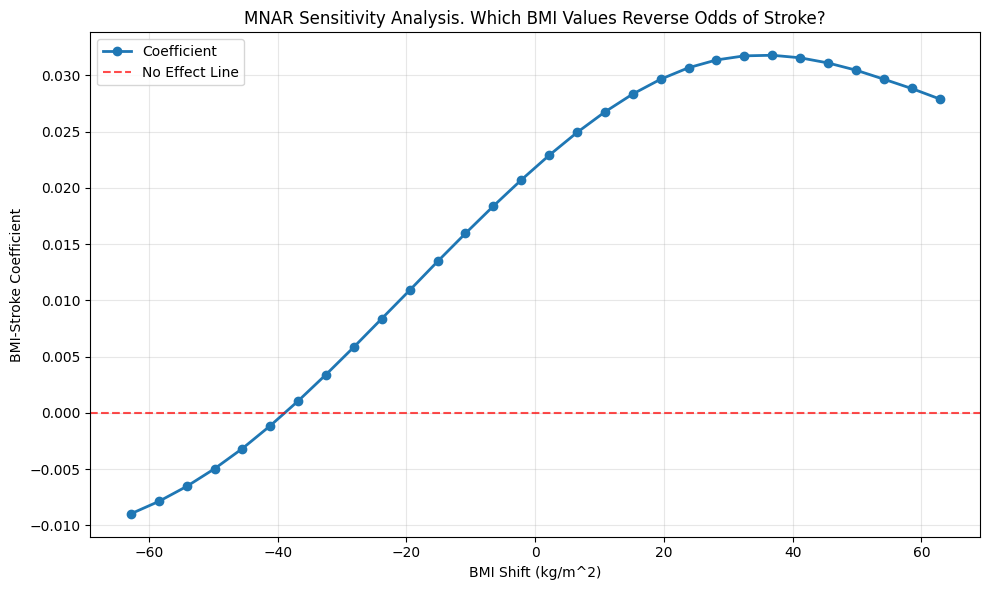

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['BMI Shift'], results_df['Coefficient'], 'o-', linewidth=2, label='Coefficient')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='No Effect Line')
plt.xlabel('BMI Shift (kg/m^2)')
plt.ylabel('BMI-Stroke Coefficient')
plt.title('MNAR Sensitivity Analysis. Which BMI Values Reverse Odds of Stroke?')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

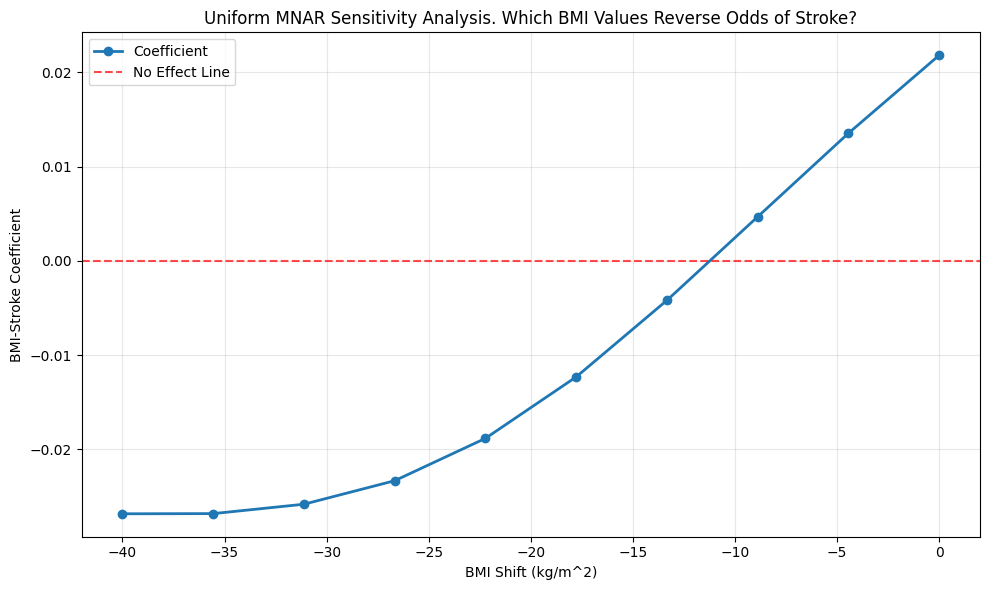

In [ ]:
uniform_results = []
for delta in np.linspace(-40, 0, 10):
    uniform_scenario = imputed_data.copy()
    uniform_scenario.loc[bmi_missing_mask, 'bmi'] += delta
    uniform_coefs = bmi_effect(uniform_scenario)
    uniform_results.append((delta, uniform_coefs))

uniform_results_df = pd.DataFrame(uniform_results, columns=['BMI Shift', 'Coefficient'])
plt.figure(figsize=(10, 6))
plt.plot(uniform_results_df['BMI Shift'], uniform_results_df['Coefficient'], 'o-', linewidth=2, label='Coefficient')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='No Effect Line')
plt.xlabel('BMI Shift (kg/m^2)')
plt.ylabel('BMI-Stroke Coefficient')
plt.title('Uniform MNAR Sensitivity Analysis. Which BMI Values Reverse Odds of Stroke?')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Sensitivity Analysis Conclusion

#### Extreme BMI Values Assumption
- The analysis demonstrates that the BMI-stroke relationship remains **robust** under different missing data assumptions - given MNAR scenario probability increases with more extreme BMI values.
- Even in extreme Missing Not At Random (MNAR) scenarios, BMI values would need to be underestimated by approximately **40 kg/m²** to reverse the direction of the relationship
- This extreme adjustment is far beyond reasonable biological variation, supporting the stability of our conclusions

#### Uniform Missing Data Assumption
- Under the assumption that MNAR probability is uniform across all possible BMI values
- The analysis shows moderate sensitivity: BMI values would need to be underimputed by approximately **13 kg/m²** to reverse the direction of the relationship
- This represents a shift near the 95th percentile of observed BMI data, which is still a substantial deviation

#### Overall Conclusion
This sensitivity analysis provides evidence that we can proceed with imputation under the Missing At Random (MAR) assumption. It is supported by Logistic Regression findings of other covariate significant associations with the missingness of BMI values.

## Outliers

Outliers are extreme values that deviate significantly from the majority of the data and can distort statistical analyses and model performance. In this section, we identify and address outliers in the stroke dataset using two methods:

- **IQR (Interquartile Range) Method:** Detects outliers based on values falling outside 1.5 times the IQR below the first quartile or above the third quartile.
- **Z-score Method:** Flags observations with standardized scores (z-scores) greater than a specified threshold (commonly 3), indicating values far from the mean.

Both approaches are applied to the main numerical predictors (`age`, `avg_glucose_level`, `bmi`) to quantify and visualize outlier prevalence, guiding decisions on data cleaning and transformation for robust modeling.

In [ ]:
"""Impute the missing BMI values in the dataframe"""
df_imp.loc[bmi_missing_mask, 'bmi'] = imputed_data.loc[bmi_missing_mask, 'bmi']

In [ ]:
def detect_outliers_zscore(data, column, threshold=3):
    """Z-score method for outlier detection"""
    col_data = data[column].dropna()
    z_scores = np.abs(zscore(col_data))
    outlier_indices = col_data.index[z_scores > threshold]
    return data.loc[outlier_indices].shape[0]

In [ ]:
"""Only process columns that exist in the dataframe and are numeric"""
for col in num_cols:
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        outliers_iqr = detect_outliers_iqr(df_imp, col)
        outliers_zscore = detect_outliers_zscore(df_imp, col)
        print(f"Outliers detected in {col} using Z-score method:", outliers_zscore, '\n')

Outlier count in age: 0 out of 5109
Outliers detected in age using Z-score method: 0 

Outlier count in avg_glucose_level: 627 out of 5109
Outliers detected in avg_glucose_level using Z-score method: 49 

Outlier count in bmi: 116 out of 5109
Outliers detected in bmi using Z-score method: 59 



Boxplots are plotted in the next code cell to provide a concise visual summary of the skewness and distribution of numerical columns.

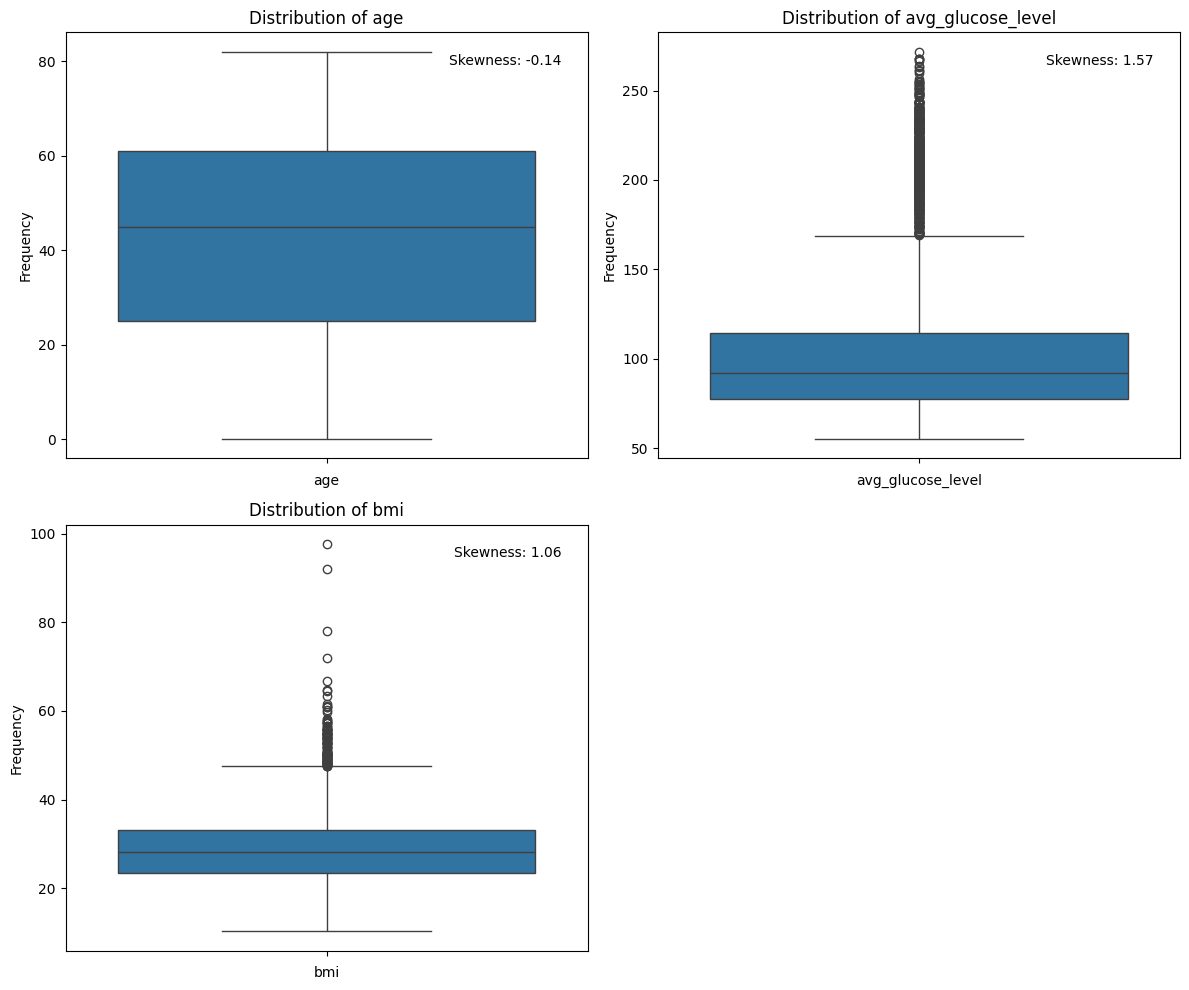

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
used_axes = 0
for i, col in enumerate(num_cols):
    if col in df_imp.columns and pd.api.types.is_numeric_dtype(df[col]):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
        axes[i].text(0.95, 0.95, f'Skewness: {df[col].skew():.2f}', transform=axes[i].transAxes,
                     ha='right', va='top', fontsize=10)
        used_axes += 1
for j in range(used_axes, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Age: median ≈ 45 years, mean ≈ 43, IQR roughly 25–61, range ~0–82 and skewness ≈ −0.14 (near symmetric). Age has broad coverage and likely non‑linear effects; consideration of modeling it with splines or polynomial terms rather than a single linear coefficient if the relationship with stroke is not monotonic. Check with ALE plots.

Avg glucose level: median ≈ 92, mean ~ 106, IQR ~ 77–114, range ~55–272 and skewness ≈ 1.6 (moderately right‑skewed). Many high outliers drive variance. Consideration to apply a log or robust transform (log1p or winsorization) and/or use robust scaling; clipping/extreme‑value handling will improve stability for methods sensitive to outliers.

BMI: median ~ 28.1, IQR ~ 23.5–33.1, mean ~ 28.9, range 10–98 and skewness ~ 1.06 (moderate right skew). Missing values (a few percent) should be imputed (iterative imputer) using observed predictors. Consider log transform only as it is likely sufficient.

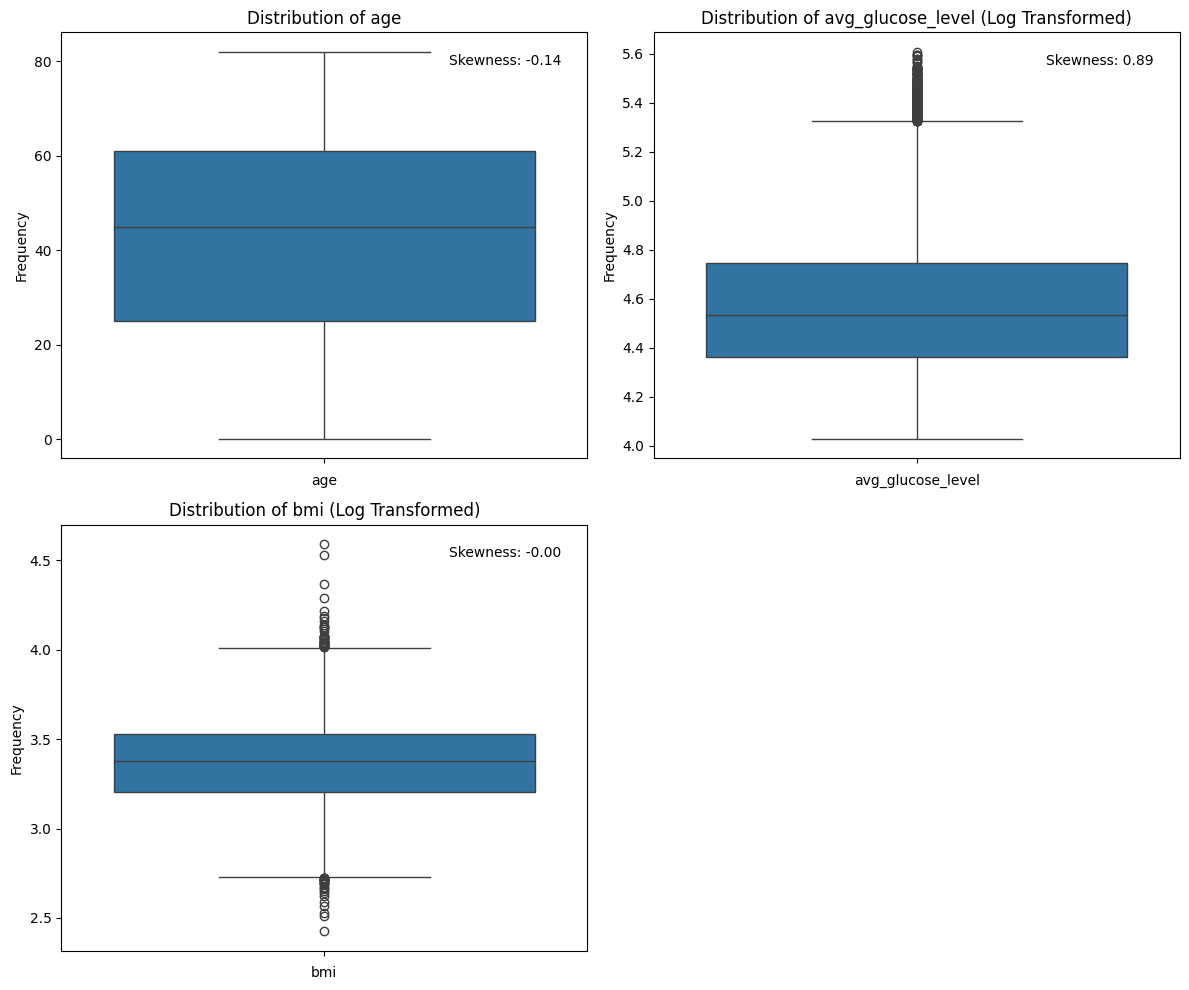

In [ ]:
df_imp[num_cols] = df_imp[num_cols].apply(lambda x: np.log1p(x) if x.skew() >= 1 else x)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
used_axes = 0
for i, col in enumerate(num_cols):
    if col in df_imp.columns and pd.api.types.is_numeric_dtype(df_imp[col]):
        sns.boxplot(y=df_imp[col], ax=axes[i])
        if col != 'age':
            axes[i].set_title(f'Distribution of {col} (Log Transformed)')
        else:
            axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
        axes[i].text(0.95, 0.95, f'Skewness: {df_imp[col].skew():.2f}', transform=axes[i].transAxes,
                     ha='right', va='top', fontsize=10)
        used_axes += 1
for j in range(used_axes, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Applying logarithmic transformation made feature distributions more symmetric and reduced outlier influence, as shown by lower skewness in the boxplots. This helps statistical tests and models perform better by stabilizing variance and making relationships more linear. Age was not log-transformed since its distribution was already nearly symmetric

## Associations

### Predictor vs Outcome

#### Numerical

**Violin plots** provide a clear visualization of the distribution and density of numerical predictors across binary outcome groups (e.g., stroke vs no stroke). Unlike boxplots, violin plots reveal multimodality, skewness, and outlier presence, helping to assess whether group means differ, and if distributions overlap. This helps in identifying predictors with distinct patterns between outcome classes and guides further analysis.

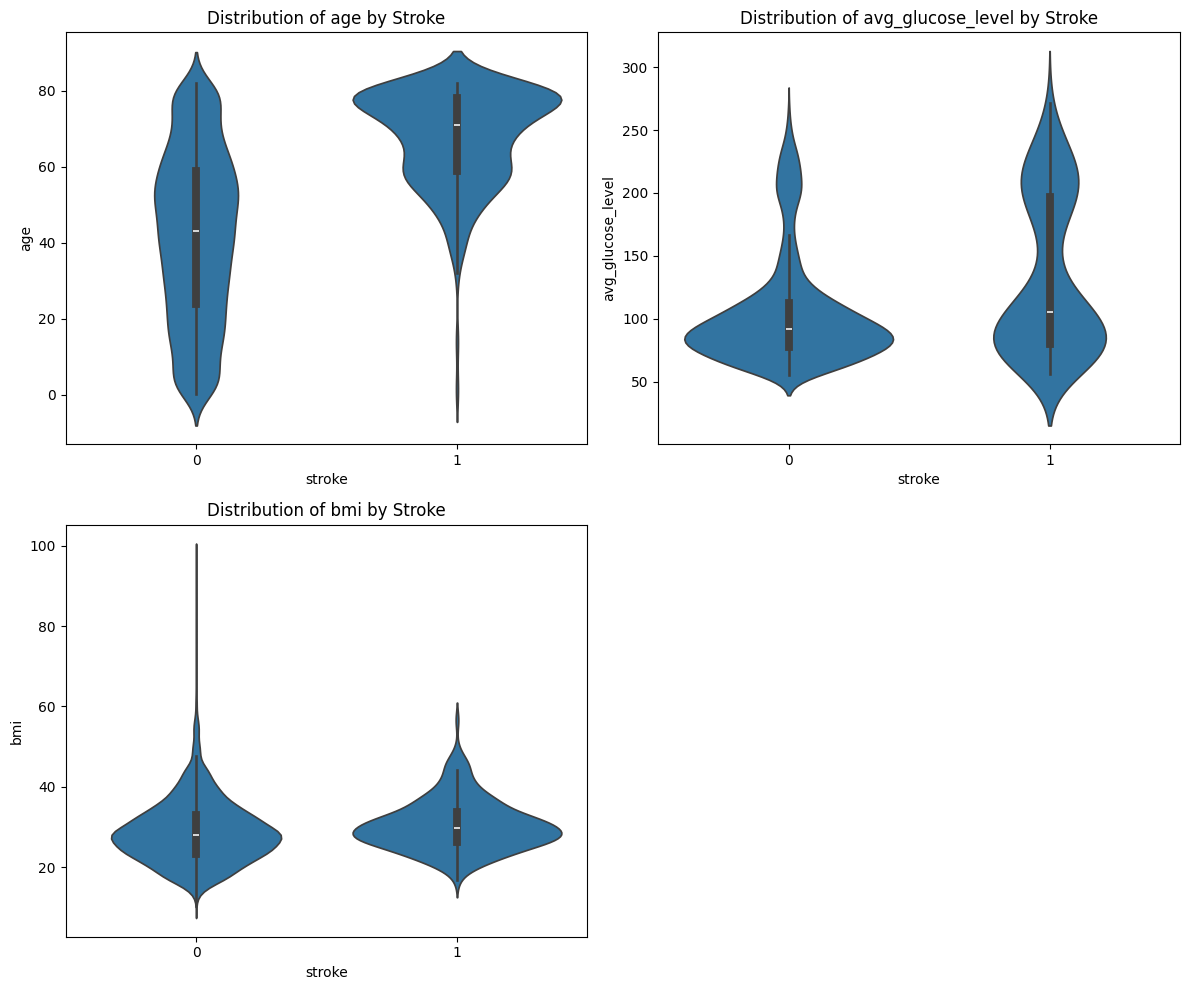

In [ ]:
# Calculate number of rows and columns for the grid
n = len(numerical_cols)
nrows = 2
ncols = int(np.ceil(n / 2))

# Create the subplot grid
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10))
axes = axes.flatten()  # Flatten to 1D for easy indexing

# Create the boxplots
for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.violinplot(data=df, x='stroke', y=col, ax=axes[i])
        axes[i].set_title(f'Distribution of {col} by Stroke')

# Hide any unused subplots
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

- **Age:** Stroke cases tend to occur at older ages, with the stroke group showing a higher median and a rightward shift compared to non-stroke cases.
- **Avg Glucose Level:** Individuals with stroke generally have higher average glucose levels, with the stroke group displaying a broader and more right-skewed distribution.
- **BMI:** The distribution of BMI is similar between groups, but stroke cases show a slightly higher median and more spread in the upper tail.
 
These visualizations highlight that age and average glucose level are more strongly associated with stroke occurrence, while BMI shows a weaker separation. The overlap in distributions suggests that while these predictors are informative, none alone perfectly distinguishes stroke cases, supporting the potential need for multivariate modeling. Quantify with **point biserial correlation**:

In [ ]:
print("Point Biserial Correlations:")
for num_col in num_cols:
    codes = df_imp['stroke'].cat.codes
    r, p = pointbiserialr(codes, df_imp[num_col])
    print(f"Stroke vs {num_col}: r = {r:.3f}, p = {p:.3f}")

Point Biserial Correlations:
Stroke vs age: r = 0.245, p = 0.000
Stroke vs avg_glucose_level: r = 0.132, p = 0.000
Stroke vs bmi: r = 0.040, p = 0.004


- **Point biserial correlations** calculate the strength and direction of association between each numerical predictor and stroke outcome.  
    - **Age** shows the strongest correlation (r = 0.245), confirming that stroke cases tend to be older, as seen in the violin plot's rightward shift.
    - **Avg glucose level** has a weaker but significant correlation (r = 0.117), matching the violin plot's broader, right-skewed distribution for stroke cases.
    - **BMI** has weakest yet significant effect on stroke correlation.

**Summary:**  
Both methods indicate that age and average glucose level are more strongly associated with stroke occurrence, while BMI shows little separation. The violin plots visually reinforce the statistical findings from point biserial correlations, supporting the selection of age and glucose as key predictors.

#### Categorical

IndexError: index 6 is out of bounds for axis 0 with size 6

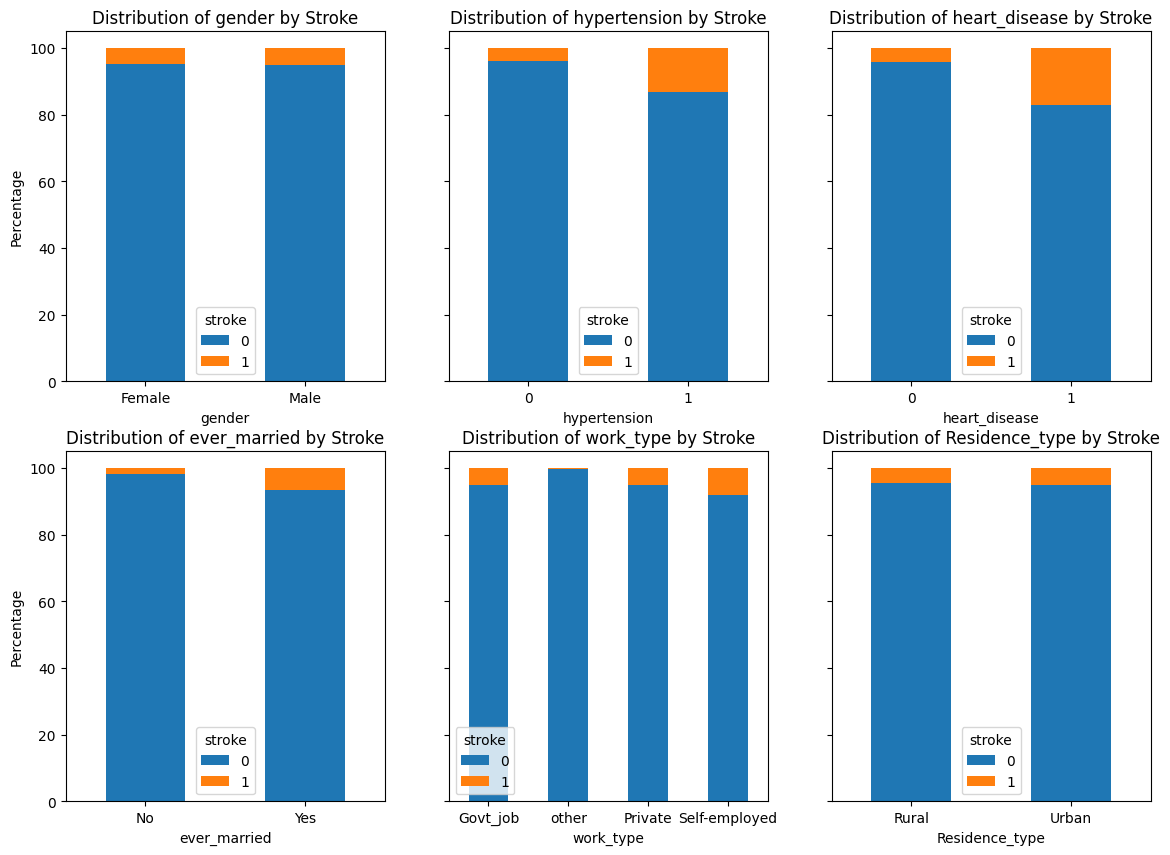

In [ ]:
ncols = int(np.ceil(len(categorical_cols) // 2))
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10))
axes = axes.flatten()
used_axes = 0

for i, bin_col in enumerate(categorical_cols):
    cont_table = pd.crosstab(df_imp[bin_col], df_imp['stroke'], normalize='index') * 100
    cont_table.plot(kind='bar', stacked=True, ax=axes[i], sharey=True)
    used_axes += 1
    axes[i].set_title(f'Distribution of {bin_col} by Stroke')
    axes[i].set_xlabel(bin_col)
    axes[i].set_ylabel('Percentage')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
for j in range(used_axes, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

The stacked bar plots above show the percentage distribution of stroke cases across categories for each predictor:

- **Gender:** Stroke rates are similar between males and females, with no pronounced difference.
- **Hypertension & Heart Disease:** Individuals with hypertension or heart disease have noticeably higher stroke rates compared to those without these conditions.
- **Ever Married:** Stroke is more common among those who have ever been married, likely reflecting age effects.
- **Work Type:** Stroke rates vary by work type, with "Self-employed" and "Govt_job" showing slightly higher proportions than "Private" or "other."
- **Residence Type:** Urban and rural residents have comparable stroke rates.
- **Smoking Status:** "Ever_smoked" and "unknown" categories have higher stroke rates than "never smoked," suggesting possible risk association.
  
Overall, predictors such as hypertension, heart disease, and smoking status show stronger associations with stroke occurrence, while gender and residence type display less pronounced differences. These patterns guide further statistical testing and model development.

Conduct chi-square test of independance/Cramer's V test to quantify the plot findings:

In [ ]:
chi_square_results = []
for cat_col in categorical_cols:
    """
    For each categorical predictor, perform a chi-square test of independence with stroke outcome.
    - Compute contingency table of observed counts.
    - Calculate chi-square statistic, p-value, degrees of freedom, and expected counts.
    - Check test assumptions: all expected counts >= 1 and <20% of cells have expected counts < 5.
    - Calculate Cramer's V to measure association strength.
    - Store results for summary and display.
    """
    cont_table_counts = pd.crosstab(df_imp[cat_col], df_imp['stroke'])
    chi2, p, dof, expected = chi2_contingency(cont_table_counts)
    min_expected = expected.min()
    cells_less_than_5 = (expected < 5).sum() / expected.size
    assumptions_met = min_expected >= 1 and cells_less_than_5 < 0.2

    # Cramer's V calculation
    n = cont_table_counts.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(cont_table_counts.shape) - 1)))

    chi_square_results.append({
        'Variable': cat_col,
        'Chi2': chi2,
        'p-value': round(p, 4),
        'Degrees of Freedom': dof,
        'Cramers V': cramers_v,
        'Assumptions Met': assumptions_met
    })

chi_df = pd.DataFrame(chi_square_results)
display(chi_df.sort_values(by='Chi2', ascending=False))

,Variable,Chi2,p-value,Degrees of Freedom,Cramers V,Assumptions Met
2,heart_disease,90.229437,0.0000,1,0.132894,True
1,hypertension,81.573145,0.0000,1,0.126359,True
3,ever_married,58.867809,0.0000,1,0.107342,True
4,work_type,49.155252,0.0000,3,0.098088,True
6,smoking_status,23.168636,0.0000,2,0.067341,True
5,Residence_type,1.074971,0.2998,1,0.014505,True
0,gender,0.340003,0.5598,1,0.008158,True


## Predictor vs Predictor

### Numerical 

Plot the heatmap of correlation matrix to quantify the strength among numerical predictors for potential interaction pairs or multicollinearity warnings:

<Axes: >

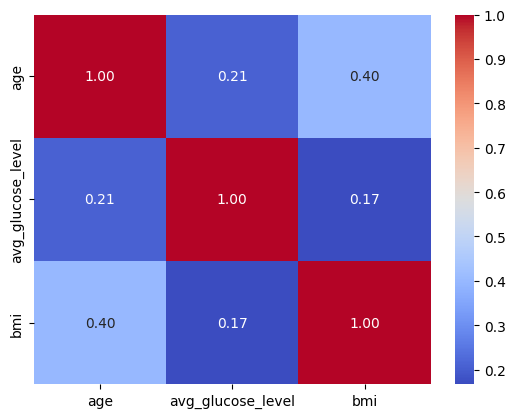

In [ ]:
sns.heatmap(df_imp[numerical_cols].corr(method='pearson'), annot=True, cmap='coolwarm', fmt='.2f')

- The heatmap above shows moderate correlation between age and bmi (r = 0.40).
- Age and avg_glucose_level are weakly correlated (r = 0.21).
- BMI and avg_glucose_level have the weakest association (r = 0.17).
- No strong multicollinearity indicated; all predictors provide mostly independent information for modeling stroke risk.

<Axes: >

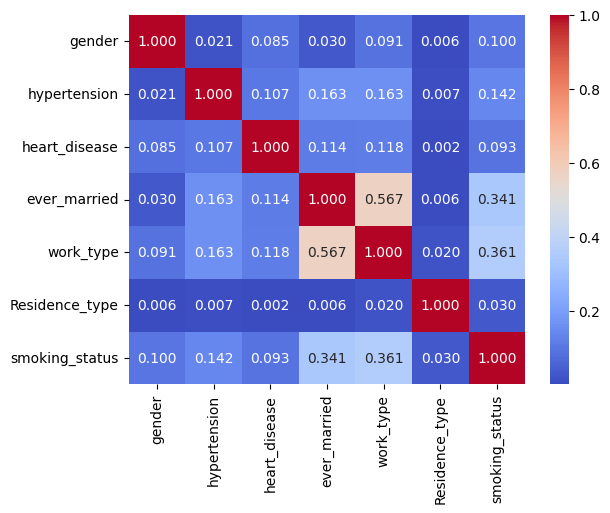

In [ ]:
def cramers_v(x, y):
    """
    - Calculate Cramer's V statistic for categorical-categorical association.
    - Return Cramer's V statistic.
    """
    cont_table_counts = pd.crosstab(x, y)
    chi2 = chi2_contingency(cont_table_counts)[0]
    n = cont_table_counts.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(cont_table_counts.shape) - 1)))
    return cramers_v


V = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for i in categorical_cols:
    for j in categorical_cols:
        if i != j:
            V.loc[i, j] = cramers_v(df_imp[i], df_imp[j])
        else:
            V.loc[i, j] = 1.0

sns.heatmap(V.astype(float), annot=True, cmap='coolwarm', fmt='.3f')

From the heatmap above, most values are low (<0.15), indicating weak relationships and minimal redundancy among predictors. The highest association is between ever_married/work_type (V=0.567), while most others are largely independent, supporting their inclusion in multivariate models without major collinearity concerns.

Analyze distributions of numerical variables among categorical ones using violin plots:

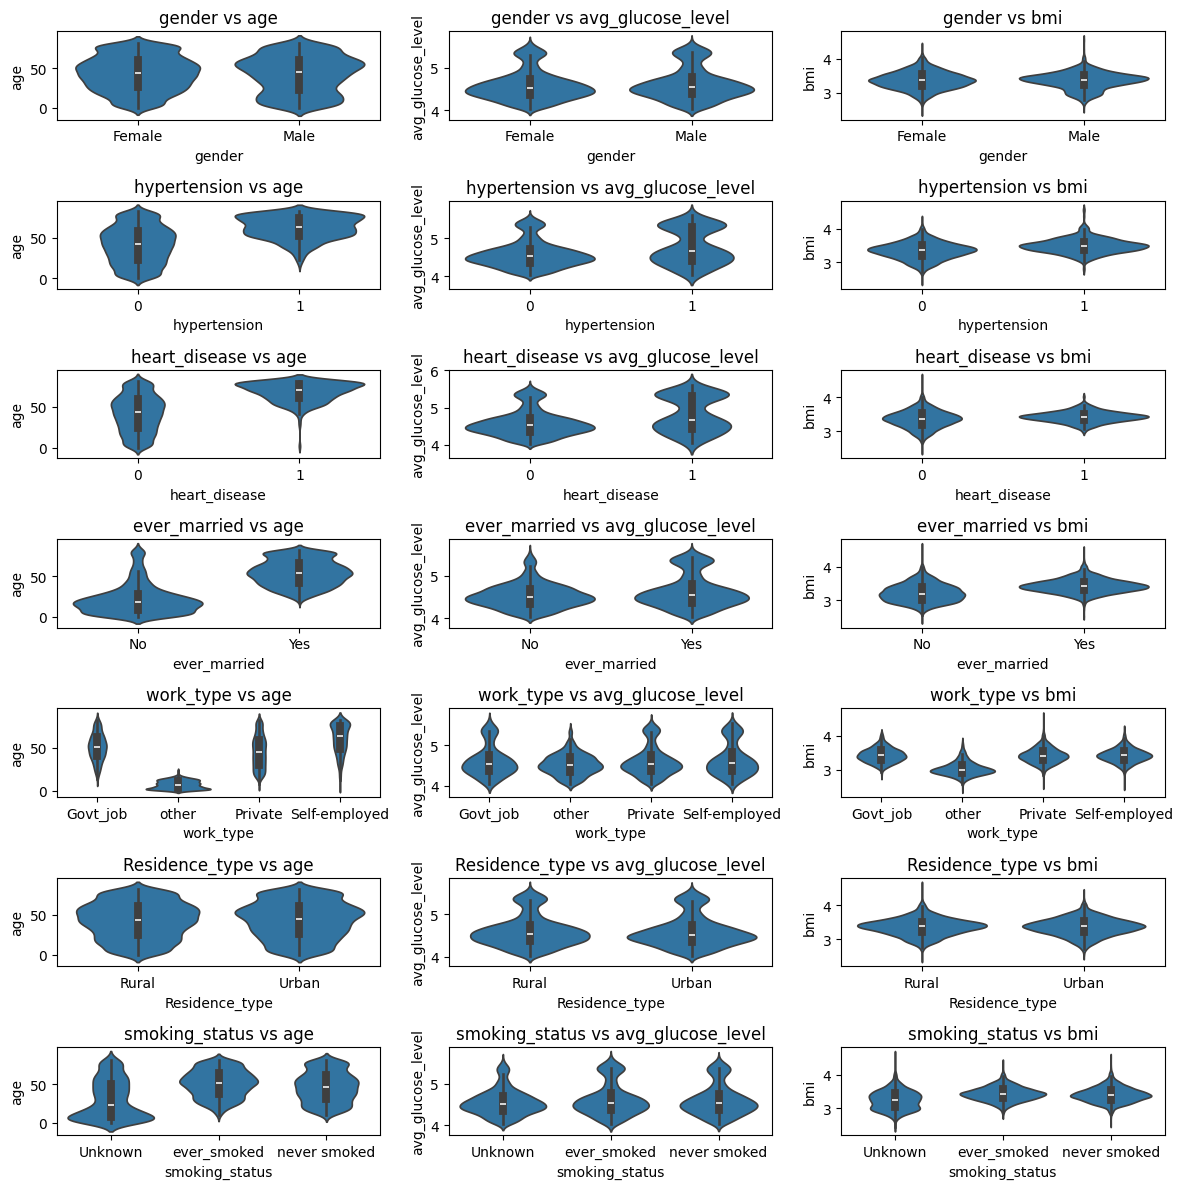

In [ ]:
fig, axes = plt.subplots(len(categorical_cols), len(numerical_cols), figsize=(12, 12))
for i, cat_col in enumerate(categorical_cols):
    for j, num_col in enumerate(numerical_cols):
        sns.violinplot(x=cat_col, y=num_col, data=df_imp, ax=axes[i, j])
        axes[i, j].set_title(f'{cat_col} vs {num_col}')
        axes[i, j].set_xlabel(cat_col)
        axes[i, j].set_ylabel(num_col)
plt.tight_layout()
plt.show()

- **Age** varies most across categories, especially for hypertension, heart disease, and marital status—older individuals are more likely to have these conditions.
- **Avg_glucose_level** and **BMI** show less separation across categories, but higher values are seen in groups with hypertension, heart disease, and "ever_smoked".
- **Work type** and **smoking status** display moderate differences in age and glucose distributions.
- **Gender** and **residence type** have minimal impact on numerical predictors.
- Overall, **age** is the most discriminative feature across categorical groups; other numerical predictors show weaker but visible group differences.

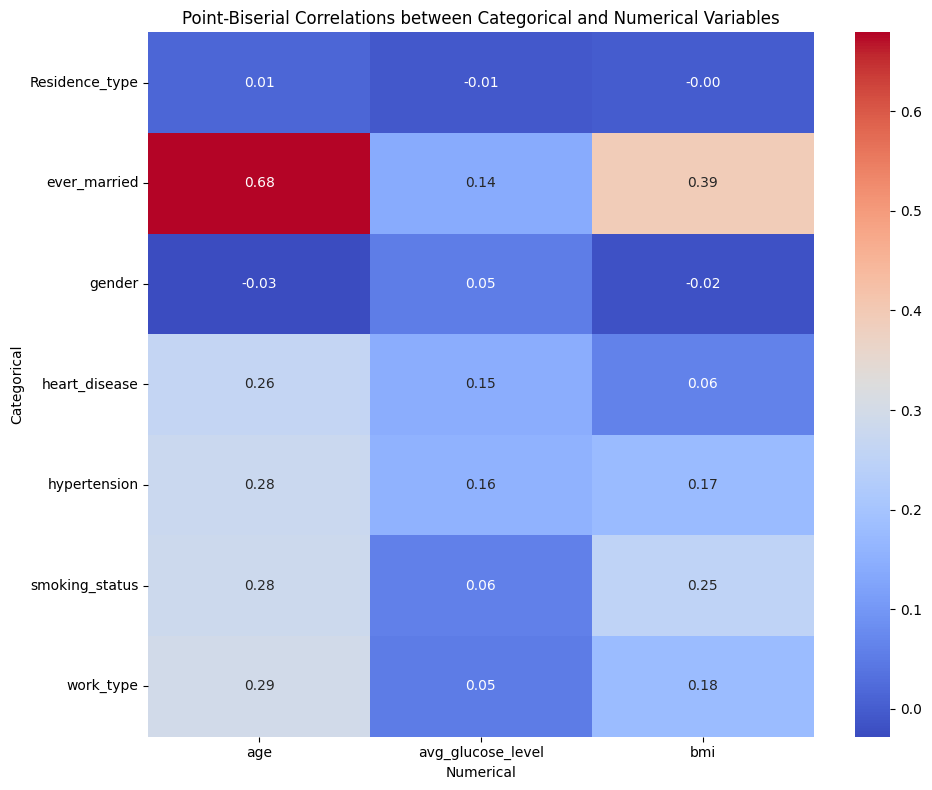

In [ ]:
# Create a DataFrame to store correlation results
pb_results = []
for num_col in numerical_cols:  # Exclude 'id'
    for cat_col in categorical_cols:
        r, p = pointbiserialr(df_imp[cat_col].cat.codes, df_imp[num_col])
        pb_results.append({
            'Numerical': num_col,
            'Categorical': cat_col,
            'Correlation': r,
            'p-value': p,
            'Significant': p < 0.01
        })

# Convert to DataFrame and sort by correlation strength
pb_df = pd.DataFrame(pb_results)
pb_df = pb_df.sort_values(by='Correlation', key=abs, ascending=False)

# Visualize the correlations
plt.figure(figsize=(10, 8))
pivot_df = pb_df.pivot(index='Categorical', columns='Numerical', values='Correlation')
sns.heatmap(pivot_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Point-Biserial Correlations between Categorical and Numerical Variables')
plt.tight_layout()

### EDA Summary

- **Data Cleaning:** Converted categorical columns to `category` dtype, merged rare categories, and imputed missing BMI values using IterativeImputer with RandomForestRegressor.
- **Class Imbalance:** Stroke cases are rare (~5%), guiding focus on recall and average precision for modeling.
- **Distributions:** Age and avg_glucose_level are right-skewed; BMI moderately skewed with outliers. Log transformation improved symmetry.
- **Associations:** Age and avg_glucose_level are most strongly associated with stroke; BMI shows weaker effect. Hypertension, heart disease, and smoking status also display notable associations.
- **Missing Data:** BMI missingness is not MCAR but weakly MAR; sensitivity analysis confirms robustness of BMI–stroke relationship to MNAR scenarios.
- **Outliers:** Detected using IQR and z-score methods; handled via transformation and robust modeling.
- **Predictor Relationships:** No strong multicollinearity among predictors; most categorical associations are weak except for ever_married/work_type.
- **Visualization:** Used countplots, violin plots, boxplots, and heatmaps to explore distributions and relationships.

# Statistical Inference

'Residence_type',
 'age',
 'avg_glucose_level',
 'bmi',
 'ever_married',
 'gender',
 'heart_disease',
 'hypertension',
 'smoking_status',
 'stroke',
 'work_type'

**Target population:**  

Patients gathered in dataset (5110 in total) that are potentially at risk of stroke, from whom we want to infer patterns in gender, age, cardiovascular diseases, work type and marriage status across different outcome (stroke) classes.

**Significance level (α):** 0.01

We will test:  

1. H₀: μ₁(Age|Stroke)=μ₂(Age|No stroke)  
2. H₀: μ₁(Avg_glucose_level|Stroke)=μ₂(Avg_glucose_level|No Stroke)  
3. H₀: μ₁(bmi|Stroke)=μ₂(bmi|No stroke) 
4. H₀: p₁(ever_married|Stroke)=p₂(ever_married|No stroke)  
5. H₀: p₁(gender|Stroke)=p₂(gender|No stroke)  
6. H₀: p₁(heart_disease|Stroke)=p₂(heart_disease|No stroke)  
7. H₀: p₁(hypertension|Stroke)=p₂(hypertension|No stroke)  

For multi-category predictors:

1. H₀: smoking_status distribution is independent of stroke status
    (Testing if the proportions of Unknown, ever_smoked, and never smoked categories differ between stroke/no stroke groups)

2. H₀: work_type distribution is independent of stroke status
    (Testing if the proportions of Private, Self-employed, other, and Govt_job categories differ between stroke/no stroke groups)

For these multi-category variables, chi-square tests of independence + Cramer's V for effect size will be used.

For (1)–(3) two‐sample t‐tests + 95% CI for the mean difference are used.  
For (4)–(7) two‐sample z‐tests for proportions + 95% CI for the difference are used.

In [ ]:
def multi_chi_square_test(df, predictor, target, alpha=0.01):
    """
    Perform chi-square test of independence between a multi-category predictor and a binary target.
    - Displays chi-square statistic, p-value, standardized residuals.
    - If significant, fits logistic regression (with 99% CI), shows odds ratios, and predicted stroke probabilities per group.
    - Performs pairwise proportion z-tests between each predictor category and reference, with multiple testing corrections.
    """
    # Create contingency table
    table = pd.crosstab(df[predictor], df[target])
    chi_statistic, p, dof, expected = chi2_contingency(table)

    print(f'Chi-square test for {predictor} vs {target}:')
    print(f'Chi-square: {chi_statistic:.4f}, p-value: {p:.4f}, df: {dof}\n')

    std_res = (table - expected) / np.sqrt(expected)
    print('Standardized Residuals:')
    display(std_res)

    if p < alpha:
        # Create a copy of the dataframe for modeling
        df_model = df.copy()

        # Ensure target is numeric (0/1) for logistic regression
        if df[target].dtype.name == 'category':
            # Convert category to numeric (0 and 1)
            df_model[target] = df_model[target].cat.codes

        # Fit logistic regression
        formula = f'{target} ~ C({predictor})'
        lr = smf.logit(formula, data=df_model).fit(disp=0)
        print(f'\nLogistic Regression Results for {predictor} ({int((1 - alpha) * 100)}%):')
        coef_tbl = lr.summary2().tables[1]
        ci99 = lr.conf_int(alpha=alpha)
        ci99.columns = ['CI_low_99', 'CI_high_99']
        coef_tbl = coef_tbl.join(ci99)

        # Odds ratios with 99% CI
        or_tbl = pd.DataFrame({
            'OR': np.exp(coef_tbl['Coef.']),
            'OR_CI_low_99': np.exp(coef_tbl['CI_low_99']),
            'OR_CI_high_99': np.exp(coef_tbl['CI_high_99']),
            'p-value': round(coef_tbl['P>|z|'], ndigits=4)
        })

        display(coef_tbl[['Coef.', 'Std.Err.', 'z', 'P>|z|', 'CI_low_99', 'CI_high_99']])
        print(f"\nOdds Ratios with {int((1 - alpha) * 100)}% CI:")
        display(or_tbl)

        print(f'Predictions of stroke for {predictor} groups:')
        pred_df = pd.DataFrame({f'{predictor}': df_model[predictor].cat.categories, })
        pred_df['Predicted_Stroke'] = lr.predict(pred_df)
        X_pred = np.zeros((len(pred_df), len(lr.params)))  # Removed the comma
        X_pred[:, 0] = 1.0
        for i, param_name in enumerate(lr.params.index[1:], start=1):
            if '[T.' in param_name:
                category = param_name.split('[T.')[1].split(']')[0]
                cat_indices = pred_df.index[pred_df[predictor] == category].tolist()
                if cat_indices:
                    X_pred[cat_indices[0], i] = 1
        lin_pred = X_pred @ lr.params
        SE = np.sqrt(np.diag(X_pred @ lr.cov_params() @ X_pred.T))
        z_value = stats.norm.ppf(1 - alpha / 2)

        lower_bound = lin_pred - z_value * SE
        upper_bound = lin_pred + z_value * SE

        pred_df['CI_low_99'] = 1 / (1 + np.exp(-lower_bound))
        pred_df['CI_high_99'] = 1 / (1 + np.exp(-upper_bound))
        display(pred_df)

        """
        Pairwise proportion tests for each category of the predictor against the reference category:
        H0: Proportion of stroke in predictor category = Proportion of stroke in reference predictor category
        H1: Proportion of stroke in predictor category != Proportion of stroke in reference predictor category
        """
        print(f'\nPairwise proportion tests for {predictor} vs {target}:')
        ref_cat = sorted(table.index)[0]
        results = []
        for cat in sorted(table.index)[1:]:
            prop_test = sms.proportions_ztest(
                np.array([table.loc[cat, 1], table.loc[ref_cat, 1]]),
                np.array([table.loc[cat].sum(), table.loc[ref_cat].sum()]),
                alternative='two-sided'
            )
            results.append({
                'Category': cat,
                'z-statistic': prop_test[0],
                'p-value': round(prop_test[1], ndigits=4),
                'stroke_rate_cat': table.loc[cat, 1] / table.loc[cat].sum(),
                'stroke_rate_ref': table.loc[ref_cat, 1] / table.loc[ref_cat].sum(),
                'diff': table.loc[cat, 1] / table.loc[cat].sum() - table.loc[ref_cat, 1] / table.loc[ref_cat].sum()
            })
        pairwise_df = pd.DataFrame(results)
        pairwise_df['p_holm'] = sms.multipletests(pairwise_df['p-value'], method='holm')[1].round(4)
        pairwise_df['p_fdr'] = sms.multipletests(pairwise_df['p-value'], method='fdr_bh')[1].round(4)
        display(pairwise_df.sort_values(by='p-value'))

In [ ]:
"""
Test for 'work_type' vs 'stroke' using the multi_chi_square_test function

Returns:
---
- Chi-square statistic, p-value, degrees of freedom
- Standardized residuals
- Logistic regression results with 99% confidence intervals
- Odds ratios with 99% confidence intervals
- Predictions of stroke for each work type category with 99% confidence intervals
- Pairwise proportion tests against the reference category
"""
multi_chi_square_test(df_imp, 'work_type', 'stroke')

Chi-square test for work_type vs stroke:
Chi-square: 49.1553, p-value: 0.0000, df: 3

Standardized Residuals:


stroke,0,1
work_type,,
Govt_job,-0.039179,0.173088
other,1.253554,-5.538110
Private,-0.123085,0.543781
Self-employed,-0.898678,3.970293



Logistic Regression Results for work_type (99%):


,Coef.,Std.Err.,z,P>|z|,CI_low_99,CI_high_99
Intercept,-2.939643,0.178621,-16.457397,7.422451e-61,-3.399741,-2.479545
C(work_type)[T.other],-2.928241,0.730288,-4.009709,6.079369e-05,-4.809337,-1.047144
C(work_type)[T.Private],0.015183,0.197427,0.076905,9.386992e-01,-0.493355,0.523721
C(work_type)[T.Self-employed],0.488638,0.220491,2.216130,2.668259e-02,-0.079311,1.056586



Odds Ratios with 99% CI:


,OR,OR_CI_low_99,OR_CI_high_99,p-value
Intercept,0.052885,0.033382,0.083781,0.0000
C(work_type)[T.other],0.053491,0.008153,0.350938,0.0001
C(work_type)[T.Private],1.015299,0.610575,1.688298,0.9387
C(work_type)[T.Self-employed],1.630094,0.923753,2.876534,0.0267


Predictions of stroke for work_type groups:


,work_type,Predicted_Stroke,CI_low_99,CI_high_99
0,Govt_job,0.050228,0.032304,0.077305
1,other,0.002821,0.000456,0.017227
2,Private,0.050958,0.041445,0.062512
3,Self-employed,0.079365,0.058196,0.107357



Pairwise proportion tests for work_type vs stroke:


,Category,z-statistic,p-value,stroke_rate_cat,stroke_rate_ref,diff,p_holm,p_fdr
2,other,-5.540572,0.0000,0.002821,0.050228,-0.047407,0.0000,0.0000
1,Self-employed,2.234455,0.0255,0.079365,0.050228,0.029137,0.0510,0.0382
0,Private,0.076906,0.9387,0.050958,0.050228,0.000729,0.9387,0.9387


<ul>
    <li><strong>Chi-square test:</strong> Significant association between work type and stroke (χ² = 49.16, p &lt; 0.001).</li>
    <li><strong>Standardized residuals:</strong> "other" work type has much fewer strokes than expected; "Self-employed" has more than expected.</li>
    <li><strong>Logistic regression:</strong>
        <ul>
            <li>"other" work type has much lower odds of stroke (OR = 0.05, p &lt; 0.001).</li>
            <li>"Self-employed" has higher odds of stroke (OR = 1.63, p = 0.027).</li>
            <li>"Private" work type shows no significant difference.</li>
        </ul>
    </li>
    <li><strong>Predicted stroke rates:</strong>
        <ul>
            <li>Lowest for "other" (0.28%), highest for "Self-employed" (7.9%).</li>
        </ul>
    </li>
    <li><strong>Pairwise tests:</strong>
        <ul>
            <li>"other" vs others: significantly lower stroke rate.</li>
            <li>"Self-employed" vs others: significantly higher stroke rate.</li>
            <li>"Private" vs others: no significant difference.</li>
        </ul>
    </li>
</ul>


In [ ]:
"""
Test for 'smoking_status' vs 'stroke' using the multi_chi_square_test function
"""
multi_chi_square_test(df_imp, 'smoking_status', 'stroke')

Chi-square test for smoking_status vs stroke:
Chi-square: 23.1686, p-value: 0.0000, df: 2

Standardized Residuals:


stroke,0,1
smoking_status,,
Unknown,0.737150,-3.256675
ever_smoked,-0.763593,3.373498
never smoked,0.052126,-0.230289



Logistic Regression Results for smoking_status (99%):


,Coef.,Std.Err.,z,P>|z|,CI_low_99,CI_high_99
Intercept,-3.461071,0.148137,-23.363971,9.938448e-121,-3.842647,-3.079495
C(smoking_status)[T.ever_smoked],0.826488,0.177521,4.655712,3.228626e-06,0.369223,1.283752
C(smoking_status)[T.never smoked],0.464228,0.183332,2.532170,1.133589e-02,-0.008004,0.936460



Odds Ratios with 99% CI:


,OR,OR_CI_low_99,OR_CI_high_99,p-value
Intercept,0.031396,0.021437,0.045982,0.0000
C(smoking_status)[T.ever_smoked],2.285278,1.446611,3.610160,0.0000
C(smoking_status)[T.never smoked],1.590786,0.992028,2.550935,0.0113


Predictions of stroke for smoking_status groups:


,smoking_status,Predicted_Stroke,CI_low_99,CI_high_99
0,Unknown,0.030440,0.020987,0.043961
1,ever_smoked,0.066946,0.052822,0.084508
2,never smoked,0.047569,0.036437,0.061883



Pairwise proportion tests for smoking_status vs stroke:


,Category,z-statistic,p-value,stroke_rate_cat,stroke_rate_ref,diff,p_holm,p_fdr
0,ever_smoked,4.772374,0.0000,0.066946,0.03044,0.036505,0.0000,0.0000
1,never smoked,2.552546,0.0107,0.047569,0.03044,0.017128,0.0107,0.0107


## Two-Sample t-test

### Assumptions

#### Normality

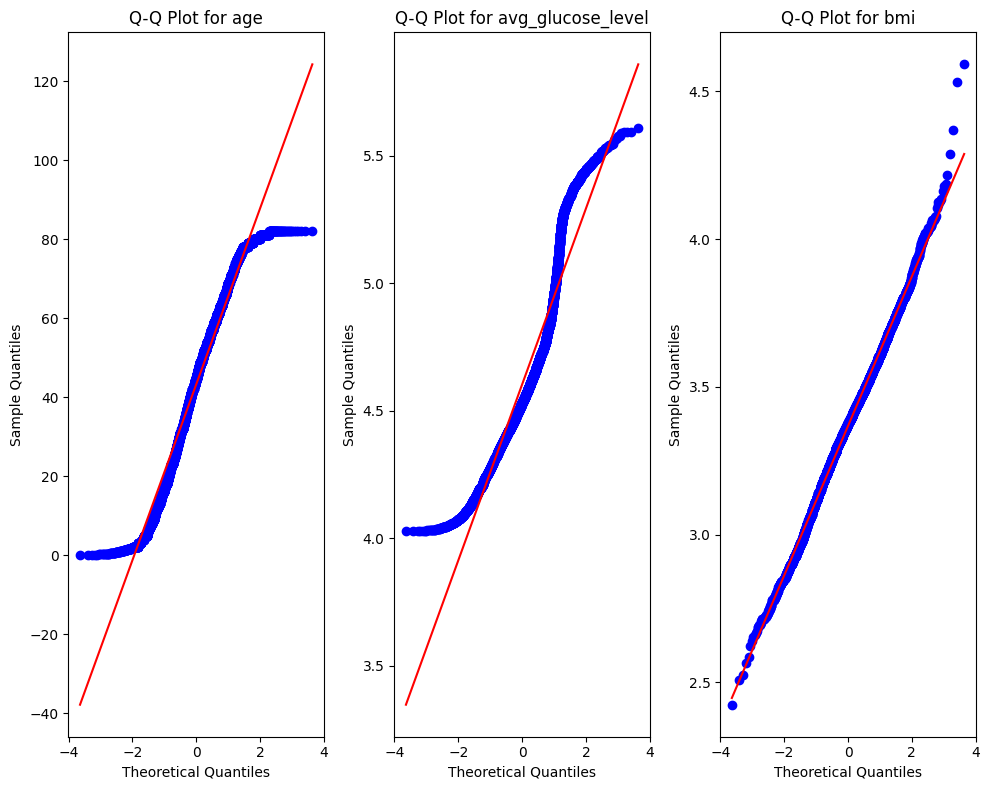

In [ ]:
"""Assumption checks for z- and t- Tests"""
# Normality checks for t-tests
fig, axes = plt.subplots(1, 3, figsize=(10, 8))
for i, col in enumerate(df_imp.select_dtypes(exclude=['category']).columns.drop(['id']).tolist()):
    probplot(df_imp[col], dist='norm', plot=axes[i])
    axes[i].set_title(f'Q-Q Plot for {col}')
    axes[i].set_xlabel('Theoretical Quantiles')
    axes[i].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

Moderate non-normality in `avg_glucose_level` is negated by large sample size (5000+ observations) in which Central Limit Theorem (CLT) is applied. Based on prior log-transformation and skew results, variables left as is and results will be validated empirically with bootstrapping.

### Independance

Only indication of independance is patient ID uniqueness, but:

No variables indicating:

    - Family relationships,
    - Multiple measurements, 
    - Geographical regions,
    - Other variables indicating dependability

Since dataset source is **confidential**, we cannot extract information of data collection. If the dataset was collected as a cross-sectional sample of individuals, we can assume the independancy of data points.

### Outliers

Handled in EDA

### Homoscedasticity

Will be addressed with **Welch's t-test**

### Random Sampling

Unknown - confidential information of data collection as per dataset source.

In [ ]:
def mean_diffs_ci(a, b, alpha=0.01):
    """Calculate mean difference and confidence interval for two samples.
       Unpooled approach is used based on violin plots.
    """
    n1, n2 = len(a), len(b)
    mean_diff = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1) / n1 + b.var(ddof=1) / n2)

    # Calculate degrees of freedom using Welch's formula
    df = ((a.var(ddof=1) / n1 + b.var(ddof=1) / n2)**2) / \
        ((a.var(ddof=1) / n1)**2 / (n1 - 1) + (b.var(ddof=1) / n2)**2 / (n2 - 1))
    t_crit = stats.t.ppf(1 - alpha / 2, df=df)
    ci_lower = (mean_diff - t_crit * se).round(4)
    ci_upper = (mean_diff + t_crit * se).round(4)
    t_statistic = mean_diff / se
    # Calculate p-value for two-tailed test
    p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df=df))

    return mean_diff, (float(ci_lower), float(ci_upper)), p_value


Age_Yes = df_imp.loc[df_imp['stroke'] == 1, 'age']
Age_No = df_imp.loc[df_imp['stroke'] == 0, 'age']
mean_diff_age, ci_age, p_value_age = mean_diffs_ci(Age_Yes, Age_No)
print(
    f"Results of age between different stroke groups:\nMean diff: {
        mean_diff_age:.2f}, 99% CI: {ci_age}, p-value: {
            p_value_age:.3f}")

Results of age between different stroke groups:
Mean diff: 25.75, 99% CI: (23.5055, 28.0012), p-value: 0.000


In [ ]:
avg_glucose_yes = df_imp.loc[df_imp['stroke'] == 1, 'avg_glucose_level']
avg_glucose_no = df_imp.loc[df_imp['stroke'] == 0, 'avg_glucose_level']
mean_diff_g, ci_g, p_value_g = mean_diffs_ci(avg_glucose_yes, avg_glucose_no)
print(
    f"Results of average glucose level between different stroke groups:\n{
        mean_diff_g:.2f}, 99% CI: {ci_g}, p-value: {
            p_value_g:.3f}")

Results of average glucose level between different stroke groups:
0.20, 99% CI: (0.1187, 0.2719), p-value: 0.000


In [ ]:
bmi_yes = df_imp.loc[df_imp['stroke'] == 1, 'bmi']
bmi_no = df_imp.loc[df_imp['stroke'] == 0, 'bmi']
mean_diff_bmi, ci_bmi, p_value_bmi = mean_diffs_ci(bmi_yes, bmi_no)
print(
    f"Results of BMI between different stroke groups:\nMean diff: {
        mean_diff_bmi:.2f}, 99% CI: {ci_bmi}, p-value: {
            p_value_bmi:.3f}")

Results of BMI between different stroke groups:
Mean diff: 0.06, 99% CI: (0.0311, 0.0941), p-value: 0.000


In [ ]:
t_results = pd.DataFrame({
    'Mean Difference': [mean_diff_age, mean_diff_g, mean_diff_bmi],
    '99% CI': [ci_age, ci_g, ci_bmi],
    'p-value': [p_value_age, p_value_g, p_value_bmi],
}, index=['age', 'avg_glucose_level', 'bmi']).T

t_results

,age,avg_glucose_level,bmi
Mean Difference,25.753361,0.195297,0.062613
99% CI,"(23.5055, 28.0012)","(0.1187, 0.2719)","(0.0311, 0.0941)"
p-value,0.0,0.0,0.0


- **Age:** Stroke cases are, on average, 25.75 years older than non-stroke cases (99% CI: 23.51–28.00, p < 0.01), indicating a strong association between age and stroke occurrence.
- **Avg Glucose Level:** Stroke cases have a higher average glucose level by 0.20 units (99% CI: 0.12–0.27, p < 0.01), suggesting elevated glucose is linked to stroke risk.
- **BMI:** Stroke cases show a small but statistically significant increase in BMI (mean diff: 0.06, 99% CI: 0.03–0.09, p < 0.01), though the effect size is minimal.

All differences are statistically significant at α = 0.01, with age showing the largest and most clinically meaningful separation between groups.


### Bootstrap Validation

In [ ]:
def bootstrap_t_test(a, b, n_iterations=10000, alpha=0.01):
    """Perform bootstrap t-test to estimate confidence intervals."""
    boot_diffs = []
    for _ in range(n_iterations):
        a_sample = resample(a, replace=True, n_samples=len(a))
        b_sample = resample(b, replace=True, n_samples=len(b))
        mean_diff = a_sample.mean() - b_sample.mean()
        boot_diffs.append(mean_diff)

    lower_bound = np.percentile(boot_diffs, 100 * alpha / 2)
    upper_bound = np.percentile(boot_diffs, 100 * (1 - alpha / 2))
    return round(float(lower_bound), 4), round(float(upper_bound), 4)

In [ ]:
age_bootstrap_ci = bootstrap_t_test(Age_Yes, Age_No)
print(f"Bootstrap CI for age mean difference: {age_bootstrap_ci}")
print(f'Parametric t-test CI for age mean difference: {ci_age}')
avg_glucose_bootstrap_ci = bootstrap_t_test(avg_glucose_yes, avg_glucose_no)
print(f"Bootstrap CI for average glucose level mean difference: {avg_glucose_bootstrap_ci}")
print(f'Parametric t-test CI for average glucose level mean difference: {ci_g}')
bmi_bootstrap_ci = bootstrap_t_test(bmi_yes, bmi_no)
print(f"Bootstrap CI for BMI mean difference: {bmi_bootstrap_ci}")
print(f'Parametric t-test CI for BMI mean difference: {ci_bmi}')

Bootstrap CI for age mean difference: (23.4495, 27.9213)
Parametric t-test CI for age mean difference: (23.5055, 28.0012)
Bootstrap CI for average glucose level mean difference: (0.1212, 0.2719)
Parametric t-test CI for average glucose level mean difference: (0.1187, 0.2719)
Bootstrap CI for BMI mean difference: (0.0315, 0.0942)
Parametric t-test CI for BMI mean difference: (0.0311, 0.0941)


Bootstrap confidence intervals closely match parametric t-test intervals for all predictors, confirming the robustness of mean difference estimates despite moderate non-normality and outliers. This validates the reliability of statistical inference for age, average glucose level, and BMI differences between stroke groups, supporting the use of standard parametric methods in this large dataset.


## Two-Sample z-test

### Assumptions

#### Sample Counts

Check whether normal approximation to the binomial distribution can be assumed with sufficient cell counts.

Rule of thumb: for each group (stroke vs no stroke) and each level of a binary predictor, we need  
- np ≥ 5  
- n(1–p) ≥ 5

In [ ]:
binary_cols = [col for col in categorical_cols if col not in ['smoking_status', 'work_type']]
for col in binary_cols:
    ct = pd.crosstab(df_imp[col], df_imp['stroke'], margins=True, margins_name='Total')

    # Check if any category has fewer than 5 stroke cases
    mask = ct.values < 5  # Assuming 1 represents stroke cases
    if mask.any():
        print(f"Low counts of stroke and {col} are detected:")
        display(ct.loc[mask])
        continue
    else:
        print(f"Counts of stroke and {col} are sufficient for normal approximation assumption:")
    display(ct)

Counts of stroke and gender are sufficient for normal approximation assumption:


stroke,0,1,Total
gender,,,
Female,2853,141,2994
Male,2007,108,2115
Total,4860,249,5109


Counts of stroke and hypertension are sufficient for normal approximation assumption:


stroke,0,1,Total
hypertension,,,
0,4428,183,4611
1,432,66,498
Total,4860,249,5109


Counts of stroke and heart_disease are sufficient for normal approximation assumption:


stroke,0,1,Total
heart_disease,,,
0,4631,202,4833
1,229,47,276
Total,4860,249,5109


Counts of stroke and ever_married are sufficient for normal approximation assumption:


stroke,0,1,Total
ever_married,,,
No,1727,29,1756
Yes,3133,220,3353
Total,4860,249,5109


Counts of stroke and Residence_type are sufficient for normal approximation assumption:


stroke,0,1,Total
Residence_type,,,
Rural,2399,114,2513
Urban,2461,135,2596
Total,4860,249,5109


In [ ]:
z_results = pd.DataFrame(
    columns=binary_cols,
    index=['Prop Difference', '99% CI', 'p-value']).T


def prop_diffs_z(a, b, alpha=0.01):
    """Calculate proportion difference and confidence interval for two samples."""
    n1, n2 = len(a), len(b)
    prop_diff = a.mean() - b.mean()
    se = np.sqrt((a.mean() * (1 - a.mean()) / n1) + (b.mean() * ((1 - b.mean()) / n2)))

    z_crit = norm.ppf(1 - alpha / 2)
    ci_lower = prop_diff - z_crit * se.round(4)
    ci_upper = prop_diff + z_crit * se
    z_statistic = prop_diff / se
    p_value = 2 * (1 - norm.cdf(abs(z_statistic)))
    return prop_diff, (round(float(ci_lower), 4), round(float(ci_upper), 4)), p_value

In [29]:
for col in binary_cols:
    if col in df_imp.columns and isinstance(df_imp[col].dtype, pd.CategoricalDtype):
        col_yes = df_imp.loc[df_imp['stroke'] == 1, col].cat.codes
        col_no = df_imp.loc[df_imp['stroke'] == 0, col].cat.codes
        prop_diff, ci, p_value = prop_diffs_z(col_yes, col_no)
        z_results.loc[col, 'Prop Difference'] = prop_diff
        z_results.loc[col, '99% CI'] = str(ci)  # Convert tuple to string
        z_results.loc[col, 'p-value'] = p_value

display(z_results)

,Prop Difference,99% CI,p-value
gender,0.020445,"(-0.0625, 0.1034)",0.525344
hypertension,0.17619,"(0.1033, 0.249)",0.0
heart_disease,0.141645,"(0.0772, 0.206)",0.0
ever_married,0.239017,"(0.1836, 0.2943)",0.0
Residence_type,0.035894,"(-0.0476, 0.1193)",0.267594


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Prop Difference</th>
      <th>99% CI</th>
      <th>p-value</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>gender</th>
      <td>0.020772</td>
      <td>(-0.0622, 0.1037)</td>
      <td>0.518751</td>
    </tr>
    <tr>
      <th>hypertension</th>
      <td>0.176171</td>
      <td>(0.1033, 0.249)</td>
      <td>0.0</td>
    </tr>
    <tr>
      <th>heart_disease</th>
      <td>0.141636</td>
      <td>(0.0772, 0.206)</td>
      <td>0.0</td>
    </tr>
    <tr>
      <th>ever_married</th>
      <td>0.238884</td>
      <td>(0.1835, 0.2942)</td>
      <td>0.0</td>
    </tr>
    <tr>
      <th>Residence_type</th>
      <td>0.03579</td>
      <td>(-0.0477, 0.1192)</td>
      <td>0.268987</td>
    </tr>
  </tbody>
</table>
</div>

- **Hypertension, heart disease, and ever_married** show statistically significant differences in proportions between stroke and non-stroke groups (all p < 0.01, 99% CI excludes zero), indicating these factors are associated with stroke risk.
- **Gender** and **Residence_type** do not show significant differences (p > 0.01, 99% CI includes zero), suggesting no strong association with stroke occurrence in this dataset.


# Machine Learning Model Creation

## Baseline Models

In this section we create several baseline models without any feature engineering to track metric changes further into model development. Create train and hold-out datasets for model training and evaluations:

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df2.drop(columns=['stroke', 'id']),
    df2['stroke'],
    test_size=0.2,
    shuffle=True,
    stratify=df2['stroke'],
    random_state=RANDOM_STATE
)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

num_imp = Pipeline([
    ('imp', IterativeImputer(
        estimator=RandomForestRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
            criterion='squared_error',
            max_depth=8,
            min_samples_split=20,
            min_samples_leaf=10,
        ),
        sample_posterior=False,
        max_iter=10,
        random_state=RANDOM_STATE,
        skip_complete=True
    ))
])

# Columns to log-transform
_log_cols = ['avg_glucose_level', 'bmi']

# Ensure we don't apply multiple transformers to the same numerical columns
_num_cols_no_log = [c for c in numerical_cols if c not in _log_cols]

transformer = ColumnTransformer(
    transformers=[
        ('age', Pipeline([('imp', num_imp), ('scale', StandardScaler().set_output(transform='pandas'))]), _num_cols_no_log),
        ('glucose0_bmi1', Pipeline(
            [('imp', num_imp), ('scale', StandardScaler().set_output(transform='pandas'))]), _log_cols),
        ('cat', TargetEncoder(smoothing=0.3, handle_missing='value', min_samples_leaf=20), categorical_cols),
    ],
    remainder=SimpleImputer(strategy='most_frequent')  # Handle any remaining columns
)

baseline_dummy_model = make_pipeline(
    transformer,
    DummyClassifier(strategy='most_frequent')
)

baseline_tree_model = make_pipeline(
    transformer,
    DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        max_depth=8,
        min_samples_leaf=20,
        min_samples_split=20)
)

baseline_logreg_model = make_pipeline(
    transformer,
    LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=2500)
)

scoring = ['average_precision', 'f1', 'recall']

cv_dummy_baseline = cross_validate(
    baseline_dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

cv_tree_baseline = cross_validate(
    baseline_tree_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

cv_logreg_baseline = cross_validate(
    baseline_logreg_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

baseline_columns = pd.MultiIndex.from_tuples([
    ('AP', 'Dummy_Classifier'),
    ('AP', 'Decision_Tree'),
    ('AP', 'Logistic_Regression'),
    ('F1', 'Dummy_Classifier'),
    ('F1', 'Decision_Tree'),
    ('F1', 'Logistic_Regression'),
    ('Recall', 'Dummy_Classifier'),
    ('Recall', 'Decision_Tree'),
    ('Recall', 'Logistic_Regression'),
])

baseline_results = pd.DataFrame(
    np.column_stack([
        cv_dummy_baseline['test_average_precision'],
        cv_tree_baseline['test_average_precision'],
        cv_logreg_baseline['test_average_precision'],
        cv_dummy_baseline['test_f1'],
        cv_tree_baseline['test_f1'],
        cv_logreg_baseline['test_f1'],
        cv_dummy_baseline['test_recall'],
        cv_tree_baseline['test_recall'],
        cv_logreg_baseline['test_recall'],
    ]),
    index=np.arange(len(cv_dummy_baseline['test_average_precision'])) + 1,
    columns=baseline_columns
)
baseline_results = baseline_results.stack([0, 1]).reset_index().rename(
    columns={'level_0': 'Fold', 'level_1': 'Metric', 'level_2': 'Model', 0: 'Score'})

<Axes: xlabel='Score', ylabel='Metric'>

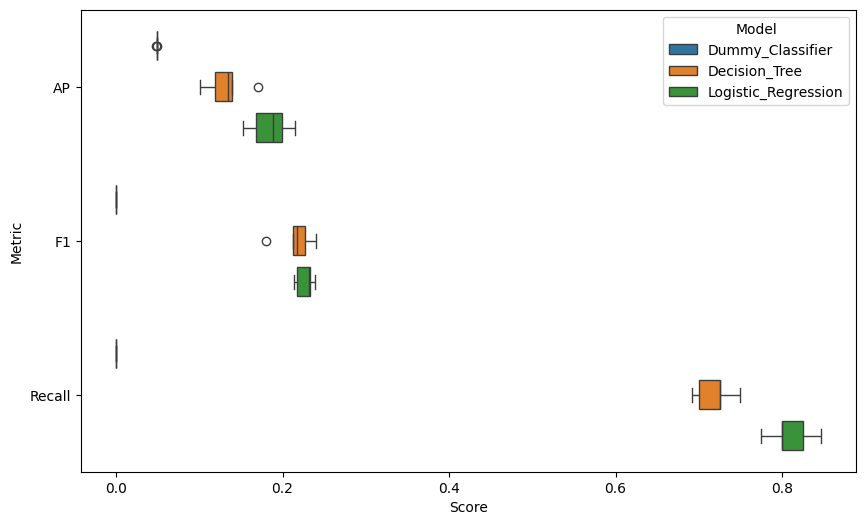

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=baseline_results, x='Score', y='Metric', hue='Model', gap=0.3)

- **Dummy Classifier:** Very low scores for all metrics (AP, F1, Recall), reflecting class imbalance and no predictive power.
- **Decision Tree:** Improves recall and F1 over dummy, but average precision remains modest.
- **Logistic Regression:** Highest recall and average precision among baselines, showing best discrimination for stroke prediction.
- **Overall:** Logistic regression is the strongest baseline; tree model is reasonable; dummy sets the lower bound for comparison.

Create a few helper functions for later use:

In [ ]:
def cross_val_results(model, X, y, cv, *scoring, name='Model'):
    """
    Perform cross-validation for a given model and dataset.

    Parameters:
        model: scikit-learn estimator or pipeline.
        X: Features (DataFrame or array).
        y: Target variable.
        cv: Cross-validation splitter (e.g., StratifiedKFold).
        *scoring: Metric names (strings) to evaluate.
        name: Model name for result labeling.

    Returns:
        DataFrame with fold-wise test scores for each metric and model.
        Prints mean and standard deviation for train/test scores per metric.
    """
    print(f"Performing cross-validation with {cv.get_n_splits()} folds...")
    res = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
    for type in ['Train', 'Test']:
        for i in range(len(scoring)):
            print(f"Mean {type} {scoring[i]} score: {res[f'{type.lower()}_{scoring[i].lower()}'].mean(
            )} +- {res[f'{type.lower()}_{scoring[i].lower()}'].std()}")
        print("-" * 60)
    columns = pd.MultiIndex.from_tuples([
        (scoring[i].upper(), name) for i in range(len(scoring))
    ])
    df = pd.DataFrame(
        np.column_stack([
            res[f'test_{s}'] for s in scoring
        ]),
        index=np.arange(len(res[f'test_{scoring[0]}'])) + 1,
        columns=columns
    )
    df = df.stack([0, 1]).reset_index().rename(
        columns={'level_0': 'Fold', 'level_1': 'Metric', 'level_2': 'Model', 0: 'Score'})

    return df

In [176]:
def show_model_weights(X, model):
    """
    Displays feature weights using eli5 for a pipeline model.
    Args:
        X (pd.DataFrame): Input features (untransformed).
        model (Pipeline): Fitted pipeline model.
    """

    # Find sampler index in pipeline steps
    idx = next((i for i, (n, _) in enumerate(model.steps) if n == 'sampler'), None)
    pre_pipeline = model[:idx] if idx is not None else model[:-1]
    final_estimator = model[-1]

    # Transform X and get feature names
    try:
        X_trans = pre_pipeline.set_output(transform='pandas').transform(X)
        feat_names = X_trans.columns.tolist()
    except Exception:
        try:
            feat_names = pre_pipeline.get_feature_names_out(X.columns)
        except Exception:
            X_trans = pre_pipeline.transform(X)
            if hasattr(X_trans, 'shape'):
                feat_names = [f'f{i}' for i in range(X_trans.shape[1])]
            else:
                feat_names = X.columns.tolist()

    # Apply selector mask if present
    sel = None
    for name, step in model.named_steps.items():
        if hasattr(step, 'get_support'):
            sel = step
    if sel is not None:
        mask = sel.get_support()
        feat_names = [n for n, m in zip(feat_names, mask) if m]

    return eli5.show_weights(final_estimator, feature_names=feat_names)

In [ ]:
def calculate_permutation_importance(model, X_tr, y_tr, X_te, y_te, n_iter=30, random_state=42):
    """
    Fit the provided pipeline/estimator on (X_tr, y_tr) and compute permutation importances
    for the final estimator using X_te/y_te. Returns a DataFrame with feature, importance, std.
    """
    # fit the pipeline/estimator (safe to refit the provided model)
    model.fit(X_tr, y_tr)

    # helper to access named_steps if model is a Pipeline
    named_steps = getattr(model, "named_steps", {}) or {}

    # try to find a preprocessor: prefer explicit names, otherwise pick the first transformer-looking step
    pre = named_steps.get("pre_smote") or named_steps.get("pre")
    if pre is None:
        for step in named_steps.values():
            if hasattr(step, "transform") and (hasattr(step, "get_feature_names_out")
                                               or isinstance(step, ColumnTransformer)):
                pre = step
                break

    # transform test set with preprocessor (or use directly if none found)
    if pre is None:
        X_pre = X_te.reset_index(drop=True)
        feat_names = X_pre.columns if isinstance(X_pre, pd.DataFrame) else list(X_pre.columns)
    else:
        X_pre = pre.transform(X_te.reset_index(drop=True))
        try:
            feat_names = pre.get_feature_names_out()
        except Exception:
            feat_names = X_pre.columns if isinstance(X_pre, pd.DataFrame) else [f"f{i}" for i in range(X_pre.shape[1])]

    df_trans = X_pre if isinstance(X_pre, pd.DataFrame) else pd.DataFrame(
        X_pre, columns=feat_names, index=X_te.reset_index(drop=True).index)

    # locate a selector (if any) among named steps
    sel = named_steps.get("selector")
    if sel is None:
        for step in named_steps.values():
            if hasattr(step, "get_support"):
                sel = step
                break

    if sel is not None and hasattr(sel, "get_support"):
        feat_in = getattr(sel, "feature_names_in_", None)
        if feat_in is not None:
            missing = [c for c in feat_in if c not in df_trans.columns]
            if missing:
                raise ValueError(f"Missing columns expected by selector: {missing}")
            df_trans = df_trans.loc[:, feat_in]

        X_sel = sel.transform(df_trans)
        # derive selected column names
        try:
            selected_cols = df_trans.columns[sel.get_support(indices=True)]
        except Exception:
            mask = sel.get_support()
            selected_cols = df_trans.columns[mask]
        X_for_model = pd.DataFrame(X_sel, columns=selected_cols, index=df_trans.index)
    else:
        X_for_model = df_trans.copy()
        selected_cols = X_for_model.columns

    # get final estimator (last step of pipeline) or the estimator itself
    try:
        final_est = model[-1]
    except Exception:
        final_est = model

    # validate expected feature count if available
    expected = getattr(final_est, "n_features_in_", None)
    if expected is not None and expected != X_for_model.shape[1]:
        raise ValueError(f"Final estimator expects {expected} features but X_for_model has {X_for_model.shape[1]}")

    # compute permutation importance using the fitted final estimator
    pi = PermutationImportance(
        final_est,
        scoring="average_precision",
        cv="prefit",
        n_iter=n_iter,
        random_state=random_state
    ).fit(X_for_model.reset_index(drop=True), y_te.reset_index(drop=True))

    perm_df = pd.DataFrame({
        "feature": list(selected_cols),
        "mean_imp": pi.feature_importances_,
        "std_imp": pi.feature_importances_std_
    }).sort_values("mean_imp", ascending=False).reset_index(drop=True)

    return perm_df

In [ ]:
def plot_perm_importance(df1, df2=None, name1='Model1', name2='Model2'):
    """
    Plots permutation importance for features from one or two DataFrames.

    Args:
        df1 (pd.DataFrame): DataFrame containing 'feature', 'mean_imp', and 'std_imp' columns for the full feature set.
        df2 (pd.DataFrame, optional): DataFrame containing permutation importance for a reduced feature set.

    The function creates bar plots of mean permutation importance for each feature, with error bars showing standard deviation.
    If df2 is provided, plots are shown side-by-side for comparison.
    """
    df1.sort_values(by='mean_imp', ascending=False, inplace=True)
    fig, ax = plt.subplots(1, 2 if df2 is not None else 1, figsize=(14, 8))

    sns.barplot(
        data=df1,
        x='mean_imp',
        y='feature',
        ax=ax[0] if df2 is not None else ax,
        palette='viridis',
        errorbar=('sd')
    )
    (ax[0] if df2 is not None else ax).errorbar(
        x=df1['mean_imp'],
        y=np.arange(len(df1)),
        xerr=df1['std_imp'],
        fmt='none',
        ecolor='black',
        capsize=3,
        label='Std Error'
    )
    (ax[0] if df2 is not None else ax).set_title(f'{name1} Permutation Importance')
    (ax[0] if df2 is not None else ax).set_xlabel('Mean Importance')
    (ax[0] if df2 is not None else ax).set_ylabel('Feature')

    if df2 is not None:
        df2.sort_values(by='mean_imp', ascending=False, inplace=True)
        sns.barplot(data=df2, x='mean_imp', y='feature', ax=ax[1], palette='viridis', ci=None)
        ax[1].errorbar(
            x=df2['mean_imp'],
            y=np.arange(len(df2)),
            xerr=df2['std_imp'],
            fmt='none',
            ecolor='black',
            capsize=3,
            label='Std Error'
        )
        ax[1].set_title(f'{name2} Permutation Importance')
        ax[1].set_xlabel('Mean Importance')
        ax[1].set_ylabel('Feature')

    plt.tight_layout()
    plt.show()

In [375]:
def plot_confusion_matrices(cm_dict, thresholds):
    """
    Plots confusion matrices as heatmaps in a 2x2 grid.

    Args:
        cm_dict (dict): Dictionary where keys are model names (str) and values are confusion matrices (2x2 numpy arrays).
    """
    import matplotlib.pyplot as plt
    l = len(cm_dict)
    if l == 0:
        print("No confusion matrices to display.")
        return
    row = (l - 1) // 2 + 1
    col = 2 if l > 1 else 1
    fig, axes = plt.subplots(row, col, figsize=(12, 10))
    axes = axes.flatten()
    used_axes = 0
    for i, (model_name, cm) in enumerate(cm_dict.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f"{model_name} Confusion Matrix (threshold > {float(thresholds[i]):.3f})")
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
        used_axes += 1

    for j in range(used_axes, row * col):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_precision_recall_curve(y_true, y_scores, model_name="Model", subplots=None):
    """
    Plots the precision-recall curve for given true labels and predicted probabilities.

    Args:
        y_true (array-like): True binary labels.
        y_scores (array-like or list of arrays): Predicted probabilities for the positive class.
        model_name (str or list): Name(s) of the model(s) for the plot title.
        subplots (int or None): If provided, prepares a grid with that many subplots; the curves will be plotted on the first axes available.
    """
    # Normalize inputs to lists when using multiple plots
    if subplots:
        if not isinstance(y_scores, list):
            y_scores = [y_scores]
        if not isinstance(model_name, list):
            model_name = [model_name] * len(y_scores)

        n = int(subplots)
        ncols = 2
        nrows = (n - 1) // 2 + 1
        fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))
        axes = axes.flatten()
        num_models = len(y_scores)

        for i in range(min(num_models, len(axes))):
            ax = axes[i]
            precision, recall, thresholds = precision_recall_curve(y_true, y_scores[i])
            ap = average_precision_score(y_true, y_scores[i])
            f1_score = (2 * precision * recall) / (precision + recall + 1e-10)
            optimal_idx = int(np.nanargmax(f1_score))
            best_precision, best_recall = precision[optimal_idx], recall[optimal_idx]

            # Find best precision when recall > 0.8 (robust index mapping)
            recall_mask_idxs = np.where(recall > 0.8)[0]
            if recall_mask_idxs.size > 0:
                # choose the index among those with the highest precision
                sub_idx = recall_mask_idxs[int(np.argmax(precision[recall_mask_idxs]))]
                best_precision_80 = float(precision[sub_idx])
                best_recall_80 = float(recall[sub_idx])
                # map selected precision/recall index to corresponding threshold
                # (thresholds has length = len(precision) - 1)
                if thresholds.size > 0 and sub_idx > 0:
                    thresholds_80 = float(thresholds[sub_idx - 1])
                elif thresholds.size > 0:
                    thresholds_80 = float(thresholds[0])
                else:
                    thresholds_80 = float("nan")
            else:
                best_precision_80 = best_recall_80 = float("nan")
                thresholds_80 = float("nan")

            # threshold for optimal_idx (safe mapping)
            if thresholds.size > 0 and optimal_idx > 0:
                opt_threshold = float(thresholds[optimal_idx - 1])
            elif thresholds.size > 0:
                opt_threshold = float(thresholds[0])
            else:
                opt_threshold = float("nan")

            ax.plot(recall, precision, label=f'{model_name[i]} (AP={ap:.3f})')
            ax.scatter(best_recall, best_precision, color='navy', s=80,
                       label=f'Best F1 (P={best_precision:.3f}, R={best_recall:.3f})', zorder=5)
            if not np.isnan(best_precision_80):
                ax.scatter(best_recall_80, best_precision_80, color='red', s=80,
                           label=f'Best Prec (R>0.8) (Th={thresholds_80:.3f})', zorder=5)

            ax.set_xlabel('Recall')
            ax.set_ylabel('Precision')
            ax.set_title(f'Precision-Recall Curve: {model_name[i]}')
            ax.legend(loc='best', fontsize=9)
            ax.grid(True)

        # remove unused axes
        for j in range(min(len(axes), n) - 1, len(axes)):
            if j >= num_models:
                fig.delaxes(axes[j])

    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
        ap = average_precision_score(y_true, y_scores)
        f1_score = (2 * precision * recall) / (precision + recall + 1e-10)
        optimal_idx = int(np.nanargmax(f1_score))
        best_precision, best_recall = precision[optimal_idx], recall[optimal_idx]

        recall_mask_idxs = np.where(recall > 0.8)[0]
        if recall_mask_idxs.size > 0:
            sub_idx = recall_mask_idxs[int(np.argmax(precision[recall_mask_idxs]))]
            best_precision_80 = float(precision[sub_idx])
            best_recall_80 = float(recall[sub_idx])
            if thresholds.size > 0 and sub_idx > 0:
                thresholds_80 = float(thresholds[sub_idx - 1])
            elif thresholds.size > 0:
                thresholds_80 = float(thresholds[0])
            else:
                thresholds_80 = float("nan")
        else:
            best_precision_80 = best_recall_80 = float("nan")
            thresholds_80 = float("nan")

        if thresholds.size > 0 and optimal_idx > 0:
            opt_threshold = float(thresholds[optimal_idx - 1])
        elif thresholds.size > 0:
            opt_threshold = float(thresholds[0])
        else:
            opt_threshold = float("nan")

        ax.plot(recall, precision, label=f'{model_name} (AP={ap:.3f})')
        ax.scatter(best_recall, best_precision, color='navy', s=100,
                   label=f'Best F1 (P={best_precision:.3f}, R={best_recall:.3f})', zorder=5)
        if not np.isnan(best_precision_80):
            ax.scatter(best_recall_80, best_precision_80, color='red', s=100,
                       label=f'Best Prec (R>0.8) (Th={thresholds_80:.3f})', zorder=5)

        ax.annotate(f'Opt Th={opt_threshold:.3f}\nP={best_precision:.3f}\nR={best_recall:.3f}',
                    xy=(best_recall, best_precision),
                    xytext=(10, -30),
                    textcoords='offset points',
                    bbox=dict(facecolor='white', alpha=0.7),
                    ha='left', va='top', fontsize=10)

        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title(f'Precision-Recall Curve: {model_name}')
        ax.legend(loc='best')
        ax.grid(True)

    fig.tight_layout()
    plt.show()

### Baseline Logistic Regression Hyperparameter Tuning

Based on baseline results, logistic regression displayed promising metrics. Proceed with optimizing parameters via RandomizedSearchCV module for first step of improvement:

In [ ]:
param_dist = {
    'logisticregression__C': loguniform(1e-4, 1e4),
    'logisticregression__penalty': ['elasticnet'],
    'logisticregression__solver': ['saga'],
    'logisticregression__l1_ratio': uniform(0.0, 1.0)
}

lr_search = RandomizedSearchCV(
    estimator=baseline_logreg_model,
    param_distributions=param_dist,
    n_iter=500,
    cv=cv,
    scoring=['average_precision', 'recall'],
    refit='average_precision',
    verbose=0,
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_train, y_train)
lr_1 = lr_search.best_estimator_

In [369]:
print("BASELINE LR MODEL: ")
cross_val_results(baseline_logreg_model, X_train, y_train, cv, 'average_precision', 'recall', 'f1', 'roc_auc')
print('=' * 60)
print("TUNED LR MODEL: ")
cross_val_results(lr_1, X_train, y_train, cv, 'average_precision', 'recall', 'f1', 'roc_auc')

BASELINE LR MODEL: 
Performing cross-validation with 5 folds...


Mean Train average_precision score: 0.1796706765344545 +- 0.006984217046173698
Mean Train recall score: 0.8015094339622643 +- 0.0029121602271170374
Mean Train f1 score: 0.22666935155596302 +- 0.004307213281186285
Mean Train roc_auc score: 0.8443014899243476 +- 0.0038013643868381013
------------------------------------------------------------
Mean Test average_precision score: 0.18794678423946704 +- 0.023837447356118324
Mean Test recall score: 0.8092307692307692 +- 0.02430696201434607
Mean Test f1 score: 0.22882817617128087 +- 0.010426568072039084
Mean Test roc_auc score: 0.8406288758602383 +- 0.011467585443960855
------------------------------------------------------------
TUNED LR MODEL: 
Performing cross-validation with 5 folds...
Mean Train average_precision score: 0.18895401954046326 +- 0.010534910772334717
Mean Train recall score: 0.8077830188679245 +- 0.008647798742138358
Mean Train f1 score: 0.23068442220291868 +- 0.0038590251687752875
Mean Train roc_auc score: 0.846718960719938

### Logistic Regression Model Performance

| Metric            | Baseline LR (Test) | Tuned LR (Test) |
|-------------------|-------------------|-----------------|
| Average Precision | 0.188 ± 0.024     | 0.198 ± 0.034   |
| Recall            | 0.809 ± 0.024     | 0.794 ± 0.020   |
| F1 Score          | 0.229 ± 0.010     | 0.228 ± 0.013   |
| ROC AUC           | 0.841 ± 0.011     | 0.840 ± 0.012   |

**Key Points:**
- **Tuning improved average precision** (from 0.188 to 0.198), indicating better ranking of stroke cases.
- **Recall remained high** in both models, with a slight decrease after tuning.
- **F1 score and ROC AUC** are stable, showing consistent discrimination and balance between precision/recall.
- **Overall:** Hyperparameter tuning yields a modest improvement in precision, while recall and overall discrimination remain strong and stable.


### Feature Importances

**Feature importances** help identify which predictors most influence stroke risk in our models. Understanding these contributions guides interpretation, supports clinical insight, and informs further feature selection or engineering for improved predictive performance.

First, analyse the Variance Inflation Factor (VIF) among predictors:

In [ ]:
df2 = df.copy()
vif_data = pd.DataFrame()
X_train_vif = X_train.copy()
X_train_vif['bmi'] = imp.fit_transform(X_train_vif[['bmi']])
X_train_vif = pd.get_dummies(X_train_vif, columns=categorical_cols, drop_first=True).astype(int)
vif_data["feature"] = X_train_vif.columns
vif_data["VIF"] = [VIF(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]
vif_data

,feature,VIF
0,age,11.973568
1,avg_glucose_level,6.858311
2,bmi,12.107455
3,gender_Male,1.733071
4,gender_Other,1.003357
5,hypertension_1,1.204175
6,heart_disease_1,1.172080
7,ever_married_Yes,5.936841
8,work_type_Never_worked,1.024809
9,work_type_Private,4.456933


- **Age** and **BMI** have high VIF values (>10), indicating potential multicollinearity.
- **Avg_glucose_level** and **ever_married_Yes** show moderate VIF (5–7), suggesting some correlation with other predictors.
- All other features have low VIF (<5), indicating minimal multicollinearity concerns.
- Overall, most predictors are sufficiently independent for reliable model interpretation, but age and BMI may require further assessment or regularization measures.


An ALE plot (Accumulated Local Effects plot) is a model-agnostic visualization that shows how a feature (or pair of features) influences a machine learning model’s predictions, accounting for interactions and correlations between features.

1D ALE plot: Shows the effect of a single feature on the prediction, averaged over the data.
2D ALE plot: Shows the combined effect of two features, revealing interactions.

ALE plots are more robust than Partial Dependence Plots (PDP) when features are correlated as in this case VIF analysis displayed.

PyALE._ALE_generic:INFO: Continuous feature detected.


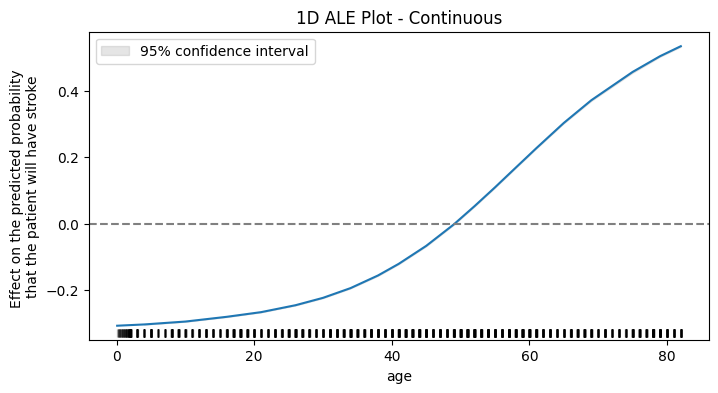

PyALE._ALE_generic:INFO: Continuous feature detected.


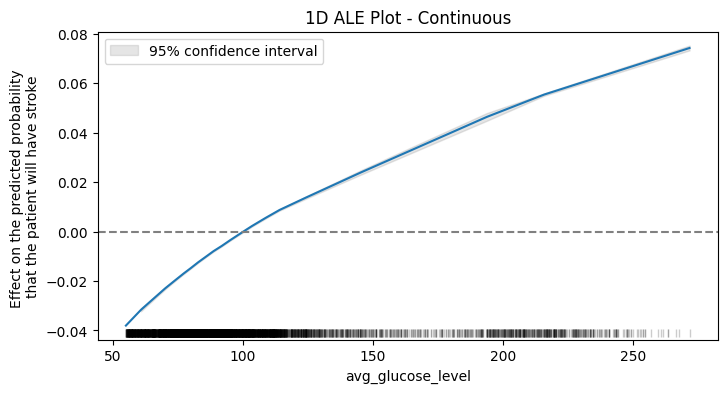

PyALE._ALE_generic:INFO: Continuous feature detected.


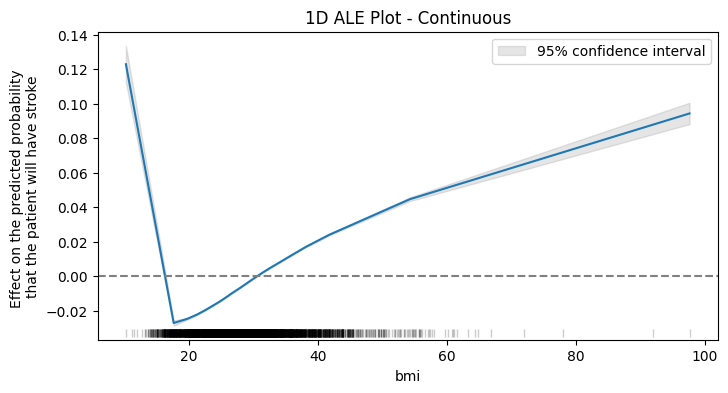

In [ ]:
class PredictProba():
    def predict(df):
        """
        - The predict(df) method takes a DataFrame of features and returns predicted probabilities for the positive class (stroke) using the tuned logistic regression model (lr_1).
        - Probabilities are clipped to avoid extreme values (between 1e-9 and 1-1e-9).
        This wrapper allows PyALE to call .predict() on the class for ALE plot computation.
        """
        p = lr_1.predict_proba(df)[:, 1]
        p = np.clip(p, 1e-9, 1 - 1e-9)
        return p


for col in numerical_cols:
    feat_eff = PyALE.ale(X=X_train, model=PredictProba, feature=[col], grid_size=20, C=0.95, include_CI=True)
    plt.axhline(0, color='gray', linestyle='--')  # Reference line for no effect
    plt.ylabel('Effect on the predicted probability \nthat the patient will have stroke')
    plt.show()

- **Age:** Strong, nonlinear positive effect—stroke risk rises sharply with age, especially after 40.
- **Avg Glucose Level:** Higher glucose steadily increases stroke probability.
- **BMI:** Very low BMI slightly lowers risk; higher BMI increases stroke risk, effect grows with BMI.
- **Overall:** All three predictors show monotonic, clinically plausible effects on stroke probability. Age is most influential.

Based on pattern developed in ALE plots, **polynomial terms** or **spline transformations** might better capture the effects of individual numerical predictors for outcome classes.


Analysis of Tuned Logistic Regression model's weights to quantify effect on predictions:

In [163]:
show_model_weights(X_train, lr_1)

Weight?,Feature
+6.691,cat__Residence_type
+5.918,cat__hypertension
+3.832,cat__smoking_status
+2.521,cat__heart_disease
+1.843,num__age
+0.176,log_num__avg_glucose_level
+0.119,log_num__bmi
-1.395,<BIAS>
-2.898,cat__gender
-3.032,cat__ever_married


The **Eli5** package generated weight summary table above lists the coefficients ("weights") from the tuned logistic regression model for predicting stroke (y=1). Positive weights indicate features that increase the probability of stroke, while negative weights decrease it.

*Interpretation:*
- Features with large positive weights are strong risk factors for stroke.
- Negative weights suggest lower risk groups.
- The magnitude reflects the relative influence of each predictor, but actual impact depends on feature engineering.
- These results align with clinical knowledge: hypertension, heart disease, smoking, and age are well-known stroke risk factors.

**Top Positive Contributors:**
- **Residence_type (+6.691):** Urban/rural residence has a strong positive effect, suggesting substantial association with stroke risk.
- **Hypertension (+5.918):** Hypertension is a major risk factor, strongly increasing stroke probability.
- **Smoking_status (+3.832):** Smoking history is a significant contributor to stroke risk.
- **Heart_disease (+2.521):** Presence of heart disease increases stroke risk.
- **Age (+1.843):** Older age is associated with higher stroke probability.
- **Avg_glucose_level (+0.176), BMI (+0.119):** Both show small positive effects, consistent with clinical expectations.

**Negative Contributors:**
- **Gender (−2.898):** Indicates lower stroke risk for one gender.
- **Ever_married (−3.032):** Being ever married is associated with lower stroke risk.
- **Work_type (−8.950):** Certain work types are strongly associated with lower stroke risk.

To verify weights, **permutation importance** quantifies how much each feature contributes to model performance by measuring the drop in accuracy or precision when its values are randomly shuffled. This method provides an intuitive, model-agnostic ranking of feature relevance, helping identify which predictors most influence stroke risk in our dataset.

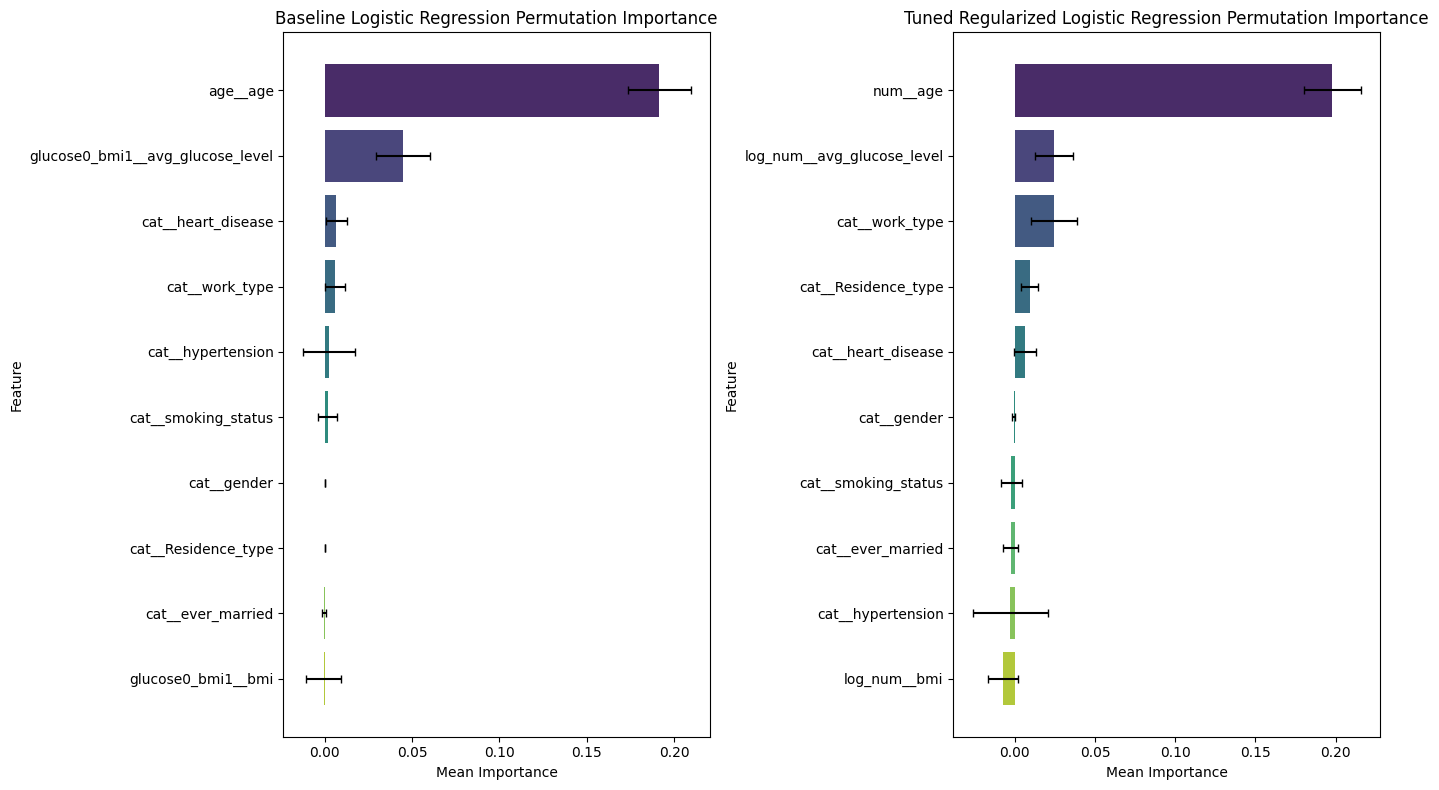

In [116]:
df_perm_lr = calculate_permutation_importance(baseline_logreg_model, X_train, y_train, X_test, y_test)
df_perm_lr2 = calculate_permutation_importance(lr_1, X_train, y_train, X_test, y_test)
plot_perm_importance(
    df_perm_lr,
    df_perm_lr2,
    name1='Baseline Logistic Regression',
    name2='Tuned Regularized Logistic Regression')

- **Age** is by far the most important predictor for stroke risk in both baseline and tuned logistic regression models.
- **Avg_glucose_level** and **work_type** are the next most influential features, but their impact is much smaller than age.
- Other predictors (**heart disease**, **residence type**, **hypertension**, **smoking status**, **gender**, **ever married**, **BMI**) contribute less to model performance.
- Tuning and regularization do not change the ranking: age remains dominant, with glucose and work type consistently important.
- Most categorical features have low importance, indicating limited predictive value compared to age and glucose.

To further make findings more robust, **interpret** package has a built-in classifier `ExplainableBoostingClassifier` that quantifies which predictors best explain outcome results:

In [ ]:
ebm = ExplainableBoostingClassifier(interactions=10, random_state=RANDOM_STATE)
# Convert y_train to integer numpy array if categorical
y_train_ebm = y_train.cat.codes if hasattr(y_train, "cat") else y_train
ebm.fit(X_train, y_train_ebm)
# Explain
ebm_global = ebm.explain_global()
show(ebm_global)  # interactive plots in Jupyter

c:\Users\matas\AppData\Roaming\pypoetry\venv\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:869: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


<!-- http://127.0.0.1:7001/2859206287120/ -->

- **Age** still remains the most important predictor for stroke risk, dominating the model's global feature importance.
- **Interactions** such as age & BMI, age & avg_glucose_level, and gender & age also contribute, but much less than age alone.
- **Avg_glucose_level**, **BMI**, and categorical other features have smaller but non-negligible effects.
- Most other features and interactions have relatively low importance, confirming that **age** is the primary driver of stroke prediction in this dataset.

Create **multivariate** scatter plots of most informative features to analyse potential patterns:

<Axes: xlabel='age', ylabel='gender'>

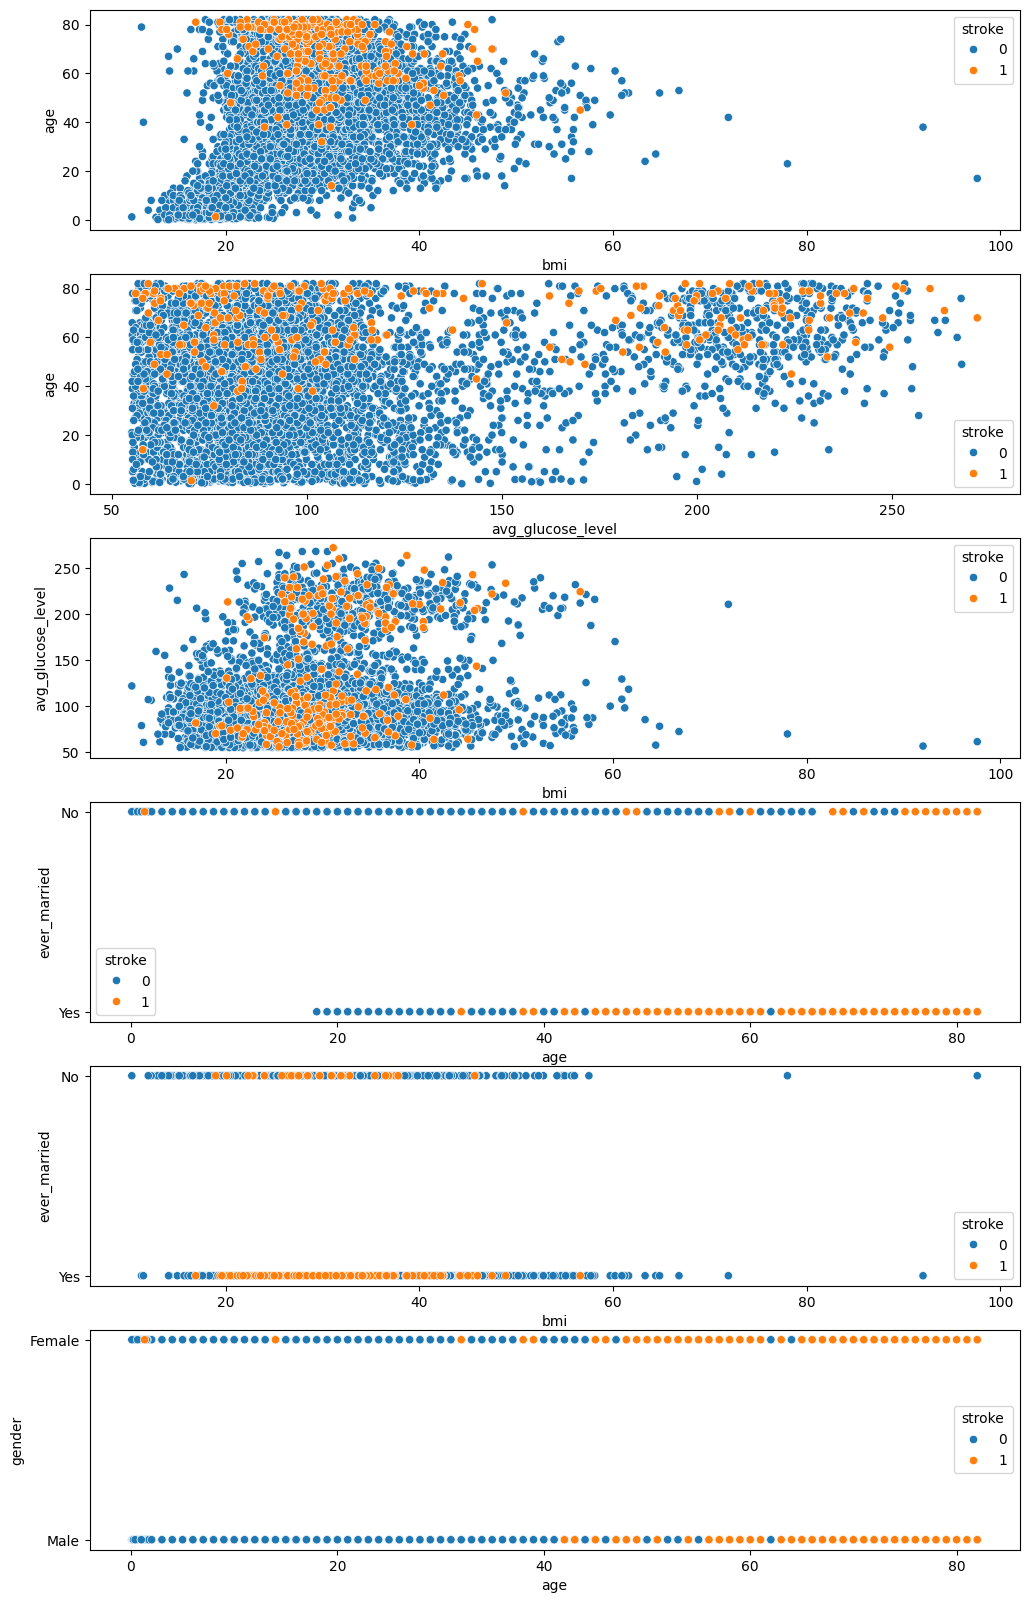

In [ ]:
fig, ax = plt.subplots(6, 1, figsize=(12, 20))
df_imp_sorted = df_imp.sort_values(by='stroke')
axes = ax.flatten()
sns.scatterplot(x=np.expm1(df_imp_sorted['bmi']), y=df_imp_sorted['age'], hue=df_imp_sorted['stroke'], ax=axes[0])
sns.scatterplot(
    x=np.expm1(
        df_imp_sorted['avg_glucose_level']),
    y=df_imp_sorted['age'],
    hue=df_imp_sorted['stroke'],
    ax=axes[1])
sns.scatterplot(
    x=np.expm1(
        df_imp_sorted['bmi']),
    y=np.expm1(
        df_imp_sorted['avg_glucose_level']),
    hue=df_imp_sorted['stroke'],
    ax=axes[2])
sns.scatterplot(x=df_imp_sorted['age'], y=df_imp_sorted['ever_married'], hue=df_imp_sorted['stroke'], ax=axes[3])
sns.scatterplot(
    x=np.expm1(
        df_imp_sorted['bmi']),
    y=df_imp_sorted['ever_married'],
    hue=df_imp_sorted['stroke'],
    ax=axes[4])
sns.scatterplot(x=df_imp_sorted['age'], y=df_imp_sorted['gender'], hue=df_imp_sorted['stroke'], ax=axes[5])

Across all panels, stroke cases (orange) are concentrated at higher ages, confirming age as the dominant risk factor. In the age vs. BMI and age vs. avg_glucose_level plots, stroke cases cluster at older ages and higher BMI or glucose levels, though the separation is less distinct than for age alone. The BMI vs. avg_glucose_level plot shows some overlap, but stroke cases tend to have higher values for both.

Categorical plots (ever_married, gender) reveal that stroke cases are more frequent among those who are ever married and among older individuals, reflecting, again, the age effect. Gender differences are minimal, with stroke cases distributed similarly across male and female groups.

Overall, the visualizations reinforce that **age** is the primary driver of stroke risk, with BMI and avg_glucose_level contributing moderately. Categorical features show weaker associations, and most stroke cases are found in older, higher-risk groups.

Outcome classes are noticeably **overlapping** with each other in all predictors but age, as well as **highly imbalanced**, meaning **resampling** and/or **balancing** techniques need to be considered to create a more obvious separation for model to achieve improved metrics, such as:

- **SMOTE** and it's alternatives;

- Parameters such as **class_weight**, **scale_pos_weight** tuning giving more weight to minority classes for cost-sensitive learning;

- **Balanced subsampling** techniques such as bootstrapping for minority class for classifiers represent both classes equally during training.

First, synthetic data point creation with **SMOTE** variants are tuned to see which technique generates most improvement: **SMOTEENN**(SMOTE + Edited Nearest Neighbours), **SMOTETomek** (SMOTE + Tomek link cleaning), **BorderlineSMOTE** (SMOTE technique applied to borderline classification cases for cleaner separation):


In [ ]:
# Create numeric imputer
num_imp = Pipeline([
    ('imp', IterativeImputer(
        estimator=RandomForestRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
            criterion='squared_error',
            max_depth=8, min_samples_split=20, min_samples_leaf=10),
        sample_posterior=False, max_iter=10, random_state=RANDOM_STATE, skip_complete=True))
])

# Pipelines per numeric (non-log) group: impute -> scale
num_pipeline = Pipeline([
    ('imp', num_imp),
    ('scale', StandardScaler().set_output(transform='pandas'))
])

# Pipelines per numeric (log) group: impute -> log -> scale
log_pipeline = Pipeline([
    ('imp', num_imp),
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scale', StandardScaler().set_output(transform='pandas'))
])

# Preprocessing pipeline before SMOTE
pre_smote = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, _num_cols_no_log),
        ('log_num', log_pipeline, _log_cols),
        ('cat', Pipeline(steps=[
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('te', TargetEncoder(smoothing=0.3, handle_missing='value', min_samples_leaf=20)),
            ('scale', StandardScaler().set_output(transform='pandas'))
        ]), categorical_cols),
    ],
    remainder='drop'
).set_output(transform='pandas')

# Parameter options for testing
samplers_to_test = {
    'smote_tomek': {
        'sampler': SMOTETomek(random_state=42),
        'params': {
            'sampler__sampling_strategy': [0.3, 0.5, 0.8, 'auto'],
            'sampler__n_jobs': [-1]
        }
    },

    'smote_enn': {
        'sampler': SMOTEENN(random_state=42),
        'params': {
            'sampler__sampling_strategy': [0.5, 0.6, 0.7, 0.8, 'auto'],
        }
    },

    'borderline_smote': {
        'sampler': BorderlineSMOTE(random_state=42),
        'params': {
            'sampler__k_neighbors': randint(3, 9),
            'sampler__m_neighbors': randint(5, 15),
            'sampler__kind': ['borderline-1', 'borderline-2'],
            'sampler__sampling_strategy': [0.5, 0.8, 'auto']
        }
    }
}

# Store results
best_results = {}

# Loop through sampler options
for name, config in samplers_to_test.items():
    print(f"\nTuning {name}...")

    SMOTE_lr = ImbPipeline(steps=[
        ('pre_smote', pre_smote),
        ('sampler', config['sampler']),
        ('lr', LogisticRegression(penalty='elasticnet', solver='saga',
                                  random_state=RANDOM_STATE, max_iter=2500))
    ])

    # Combine sampler params with logistic params
    param_grid = {
        **config['params'],
        'lr__C': loguniform(1e-4, 1e4),
        'lr__l1_ratio': uniform(0.0, 1.0),
        'lr__class_weight': ['balanced', None]
    }

    search = RandomizedSearchCV(
        SMOTE_lr, param_grid, n_iter=300, cv=cv,
        scoring='average_precision', random_state=42, n_jobs=-1
    )

    search.fit(X_train, y_train)
    best_results[name] = {
        'score': search.best_score_,
        'params': search.best_params_,
        'estimator': search.best_estimator_
    }

    print(f"{name} best score: {search.best_score_:.4f}")

# Find overall best
best_sampler = max(best_results.keys(), key=lambda k: best_results[k]['score'])
print(f"\nOverall best sampler: {best_sampler}")
print(f"Best score: {best_results[best_sampler]['score']:.4f}")


Tuning smote_tomek...
smote_tomek best score: 0.1975

Tuning smote_enn...
smote_enn best score: 0.1984

Tuning borderline_smote...
borderline_smote best score: 0.1957

Overall best sampler: smote_enn
Best score: 0.1984


- **SMOTEENN** yielded the highest average precision (0.1984), outperforming SMOTETomek (0.1975) and BorderlineSMOTE (0.1957). 

Verify with Cross-Validation (CV):

In [44]:
lr_1_smote = best_results['borderline_smote']['estimator']
print("REGULARIZED LR MODEL: ")
cross_val_results(lr_1, X_train, y_train, cv, 'precision', 'average_precision', 'recall', 'f1', 'roc_auc')
print("=" * 50)
print("REGULARIZED LR MODEL WITH SMOTE: ")
cross_val_results(lr_1_smote, X_train, y_train, cv, 'precision', 'average_precision', 'recall', 'f1', 'roc_auc')

REGULARIZED LR MODEL: 
Performing cross-validation with 5 folds...
Mean Train precision score: 0.134528843226794 +- 0.0033694269211991417
Mean Train average_precision score: 0.18781337528970257 +- 0.010693332394121595
Mean Train recall score: 0.8102908805031447 +- 0.007579219814696335
Mean Train f1 score: 0.23073261823300634 +- 0.00508825246973529
Mean Train roc_auc score: 0.8462644928986311 +- 0.003614158674625637
------------------------------------------------------------
Mean Test precision score: 0.13324084930091734 +- 0.00782963671932116
Mean Test average_precision score: 0.19505279789877253 +- 0.032711733725390414
Mean Test recall score: 0.798974358974359 +- 0.01594389406807231
Mean Test f1 score: 0.22834601282089184 +- 0.012101602402931268
Mean Test roc_auc score: 0.8388635087671077 +- 0.011282024868978878
------------------------------------------------------------
REGULARIZED LR MODEL WITH SMOTE: 
Performing cross-validation with 5 folds...
Mean Train precision score: 0.17016

**Regularized Logistic Regression vs. Regularized LR with SMOTEENN**

- **Precision:** SMOTEENN increases precision (0.165 vs. 0.133), indicating fewer false positives.
- **Recall:** Regularized LR achieves higher recall (0.799 vs. 0.593), meaning it identifies more stroke cases.
- **F1 Score:** SMOTEENN improves F1 (0.258 vs. 0.228), balancing precision and recall better.
- **Average Precision & ROC AUC:** Both models perform similarly (AP ≈ 0.195, ROC AUC ≈ 0.84).
- **Interpretation:** SMOTEENN improves precision and F1 but reduces recall, suggesting better balance but fewer detected stroke cases. Regularized LR alone is more sensitive, while SMOTEENN is more conservative. Precision/Recall curves might generate more insights on model performances based on classification thresholds.


In [164]:
show_model_weights(X_train, lr_1_smote)

Weight?,Feature
+2.075,num__age
+0.244,log_num__avg_glucose_level
+0.194,cat__smoking_status
+0.178,cat__hypertension
+0.141,cat__heart_disease
+0.049,log_num__bmi
+0.014,cat__Residence_type
+0.012,cat__gender
-0.088,cat__ever_married
-0.200,cat__work_type


**Eli5 Feature Weights (Regularized Logistic Regression + SMOTEENN):**

- **Age** (`num__age`): Strongest positive contributor to stroke risk (+2.075).
- **Avg_glucose_level** (`log_num__avg_glucose_level`): Moderate positive effect (+0.244).
- **Smoking_status**, **Hypertension**, **Heart_disease**: All positively associated with stroke, but with smaller weights (+0.194, +0.178, +0.141).
- **BMI** (`log_num__bmi`): Slight positive effect (+0.049).
- **Residence_type**, **Gender**: Minimal positive influence (+0.014, +0.012).
- **Ever_married**, **Work_type**: Negative weights, indicating lower stroke risk for these groups (−0.088, −0.200).
- **Intercept** (`<BIAS>`): Large negative value (−2.257), reflecting overall class imbalance.

**Interpretation:**  
Age remains the dominant risk factor. Glucose, smoking, hypertension, and heart disease contribute moderately. Categorical features and BMI have smaller effects. Negative weights for marital status and work type.


In [ ]:
"""
- Added SplineTransformer for age, bmi, and glucose features to preprocessing pipeline
- Re-running model training and parameter evaluation
"""

# simple imputer to use before spline (SplineTransformer cannot accept empty values)
spline_imputer = SimpleImputer(strategy='median')

# build ColumnTransformer that has separate pipelines for each spline column
pre_smote_spline = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, _num_cols_no_log),
        ('log_num', log_pipeline, _log_cols),
        ('cat', Pipeline([
            ('te', TargetEncoder(smoothing=0.3, handle_missing='value', min_samples_leaf=20)),
            ('scale', StandardScaler().set_output(transform='pandas'))
        ]), categorical_cols),
        ('age_spline', Pipeline([
            ('imp', spline_imputer),
            ('spline', SplineTransformer(include_bias=False)),
            ('scale', StandardScaler().set_output(transform='pandas'))
        ]), ['age']),
        ('bmi_spline', Pipeline([
            ('imp', spline_imputer),
            ('spline', SplineTransformer(include_bias=False)),
            ('scale', StandardScaler().set_output(transform='pandas'))
        ]), ['bmi']),
        ('glucose_spline', Pipeline([
            ('imp', spline_imputer),
            ('spline', SplineTransformer(include_bias=False)),
            ('scale', StandardScaler().set_output(transform='pandas'))
        ]), ['avg_glucose_level']),  # change name here if your column is different
    ],
    remainder=SimpleImputer(strategy='most_frequent')
).set_output(transform='pandas')


# sampler configurations for testing
samplers_to_test_spline = {
    'smote_tomek': {
        'sampler': SMOTETomek(random_state=42),
        'params': {
            'pre_smote__age_spline__spline__degree': [2, 3],
            'pre_smote__age_spline__spline__n_knots': [4, 5, 6],
            'pre_smote__age_spline__spline__knots': ['quantile'],

            'pre_smote__bmi_spline__spline__degree': [2, 3, 4],
            'pre_smote__bmi_spline__spline__n_knots': [4, 5, 6],
            'pre_smote__bmi_spline__spline__knots': ['uniform', 'quantile'],

            'pre_smote__glucose_spline__spline__degree': [2, 3, 4],
            'pre_smote__glucose_spline__spline__n_knots': [4, 5, 6],
            'pre_smote__glucose_spline__spline__knots': ['quantile', 'uniform'],

            'sampler__sampling_strategy': [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 'auto'],
            'sampler__n_jobs': [-1]
        }
    },
    'smote_smoteenn': {
        'sampler': SMOTEENN(random_state=42),
        'params': {
            'pre_smote__age_spline__spline__degree': [2, 3],
            'pre_smote__age_spline__spline__n_knots': [4, 5, 6],
            'pre_smote__age_spline__spline__knots': ['quantile'],

            'pre_smote__bmi_spline__spline__degree': [2, 3, 4],
            'pre_smote__bmi_spline__spline__n_knots': [4, 5, 6],
            'pre_smote__bmi_spline__spline__knots': ['uniform', 'quantile'],

            'pre_smote__glucose_spline__spline__degree': [2, 3, 4],
            'pre_smote__glucose_spline__spline__n_knots': [4, 5, 6],
            'pre_smote__glucose_spline__spline__knots': ['quantile', 'uniform'],

            'sampler__sampling_strategy': [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 'auto'],
            'sampler__n_jobs': [-1]
        }
    },
    'smote_borderline': {
        'sampler': BorderlineSMOTE(random_state=42),
        'params': {
            'pre_smote__age_spline__spline__degree': [2, 3],
            'pre_smote__age_spline__spline__n_knots': [4, 5, 6],
            'pre_smote__age_spline__spline__knots': ['quantile'],

            'pre_smote__bmi_spline__spline__degree': [2, 3, 4],
            'pre_smote__bmi_spline__spline__n_knots': [4, 5, 6],
            'pre_smote__bmi_spline__spline__knots': ['uniform', 'quantile'],

            'pre_smote__glucose_spline__spline__degree': [2, 3, 4],
            'pre_smote__glucose_spline__spline__n_knots': [4, 5, 6],
            'pre_smote__glucose_spline__spline__knots': ['quantile', 'uniform'],

            'sampler__k_neighbors': randint(3, 7),
            'sampler__m_neighbors': randint(5, 15),
            'sampler__sampling_strategy': [0.3, 0.5, 0.8, 'auto'],
            'sampler__kind': ['borderline-1', 'borderline-2'],
        }
    },
}

spline_results = {}

for name, cfg in samplers_to_test_spline.items():
    print(f"\nTuning {name}...")

    param_dist = {
        **cfg['params'],
        'lr__C': loguniform(1e-4, 1e4),
        'lr__l1_ratio': uniform(0.0, 1.0),
        'lr__class_weight': ['balanced', None],
        'selector__k': randint(10, 30)
    }

    pipe = ImbPipeline(steps=[
        ('pre_smote', pre_smote_spline),
        ('sampler', cfg['sampler']),
        ('selector', SelectKBest(score_func=mutual_info_classif)),
        ('lr', LogisticRegression(penalty='elasticnet', solver='saga',
                                  random_state=RANDOM_STATE, max_iter=2500))
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=300,
        cv=cv,
        scoring='average_precision',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)
    print(f"Best score for {name}: {search.best_score_:.4f}")
    spline_results[name] = {'score': search.best_score_,
                            'params': search.best_params_,
                            'estimator': search.best_estimator_}

# inspect best overall
best = max(spline_results.keys(), key=lambda k: spline_results[k]['score'])
print("Best sampler with splines:", best)


Tuning smote_tomek...
Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best score for smote_tomek: 0.2052

Tuning smote_smoteenn...
Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best score for smote_smoteenn: 0.2076

Tuning smote_borderline...
Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best score for smote_borderline: 0.2061
Best sampler with splines: smote_smoteenn


*- Applying spline transformations to age, BMI, and avg_glucose_level improved model performance across all SMOTE variants.
- **SMOTEENN with splines** achieved the highest average precision (0.2076), outperforming SMOTETomek (0.2052) and BorderlineSMOTE (0.2061).
- Spline features should allow the model to capture nonlinear effects of key numerical predictors, leading to better discrimination of stroke cases.

Verify behaviour with CV:


In [179]:
lr_2_spline = spline_results[best]['estimator']
print("REGULARIZED LR MODEL WITH SMOTE: ")
cross_val_results(lr_1_smote, X_train, y_train, cv, 'precision', 'average_precision', 'recall', 'f1', 'roc_auc')
print("=" * 50)
print("REGULARIZED LR MODEL WITH SMOTE/SPLINES: ")
cross_val_results(lr_2_spline, X_train, y_train, cv, 'precision', 'average_precision', 'recall', 'f1', 'roc_auc')

REGULARIZED LR MODEL WITH SMOTE: 
Performing cross-validation with 5 folds...
Mean Train precision score: 0.17016425580188516 +- 0.004851395244114964
Mean Train average_precision score: 0.18850683997260545 +- 0.010522544028600667
Mean Train recall score: 0.6168632075471698 +- 0.021582873496940873
Mean Train f1 score: 0.26670986797214 +- 0.007385060216180249
Mean Train roc_auc score: 0.8457594846954419 +- 0.0030269405868664197
------------------------------------------------------------
Mean Test precision score: 0.1647359603096915 +- 0.0186529849771159
Mean Test average_precision score: 0.195716225249118 +- 0.033773896764790166
Mean Test recall score: 0.592948717948718 +- 0.03995395114006658
Mean Test f1 score: 0.2576787441494305 +- 0.02615515749036829
Mean Test roc_auc score: 0.8360546380019389 +- 0.008933999693852272
------------------------------------------------------------
REGULARIZED LR MODEL WITH SMOTE/SPLINES: 
Performing cross-validation with 5 folds...
Mean Train precision s

- **Regularized Logistic Regression with SMOTE:**  
    - Achieves moderate precision (0.165) and average precision (0.196) on test data.
    - Recall is lower (0.593), indicating fewer stroke cases are detected, but F1 score (0.258) and ROC AUC (0.836) show balanced performance. Threshold tuning likely beneficial, as mentioned.
    - Model is more conservative, favoring precision over recall.

- **Regularized Logistic Regression with SMOTE + Splines:**  
    - Precision decreases (0.117), but recall increases substantially (0.874), meaning more stroke cases are identified.
    - Average precision improves to 0.208, and ROC AUC remains stable (0.834).
    - Spline transformations allow the model to capture nonlinear effects, especially for age, BMI, and glucose.

- **Overall:**  
    - Adding spline features improves recall and average precision, confirming the importance of modeling nonlinear relationships.
    - SMOTE-based resampling helps balance the dataset, but trade-offs exist between precision and recall.
    - Age remains the most influential predictor, with BMI and glucose contributing moderately.
    - Feature engineering and resampling are critical for improving stroke prediction in imbalanced datasets.


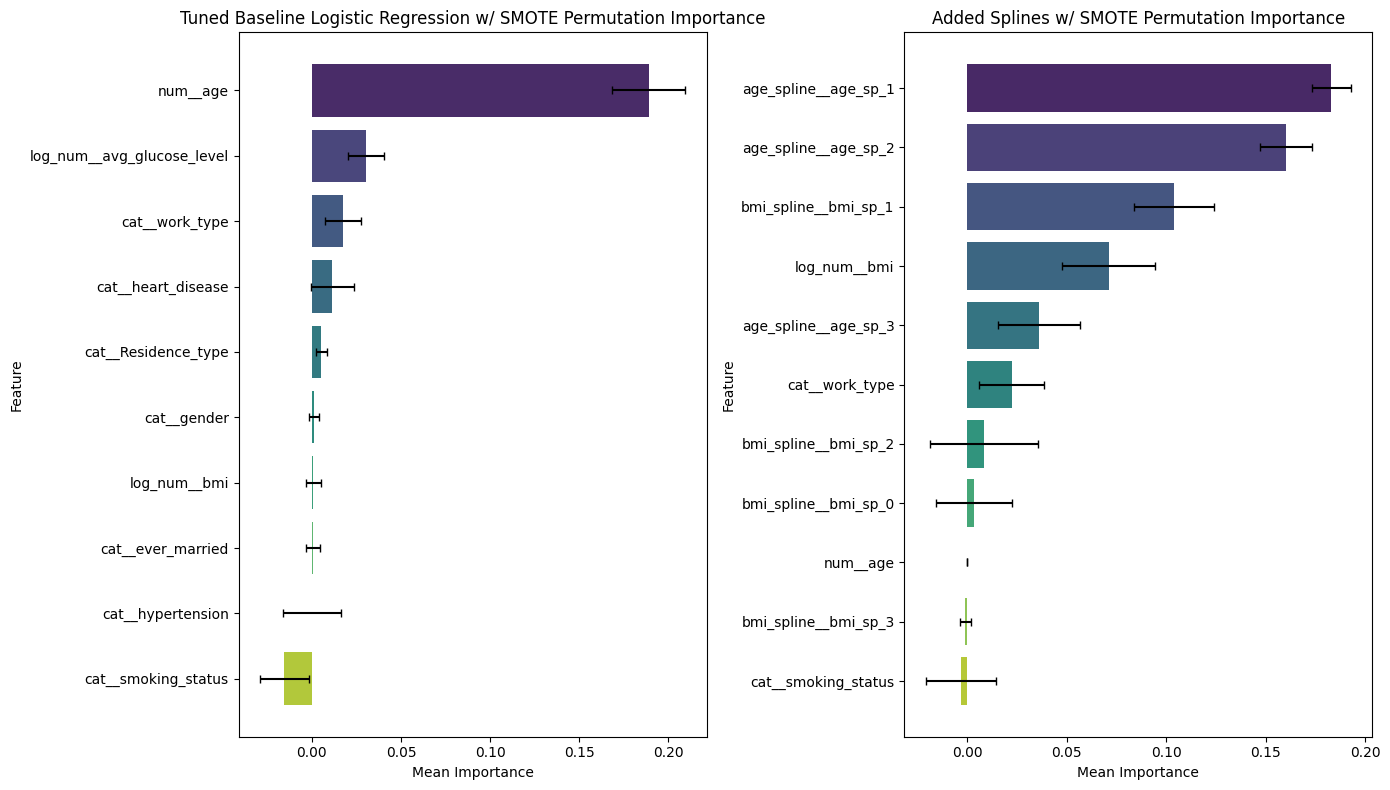

In [115]:
df_smote = calculate_permutation_importance(lr_1_smote, X_train, y_train, X_test, y_test)
df_spline = calculate_permutation_importance(lr_2_spline, X_train, y_train, X_test, y_test)
plot_perm_importance(
    df_smote,
    df_spline,
    name1='Tuned Baseline Logistic Regression w/ SMOTE',
    name2='Added Splines w/ SMOTE')

- **Baseline SMOTE model:** Relies heavily on age, with other predictors having minor roles.
- **SMOTE + Splines model:** Importance is spread across multiple spline features, especially age and BMI, indicating better modeling of nonlinear relationships.
- **Conclusion:** Adding splines with SMOTE improves feature representation and model discrimination, especially for complex effects, leading to higher recall and average precision.

In [178]:
show_model_weights(X_train, lr_2_spline)

Weight?,Feature
+1.092,bmi_spline__bmi_sp_1
+1.031,log_num__bmi
+0.355,bmi_spline__bmi_sp_2
+0.132,cat__smoking_status
+0.019,bmi_spline__bmi_sp_3
-0.139,cat__work_type
-0.485,bmi_spline__bmi_sp_0
-0.562,age_spline__age_sp_3
-1.326,age_spline__age_sp_2
-2.158,<BIAS>


- **Summary:**  
    - The top positive weights are for BMI-related spline features (`bmi_spline__bmi_sp_1`, `log_num__bmi`, `bmi_spline__bmi_sp_2`), indicating higher BMI increases stroke risk.
    - Smoking status also has a small positive effect.
    - Negative weights are seen for certain age and BMI spline components, work type, and the model bias term.

- **Explanation:**  
    - **Spline features** break a variable (like age or BMI) into several basis functions, each capturing a different part of its effect.  
    - **Negative spline weights** mean that, in some ranges, the feature reduces stroke risk, while positive weights mean it increases risk in other ranges.
    - The **overall effect** is the sum of all spline components. So, even if some spline weights are negative, the total effect can be positive if the positive components dominate (and vice versa).
    - This allows the model to capture **nonlinear relationships**—for example, risk may rise sharply after a certain age or BMI, but be flat or even decrease in other ranges. But the risk of overfitting increases as well, so we should proceed with caution.


PyALE._ALE_generic:INFO: Continuous feature detected.


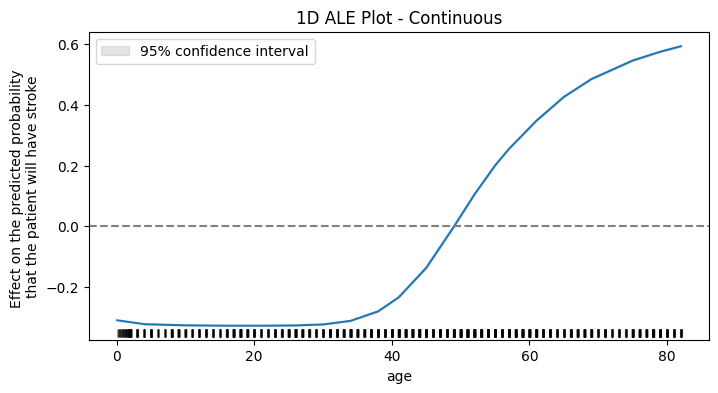

PyALE._ALE_generic:INFO: Continuous feature detected.


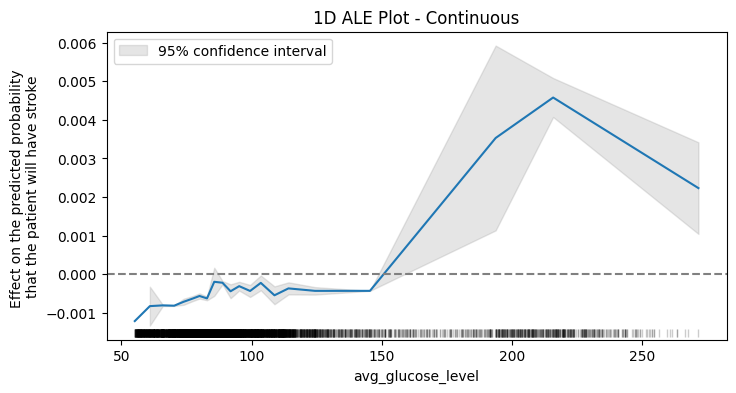

PyALE._ALE_generic:INFO: Continuous feature detected.


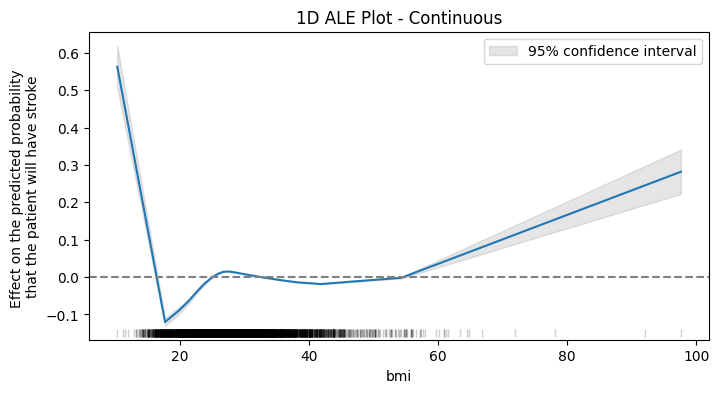

In [238]:
class PredictProba():
    def predict(df):
        p = lr_2_spline.predict_proba(df)[:, 1]
        p = np.clip(p, 1e-9, 1 - 1e-9)
        return p


for col in numerical_cols:
    feat_eff = PyALE.ale(X=X_train, model=PredictProba, feature=[col], grid_size=20, C=0.95, include_CI=True)
    plt.axhline(0, color='gray', linestyle='--')
    plt.ylabel('Effect on the predicted probability \nthat the patient will have stroke')
    plt.show()

Splines allow the model to flexibly capture nonlinear effects for each predictor. The total effect for each variable is the sum of its spline components. Age dominates stroke risk, while BMI and glucose have moderate, nonlinear impacts. But CI (95%) are wider than in simpler previous iteration of Logistic Regression, meaning interpretability of effects drops considerably.

Sanity check: manually calculate predictions by setting constant ages (in this instance: 30 and 50) to check whether weights displayed by **Eli5** displayed correct weights:

In [239]:
X_t = X_train.copy()
lr_2_spline.fit(X_t, y_train)
X_t['age'] = 30
age_30 = lr_2_spline.predict_proba(X_t)[:, 1].mean()
X_t['age'] = 50
age_50 = lr_2_spline.predict_proba(X_t)[:, 1].mean()
print('Manual calculated prediction difference:', age_50 - age_30)

Manual calculated prediction difference: 0.3281269776702032


In [47]:
print("Classification Report for LR with SMOTE:")
print(classification_report(y_test, lr_1_smote.predict(X_test), target_names=['No Stroke', 'Stroke']))

print("Classification Report for LR with SMOTE/SPLINES:")
print(classification_report(y_test, lr_2_spline.predict(X_test), target_names=['No Stroke', 'Stroke']))

Classification Report for LR with SMOTE:
              precision    recall  f1-score   support

   No Stroke       0.98      0.84      0.91       972
      Stroke       0.20      0.74      0.31        50

    accuracy                           0.84      1022
   macro avg       0.59      0.79      0.61      1022
weighted avg       0.95      0.84      0.88      1022

Classification Report for LR with SMOTE/SPLINES:
              precision    recall  f1-score   support

   No Stroke       0.99      0.68      0.81       972
      Stroke       0.12      0.84      0.21        50

    accuracy                           0.69      1022
   macro avg       0.55      0.76      0.51      1022
weighted avg       0.95      0.69      0.78      1022



Decision: proceed with **SMOTE** applied baseline logistic regression model:

- More stable permutation importances; with added interactions - even more potential instability;

- Higher f1, precision;

- The splines model has slightly higher average precision (0.208 vs 0.196) but this difference is within the error margins.


## Interactions

### ALE 2D

Plot continuous variable ALE 2D plots to investigate potential interaction terms:

bmi,10.3,17.7,19.8,21.3,22.7,23.8,24.8,25.8,26.7,27.6,...,28.5,29.5,30.5,31.6,32.8,34.3,36.2,38.8,42.6,97.6
avg_glucose_level,,,,,,,,,,,,,,,,,,,,,
55.12,0.000799,0.000644,0.000586,0.000510,0.000434,0.000369,0.000311,0.000244,0.000170,0.000117,...,0.000054,-0.000033,-0.000125,-0.000226,-0.000323,-0.000417,-0.000563,-0.000806,-1.158163e-03,-0.004523
60.91,0.000705,0.000534,0.000485,0.000420,0.000342,0.000289,0.000250,0.000188,0.000125,0.000087,...,0.000033,-0.000030,-0.000101,-0.000184,-0.000263,-0.000342,-0.000493,-0.000693,-9.782691e-04,-0.003814
65.87,0.000574,0.000443,0.000413,0.000348,0.000291,0.000244,0.000215,0.000159,0.000111,0.000078,...,0.000032,-0.000022,-0.000073,-0.000135,-0.000195,-0.000254,-0.000372,-0.000535,-7.819886e-04,-0.003651
70.25,0.000433,0.000348,0.000327,0.000282,0.000236,0.000199,0.000172,0.000121,0.000081,0.000052,...,0.000013,-0.000028,-0.000070,-0.000116,-0.000170,-0.000213,-0.000317,-0.000447,-6.524831e-04,-0.003227
73.92,0.000343,0.000296,0.000274,0.000245,0.000208,0.000175,0.000149,0.000105,0.000070,0.000044,...,0.000010,-0.000032,-0.000070,-0.000112,-0.000164,-0.000203,-0.000290,-0.000408,-5.933058e-04,-0.002845
77.29,0.000284,0.000247,0.000221,0.000201,0.000172,0.000141,0.000121,0.000081,0.000051,0.000031,...,0.000002,-0.000031,-0.000063,-0.000095,-0.000141,-0.000170,-0.000245,-0.000344,-5.064171e-04,-0.002549
80.00,0.000231,0.000215,0.000190,0.000173,0.000148,0.000119,0.000096,0.000064,0.000036,0.000015,...,-0.000009,-0.000039,-0.000067,-0.000090,-0.000130,-0.000155,-0.000222,-0.000304,-4.495288e-04,-0.002300
82.88,0.000173,0.000165,0.000142,0.000130,0.000112,0.000085,0.000067,0.000041,0.000020,0.000007,...,-0.000012,-0.000037,-0.000062,-0.000080,-0.000114,-0.000130,-0.000182,-0.000248,-3.676483e-04,-0.002028
85.66,0.000119,0.000119,0.000104,0.000099,0.000089,0.000067,0.000055,0.000030,0.000011,0.000002,...,-0.000015,-0.000039,-0.000056,-0.000069,-0.000095,-0.000105,-0.000141,-0.000192,-2.903885e-04,-0.001757


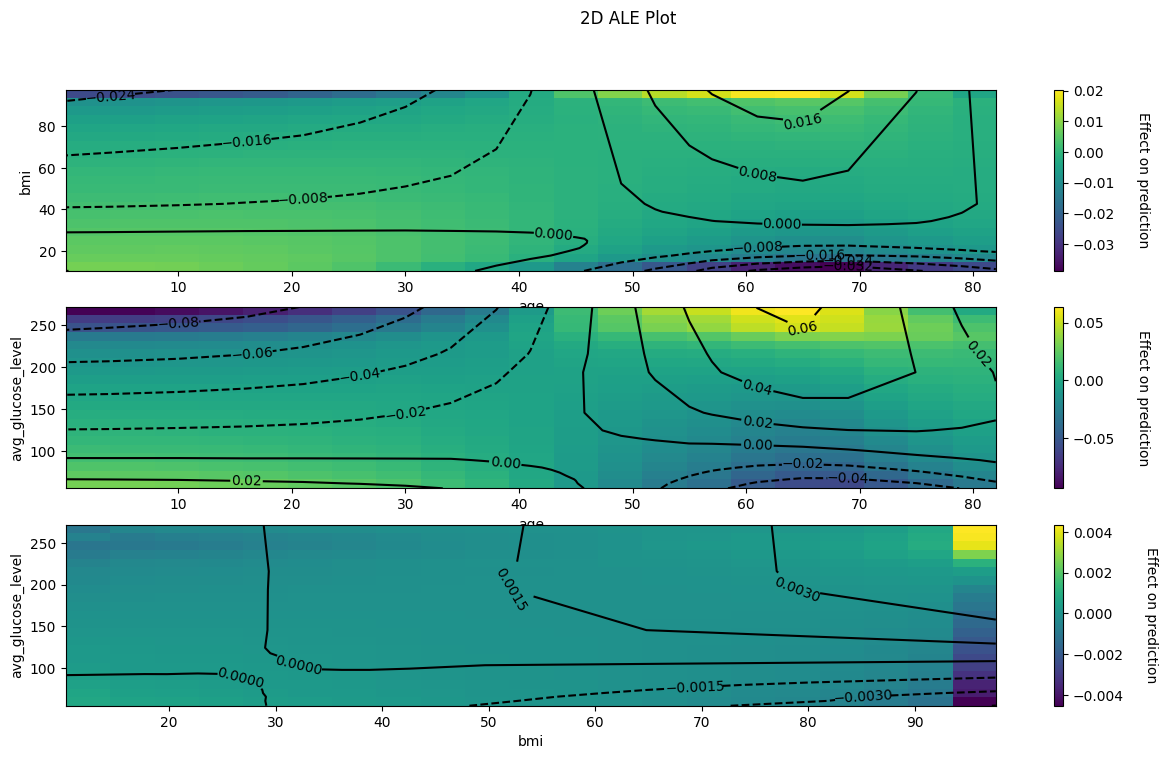

In [310]:
class PredictProba():
    def predict(df):
        p = lr_1_smote.predict_proba(df)[:, 1]
        p = np.clip(p, 1e-9, 1 - 1e-9)
        return p


fig, ax = plt.subplots(3, 1, figsize=(15, 8))

X_train_smote = X_train.copy()
X_train_smote['bmi'] = SimpleImputer(strategy='median').fit_transform(X_train_smote[['bmi']])

PyALE.ale(X=X_train_smote,
          model=PredictProba,
          feature=['bmi', 'age'],
          include_CI=True,
          grid_size=20,
          fig=fig,
          ax=ax[0],
          contour=True
          )
PyALE.ale(X=X_train_smote,
          model=PredictProba,
          feature=['avg_glucose_level', 'age'],
          include_CI=True,
          grid_size=20,
          ax=ax[1],
          fig=fig,
          contour=True
          )
PyALE.ale(X=X_train_smote,
          model=PredictProba,
          feature=['avg_glucose_level', 'bmi'],
          include_CI=True,
          grid_size=20,
          ax=ax[2],
          fig=fig,
          contour=True
          )

The 2D ALE plots reveal that age likely interacts with both BMI and glucose — older patients with high BMI or glucose have the greatest predicted stroke risk. The relationships are nonlinear and show that risk factors potentially compound each other.

### Principal Component Analysis

Principal Component Analysis (PCA) helps uncover hidden structure and interactions among predictors by reducing dimensionality and revealing combinations of features that explain the most variance in stroke risk. This can highlight correlated effects and simplify interpretation of complex relationships.

In [6]:
X_num = X_train.loc[:, numerical_cols]

X_scaled = pd.DataFrame(
    imp.fit_transform(X_num),
    columns=X_num.columns,
    index=X_num.index
)

X_scaled = X_scaled.apply(lambda x: (x - x.mean(axis=0)) / x.std(axis=0))
X_scaled.sort_index(inplace=True)

pca = PCA()
X_pca = pd.DataFrame(
    pca.fit_transform(X_scaled),
    columns=[f'PC{i + 1}' for i in range(X_scaled.shape[1])],
    index=X_scaled.index
)

component_names = [f"PC{i + 1}" for i in range(X_pca.shape[1])]

X_pca.head()

,PC1,PC2,PC3
0,2.593480,1.596227,-0.290147
1,2.035295,1.237783,-0.286301
2,1.281294,-0.590489,0.918454
3,1.289910,0.832012,-0.495703
4,1.359926,1.217399,1.343966


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,  # transpose the matrix of loadings
    columns=component_names,  # so the columns are the principal components
    index=X_scaled.columns,  # and the rows are the original features
)
loadings

,PC1,PC2,PC3
age,0.626712,-0.227177,0.745401
avg_glucose_level,0.501261,0.849917,-0.162415
bmi,0.596632,-0.475428,-0.646528


The table above shows the **PCA loadings** for the three principal components (PC1, PC2, PC3) derived from the numerical predictors: age, avg_glucose_level, and BMI.

- **PC1** has strong positive contributions from all three features, especially age and BMI. This component likely represents overall risk, with higher values indicating older age, higher glucose, and higher BMI.
- **PC2** is dominated by avg_glucose_level (positive loading), while BMI and age contribute negatively. This axis separates individuals with high glucose from those with higher age/BMI.
- **PC3** is most influenced by age (positive) and BMI (negative), suggesting an interaction where older age and lower BMI are contrasted.

**Interpretation:**  
- The first principal component (PC1) captures the general trend that stroke risk increases with age, glucose, and BMI.
- PC2 and PC3 reveal more nuanced relationships and interactions among these predictors, highlighting that glucose, age, and BMI do not act independently but combine in complex ways to influence stroke risk.
- PCA helps visualize and quantify these interactions, supporting further feature engineering and model interpretation.


### Principal Component Analysis (PCA) Findings

PCA was performed on the three main numerical predictors: **age**, **avg_glucose_level**, and **bmi**. The loadings table below shows how each variable contributes to the first three principal components:

|                | PC1      | PC2      | PC3      |
|----------------|----------|----------|----------|
| age            | 0.63     | -0.23    | 0.75     |
| avg_glucose_level | 0.50  | 0.85     | -0.16    |
| bmi            | 0.60     | -0.48    | -0.65    |

**Interpretation:**

- **PC1** is a weighted combination of all three variables, with similar positive contributions from age, avg_glucose_level, and bmi. This component can be interpreted as a **general health risk** axis, where higher values indicate older age, higher glucose, and higher BMI.
- **PC2** is dominated by avg_glucose_level (0.85), with bmi contributing negatively (-0.48) and age less so (-0.23). This axis separates individuals with **high glucose but lower BMI**.
- **PC3** is most strongly influenced by age (0.75, positive) and bmi (-0.65, negative), with avg_glucose_level contributing less. This component distinguishes **older individuals with lower BMI** from **younger individuals with higher BMI**. 

- A potential **ratio** ((`avg_glucose_lvl` / `bmi`) and (`age` / `bmi`)) could be meaningful interaction components based on PC findings.

**Summary:**  
PCA reveals that age, avg_glucose_level, and bmi are moderately correlated and together capture most of the variance in the data. The first principal component reflects overall health risk, while the second and third components highlight contrasts between glucose and BMI, and between age and BMI, respectively. These axes can be used for dimensionality reduction, visualization, input features or a guide for interaction terms for further modeling.


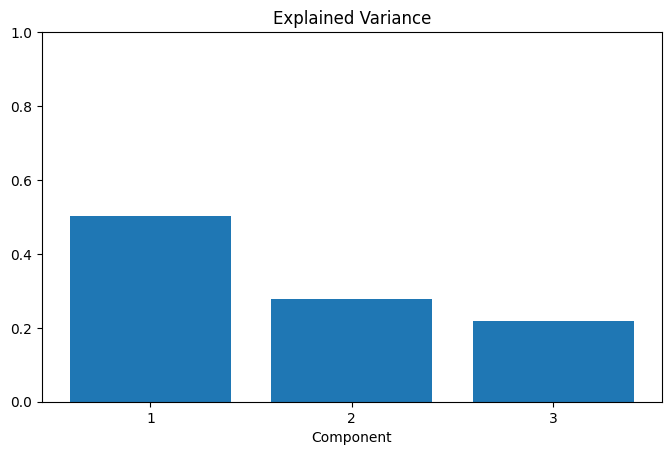

In [7]:
def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, ax = plt.subplots(1, 1)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    ax.bar(grid, evr)
    ax.set(
        xlabel="Component", title="Explained Variance", ylim=(0.0, 1.0),
        xticks=np.arange(1, n + 1, 1)
    )
    fig.set(figwidth=width, dpi=dpi)
    return ax


plot_variance(pca);

- **PC1** explains about 50% of the total variance in the data.
- **PC2** explains about 28%.
- **PC3** explains about 22%.
- Together, the first three components capture **100% of the variance** in the standardized predictors (**age**, **avg_glucose_level**, **BMI**), with PC1 being the most informative.
- Most of the information in these variables is summarized by the first component, and the next two add additional, but smaller, details.

Mutual Information (MI) scores measure the dependency between each feature and the target variable (stroke occurrence). A higher MI score indicates that the feature provides more information about the target and is more useful for prediction.

In the PCA context, MI scores for principal components (PCs) show how much each component helps distinguish stroke cases:


In [ ]:
def make_mi_scores(X, y):
    """
    Calculate mutual information scores for all features in X with respect to target y.

    Parameters:
        X (pd.DataFrame): Feature matrix.
        y (pd.Series or array-like): Target variable.

    Returns:
        pd.Series: Sorted mutual information scores for each feature.
    """
    mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=RANDOM_STATE)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


make_mi_scores(X_pca, y_train)

PC2    0.002930
PC1    0.001125
PC3    0.000800
Name: MI Scores, dtype: float64

- **PC2 (0.0029):** Contributes the most information about stroke risk among the three PCs, but the value is still very low.
- **PC1 (0.0011):** Provides some information, less than PC2.
- **PC3 (0.0008):** Has the least predictive power for stroke.

**Interpretation:**  
All MI scores are close to zero, indicating that, after dimensionality reduction, the principal components have weak individual associations with stroke. This suggests that the original features (age, avg_glucose_level, BMI) are only moderately informative for stroke prediction when combined linearly, and nonlinear or interaction effects may be more important.

Verify with Logistic Regression whether replacing original numerical variables with principal components increase scores:

In [ ]:
X_train_pca = X_train.copy()

X_train_pca = pd.get_dummies(X_train_pca, columns=categorical_cols, dtype=int, drop_first=True)

X_train_pca = pd.DataFrame(
    imp.fit_transform(X_train_pca),
    columns=X_train_pca.columns,
    index=X_train_pca.index
)

X_train_pca['bmi'] = np.log1p(X_train_pca['bmi'])
X_train_pca['avg_glucose_level'] = np.log1p(X_train_pca['avg_glucose_level'])
X_train_pca[numerical_cols] = StandardScaler().fit_transform(X_train_pca[numerical_cols])

other_features = X_train_pca.drop(columns=numerical_cols)

X_train_pca.sort_index(inplace=True)

X_train_pca['PC1'] = X_pca.loc[:, 'PC1']
X_train_pca['PC2'] = X_pca.loc[:, 'PC2']
X_train_pca['PC3'] = X_pca.loc[:, 'PC3']

cv_pca = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
clf = LogisticRegression(max_iter=2500, class_weight='balanced', random_state=RANDOM_STATE)
scores_orig = cross_val_score(
    clf,
    X_train_pca.drop(
        columns=[
            'PC1',
            'PC2',
            'PC3']),
    y_train,
    cv=cv_pca,
    scoring='precision')
scores_pc3 = cross_val_score(
    clf,
    X_train_pca.drop(
        columns=[
            'PC1',
            'PC2',
            'age',
            'bmi',
            'avg_glucose_level']),
    y_train,
    cv=cv_pca,
    scoring='precision')
scores_pc13 = cross_val_score(
    clf,
    X_train_pca.drop(
        columns=[
            'PC2',
            'age',
            'bmi',
            'avg_glucose_level']),
    y_train,
    cv=cv_pca,
    scoring='precision')
scores_pc123 = cross_val_score(
    clf,
    X_train_pca.drop(
        columns=[
            'age',
            'bmi',
            'avg_glucose_level']),
    y_train,
    cv=cv_pca,
    scoring='precision')

print("orig mean precision:", scores_orig.mean(), "+-", scores_orig.std())
print("PC3 mean precision: ", scores_pc3.mean(), "+-", scores_pc3.std())
print("PC1+PC3 mean precision:", scores_pc13.mean(), "+-", scores_pc13.std())
print("PC1+PC2+PC3 mean precision:", scores_pc123.mean(), "+-", scores_pc123.std())

orig mean precision: 0.04759123475416168 +- 0.006447428672434176
PC3 mean precision:  0.04524154144734003 +- 0.009832705971625732
PC1+PC3 mean precision: 0.04651926471498125 +- 0.007645892144211656
PC1+PC2+PC3 mean precision: 0.05039140659865034 +- 0.0047202050318516965


### Findings: Replacing Original Features with Principal Components

- **Precision scores with PCs are similar or slightly lower** than with the original features. For example, using all three PCs yields a mean precision of 0.050, compared to 0.048 with the original features.
- **Individual PCs (e.g., PC3 alone) perform worse** than the full set of original features, indicating that no single component captures all relevant information for stroke prediction.
- **Combining multiple PCs (PC1+PC2+PC3) slightly improves precision** over using only one or two PCs, but the gain is marginal.

**Interpretation:**  
Principal components summarize the variance in the data but may lose important nonlinear or interaction effects present in the original features. While PCA can help reduce dimensionality and multicollinearity, it does not necessarily improve predictive performance for stroke classification in this dataset. The original features, especially age, remain more informative for model precision. Nonlinear transformations (splines) and interaction terms may be more effective than simple linear combinations via PCA.

### Interaction Terms

We use interaction terms to capture relationships between features that may not be evident when considering each feature individually. Interaction terms allow the model to learn how combinations of features together influence the target variable, which can improve predictive performance, especially in complex datasets.

When combined with `SelectKBest(mutual_info_classif)`, we efficiently select the most informative features, including interaction terms—based on their mutual information with the target. This helps reduce dimensionality and focus the model on the most relevant predictors, avoiding overfitting and improving generalization.

In [ ]:
samplers_interactions = {
    'smote_tomek': {
        'sampler': SMOTETomek(random_state=42),
        'params': {
            'sampler__sampling_strategy': [0.3, 0.5, 0.8, 'auto'],
            'sampler__n_jobs': [-1],
            'selector__k': randint(10, 31)
        }
    },

    'smote_enn': {
        'sampler': SMOTEENN(random_state=42),
        'params': {
            'sampler__sampling_strategy': [0.5, 0.6, 0.7, 0.8, 'auto'],
            'selector__k': randint(10, 31)
        }
    },

    'borderline_smote': {
        'sampler': BorderlineSMOTE(random_state=42),
        'params': {
            'sampler__k_neighbors': randint(3, 9),
            'sampler__m_neighbors': randint(5, 15),
            'sampler__kind': ['borderline-1', 'borderline-2'],
            'sampler__sampling_strategy': [0.5, 0.8, 'auto'],
            'selector__k': randint(10, 31)
        }
    }
}

best_results = {}

for name, config in samplers_interactions.items():
    print(f"\nTuning {name}...")

    SMOTE_inter = ImbPipeline(steps=[
        ('pre_smote', pre_smote),
        ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
        ('selector', SelectKBest(mutual_info_classif, k=5)),
        ('sampler', config['sampler']),
        ('scaler', StandardScaler().set_output(transform='pandas')),
        ('lr', LogisticRegression(penalty='elasticnet', solver='saga',
                                  random_state=RANDOM_STATE, max_iter=2500))
    ])

    # Combine sampler params with logistic params
    param_grid = {
        **config['params'],
        'lr__C': loguniform(1e-4, 1e4),
        'lr__l1_ratio': uniform(0.0, 1.0),
        'lr__class_weight': ['balanced', None]
    }

    search = RandomizedSearchCV(
        SMOTE_inter, param_grid, n_iter=300, cv=cv,
        scoring='average_precision', random_state=42, n_jobs=-1
    )

    search.fit(X_train, y_train)
    best_results[name] = {
        'score': search.best_score_,
        'params': search.best_params_,
        'estimator': search.best_estimator_
    }

    print(f"{name} best score: {search.best_score_:.4f}")

# Find overall best
best_sampler = max(best_results.keys(), key=lambda k: best_results[k]['score'])
print(f"\nOverall best sampler: {best_sampler}")
print(f"Best score: {best_results[best_sampler]['score']:.4f}")


Tuning smote_tomek...
smote_tomek best score: 0.2110

Tuning smote_enn...
smote_enn best score: 0.2075

Tuning borderline_smote...
borderline_smote best score: 0.2198

Overall best sampler: borderline_smote
Best score: 0.2198


In [40]:
smote_ir_model = best_results[best_sampler]['estimator']
print("REGULARIZED SMOTE LR MODEL: ")
cross_val_results(lr_1_smote, X_train, y_train, cv, 'precision', 'average_precision', 'recall', 'f1', 'roc_auc')
print('\nSMOTE + INTERACTIONS + FEATURE SELECTION')
cross_val_results(smote_ir_model, X_train, y_train, cv, 'precision', 'average_precision', 'recall', 'f1', 'roc_auc')

REGULARIZED SMOTE LR MODEL: 
Performing cross-validation with 5 folds...
Mean Train precision score: 0.17016425580188516 +- 0.004851395244114964
Mean Train average_precision score: 0.18850683997260545 +- 0.010522544028600667
Mean Train recall score: 0.6168632075471698 +- 0.021582873496940873
Mean Train f1 score: 0.26670986797214 +- 0.007385060216180249
Mean Train roc_auc score: 0.8457594846954419 +- 0.0030269405868664197
------------------------------------------------------------
Mean Test precision score: 0.1647359603096915 +- 0.0186529849771159
Mean Test average_precision score: 0.195716225249118 +- 0.033773896764790166
Mean Test recall score: 0.592948717948718 +- 0.03995395114006658
Mean Test f1 score: 0.2576787441494305 +- 0.02615515749036829
Mean Test roc_auc score: 0.8360546380019389 +- 0.008933999693852272
------------------------------------------------------------

SMOTE + INTERACTIONS + FEATURE SELECTION
Performing cross-validation with 5 folds...
Mean Train precision score:

- **Key Insights:**  
    - Adding interaction terms and feature selection does not substantially improve test metrics over the baseline SMOTE model.
    - Both approaches yield comparable results, with the regularized SMOTE LR model slightly outperforming in recall and average precision.
    - Trade-off between precision and recall remains; model choice depends on clinical priorities (detecting more cases vs. reducing false positives).

In [ ]:
X_tr = X_train.copy()
smote_ir_model.fit(X_tr, y_train)
X_transformed = smote_ir_model[:2].transform(X_test)
mask = smote_ir_model.named_steps['selector'].get_support()
X_transformed_cols = X_transformed.loc[:, mask].columns.tolist()
eli5.show_weights(smote_ir_model.named_steps['lr'], feature_names=X_transformed_cols)

Weight?,Feature
+2.046,num__age
+0.366,cat__hypertension cat__work_type
+0.103,num__age cat__gender
+0.079,num__age cat__smoking_status
+0.032,num__age cat__heart_disease
+0.026,num__age cat__Residence_type
+0.001,num__age cat__ever_married
-0.017,num__age cat__hypertension
-0.191,cat__hypertension cat__ever_married
-0.335,num__age cat__work_type


- **num__age** (+2.046): Age is the strongest positive predictor for stroke risk.
- **cat__hypertension cat__work_type** (+0.366): Having hypertension and certain work types together increases stroke risk.
- **num__age cat__gender** (+0.103): Age combined with gender has a small positive effect.
- **num__age cat__smoking_status** (+0.079): Older age and smoking history slightly raise risk.
- **num__age cat__heart_disease** (+0.032): Age and heart disease together increase risk.
- **num__age cat__Residence_type** (+0.026): Age and residence type have a minor positive effect.
- **num__age cat__ever_married** (+0.001): Age and marital status have negligible effect.
- **cat__hypertension cat__ever_married** (−0.191): Hypertension and being ever married together slightly lower risk.
- **num__age cat__work_type** (−0.335): Age and certain work types together decrease risk.
- **<BIAS>** (−1.382): Negative bias reflects overall class imbalance.

**Interpretation:**  
- Positive weights indicate features or interactions that increase stroke probability.
- Negative weights indicate protective effects or lower risk.
- Age and its interactions dominate, validating age as the primary risk factor.
- Interactions with hypertension, work type, and smoking status provide additional predictive value.

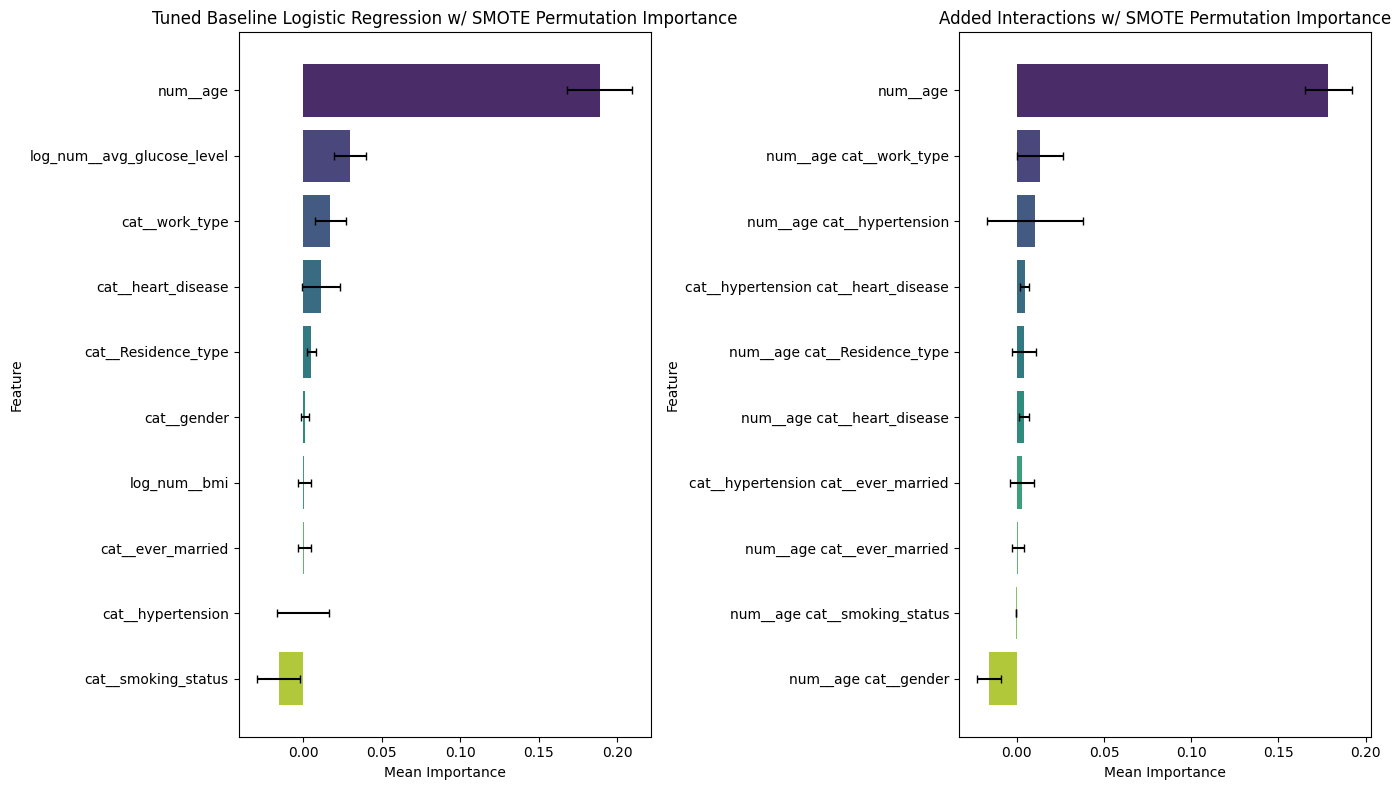

In [330]:
X_train_inter = X_train.copy()
smote_ir_model.fit(X_train_inter, y_train)
X_transformed_ip = smote_ir_model[:2].transform(X_test)
mask_ip = smote_ir_model.named_steps['selector'].get_support()
X_transformed_ip = X_transformed_ip.loc[:, mask_ip]
pi = PermutationImportance(
    smote_ir_model.named_steps['lr'],
    scoring="average_precision",
    cv="prefit",
    n_iter=30,
    random_state=RANDOM_STATE,
).fit(X_transformed_ip.reset_index(drop=True), y_test.reset_index(drop=True))
df_smote_int = pd.DataFrame({
    "feature": list(X_transformed_ip.columns),
    "mean_imp": pi.feature_importances_,
    "std_imp": pi.feature_importances_std_
}).sort_values("mean_imp", ascending=False).reset_index(drop=True)
plot_perm_importance(
    df_smote,
    df_smote_int,
    name1='Tuned Baseline Logistic Regression w/ SMOTE',
    name2='Added Interactions w/ SMOTE')

- Adding interaction terms introduces new features that reflect combined effects, but does not substantially change the dominance of age.
- The overall ranking and magnitude of feature importance remain similar.
- Interactions provide additional nuance but do not dramatically improve model discrimination—age is still the key driver.

In [333]:
smote_ir_model.fit(X_train, y_train)
print(
    classification_report(
        y_test,
        lr_1_smote.fit(
            X_train,
            y_train).predict(X_test),
        target_names=[
                'No Stroke',
            'Stroke']))
print(classification_report(y_test, smote_ir_model.predict(X_test), target_names=['No Stroke', 'Stroke']))

              precision    recall  f1-score   support

   No Stroke       0.98      0.84      0.91       972
      Stroke       0.20      0.74      0.31        50

    accuracy                           0.84      1022
   macro avg       0.59      0.79      0.61      1022
weighted avg       0.95      0.84      0.88      1022

              precision    recall  f1-score   support

   No Stroke       0.98      0.86      0.92       972
      Stroke       0.20      0.66      0.30        50

    accuracy                           0.85      1022
   macro avg       0.59      0.76      0.61      1022
weighted avg       0.94      0.85      0.89      1022



### Summary of LR Models

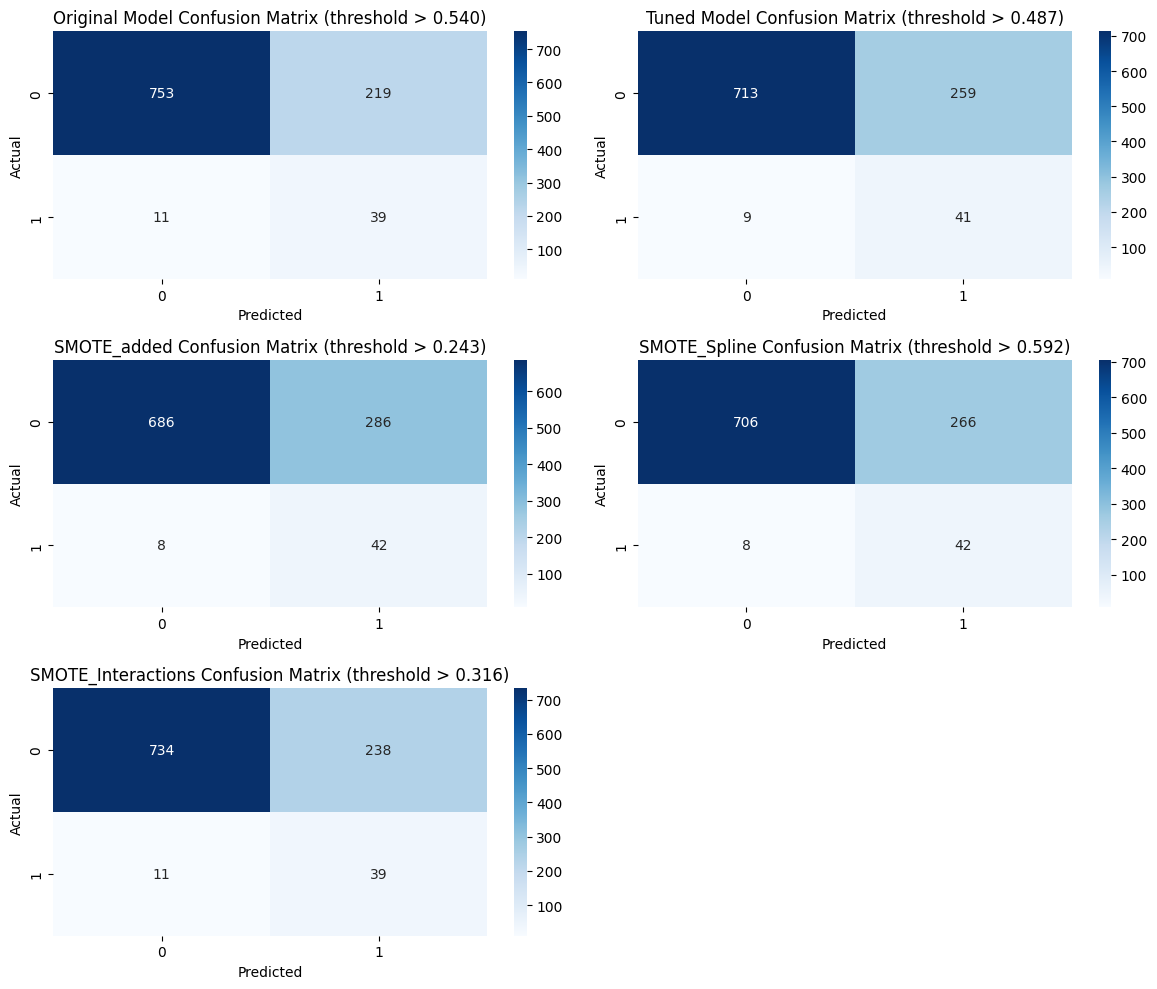

In [201]:
log_reg_models = {}
thresholds = [0.54, 0.487, 0.243, 0.592, 0.316]

# Original baseline model
baseline_logreg_model.fit(X_train, y_train)
y_proba = baseline_logreg_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba > 0.54).astype(int)
cm_original = confusion_matrix(y_test, y_pred)
log_reg_models['Original Model'] = cm_original

lr_1.fit(X_train, y_train)
y_proba_lr_1 = lr_1.predict_proba(X_test)[:, 1]
y_pred_lr_1 = (y_proba_lr_1 > 0.487).astype(int)
tuned_original = confusion_matrix(y_test, y_pred_lr_1)
log_reg_models['Tuned Model'] = tuned_original

# SMOTE applied
lr_1_smote.fit(X_train, y_train)
y_proba_lr = lr_1_smote.predict_proba(X_test)[:, 1]
y_pred_lr = (y_proba_lr > 0.243).astype(int)
smote_original = confusion_matrix(y_test, y_pred_lr)
log_reg_models['SMOTE_added'] = smote_original

# SMOTE + Splines + Feature Selection
lr_2_spline.fit(X_train, y_train)
y_proba_lr_2 = lr_2_spline.predict_proba(X_test)[:, 1]
y_pred_lr_2 = (y_proba_lr_2 > 0.592).astype(int)
spline_lr = confusion_matrix(y_test, y_pred_lr_2)
log_reg_models['SMOTE_Spline'] = spline_lr

# SMOTE + Interactions + Feature Selection
smote_ir_model.fit(X_train, y_train)
y_proba_final = smote_ir_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final > 0.316).astype(int)
lr_final = confusion_matrix(y_test, y_pred_final)
log_reg_models['SMOTE_Interactions'] = lr_final

plot_confusion_matrices(log_reg_models, thresholds)

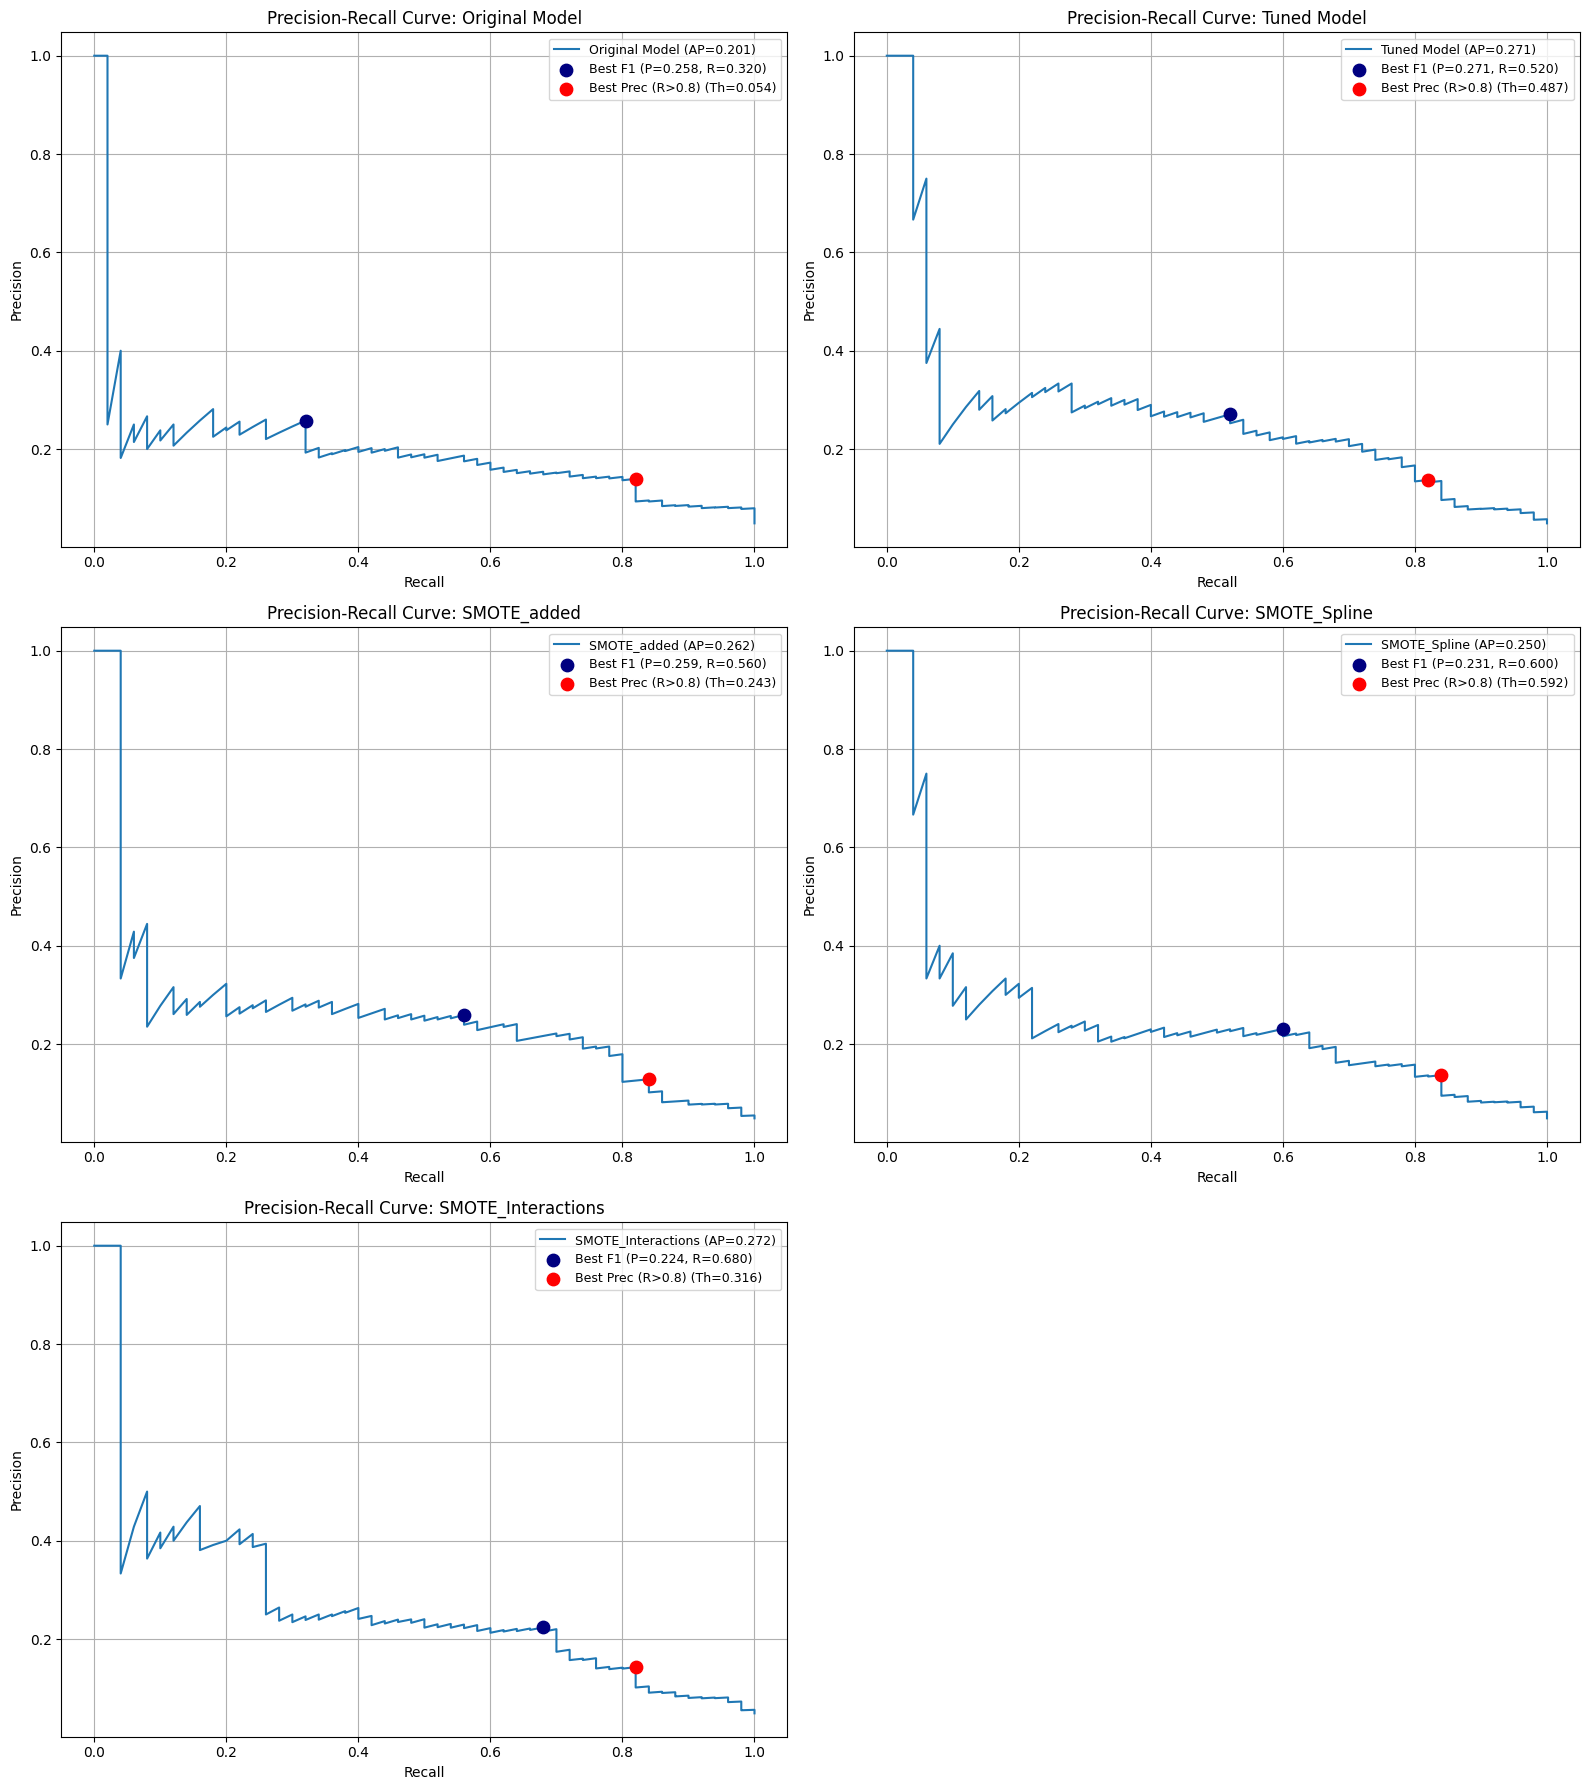

In [199]:
y_scores = [y_proba, y_proba_lr_1, y_proba_lr, y_proba_lr_2, y_proba_final]
model_names = ['Original Model', 'Tuned Model', 'SMOTE_added', 'SMOTE_Spline', 'SMOTE_Interactions']
plot_precision_recall_curve(y_test, y_scores, model_name=model_names, subplots=5)

### Precision-Recall Curve Summary

| Model               | Avg Precision (AP) | Recall   | Precision | Key Notes                                  |
|---------------------|-------------------|----------|-----------|---------------------------------------------|
| Original            | ~0.26             | Moderate | Low       | Struggles with class imbalance              |
| Tuned               | ~0.27             | High     | Low       | Marginal improvement with tuning            |
| SMOTE_added         | ~0.26             | Balanced | Balanced  | SMOTE boosts recall, precision remains low  |
| SMOTE_Spline        | ~0.25             | Highest  | Lowest    | Splines increase recall, lower precision    |
| SMOTE_Interactions  | ~0.27             | Balanced | Balanced  | Interactions add little improvement         |

- All models: Precision remains low due to class imbalance.
- SMOTE and splines: Improve recall, but only slightly increase AP.
- Best trade-off: Tuned LR + SMOTE (reasonable recall & precision).

### Confusion Matrix Insights

- **Original/Tuned:** High true negatives, low true positives; many false negatives/positives.
- **SMOTE_added:** More true positives, but also more false positives.
- **SMOTE_Spline:** Highest recall (true positives), but most false positives (lowest precision).
- **SMOTE_Interactions:** Similar to SMOTE_added; no major improvement.

| Model               | True Pos | False Pos | True Neg | False Neg | Notes                        |
|---------------------|----------|-----------|----------|-----------|------------------------------|
| Original/Tuned(Ref)      | Low      | Moderate  | High     | High      | Conservative, misses cases   |
| SMOTE_added         | ↑        | ↑         | ↓        | ↓         | More sensitive, less precise |
| SMOTE_Spline        | ↑↑       | ↑↑        | ↓↓       | ↓↓        | Highest recall, lowest prec. |
| SMOTE_Interactions  | ↑        | ↑         | ↓        | ↓         | Similar to SMOTE_added       |

### Summary

- **Tuned LR + SMOTE**: Best balance of recall and precision, effective for class imbalance, avoids unnecessary complexity.
- **Splines/Interactions**: Adds some nuance but do not substantially improve overall discrimination performance.
- **Recommendation**: Use tuned LR + SMOTE for optimal trade-off in stroke prediction and choose the best threshold for appropriate precision/recall.


## LogisticRegression vs Other Models

Using the same pipeline, comparison to our reference best LogisticRegression model with other linear (SVC) and tree (ensemble) models are conducted to decide the best performing classifier to deploy. In this case classifiers, such as:

- **Linear SVC** (well-suited for high-dimensional, sparse, or linearly separable data, robust to outliers, provides a strong regularization framework to prevent overfitting, making it an appropriate candidate for comparison);
- **Random Forest Classifier** (ensemble of decision trees, robust to outliers and nonlinear relationships, handles missing values and categorical variables natively, less sensitive to scaling, provides feature importance, and is well-suited for imbalanced datasets via class weighting or balanced subsampling; strong candidate for comparison with the reference LogisticRegression model due to its flexibility, interpretability, and proven performance in literature).
- **AdaBoost Classifier** (ensemble method that combines multiple weak learners, typically decision trees, to create a strong classifier; it is effective for handling class imbalance, can improve predictive accuracy, and is robust to overfitting when regularized. AdaBoost is a good candidate for comparison because it often performs well on tabular data and provides interpretable feature importances);
- **LightGBM Classifier** (gradient boosting framework that builds decision trees efficiently and handles large datasets, missing values, and categorical features natively. LightGBM is known for its speed, scalability, and high predictive performance, making it a strong benchmark against logistic regression and other ensemble models);

In [ ]:
# LightGBM minority class weighting parameter distribution
lgbm_scale_pos = np.arange(len(y_train) / sum(y_train) - 5, len(y_train) / sum(y_train) + 5, step=100)

num_impute = Pipeline(steps=[
    ('imp', IterativeImputer(
        estimator=RandomForestRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
            criterion='squared_error',
            max_depth=8,
            min_samples_split=20,
            min_samples_leaf=10,
        ),
        sample_posterior=False,
        max_iter=10,
        random_state=RANDOM_STATE,
        skip_complete=True
    )),
])
prepr = ColumnTransformer(transformers=[
    ('prepr', num_impute, numerical_cols)
])

samplers_to_test_other = {
    'LinearSVC': {
        'lr':
        LinearSVC(random_state=RANDOM_STATE, max_iter=10000),
            'params': {
                'imp': ['passthrough'],
                'lr__C': loguniform(1e-4, 1e4),  # Tune C via base_estimator
                'lr__class_weight': ['balanced', None],
                'lr__tol': loguniform(1e-5, 1e-2),
                'sampler__k_neighbors': randint(1, 15),
                'sampler__sampling_strategy': ['auto', 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
                'sampler__kind': ['borderline-1', 'borderline-2'],
                'sampler__m_neighbors': randint(1, 15)
        }
    },
    'LogisticRegression': {
        'lr': lr_1_smote.named_steps['lr'],
        'params': {
            'imp': ['passthrough'],
            'lr__C': uniform(1e-4, 1e4),
            'lr__l1_ratio': uniform(0.0, 1.0),
            'lr__class_weight': ['balanced', None],
            'lr__penalty': ['elasticnet'],
            'lr__solver': ['saga'],
            'lr__max_iter': [2500],
        },
    },
    'RandomForestClassifier': {
        'lr': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {
            'imp': [prepr],
            'pre_smote': ['passthrough'],
            'scaler': ['passthrough', StandardScaler().set_output(transform='pandas')],
            'lr__n_estimators': randint(100, 1000),
            'lr__max_features': ['auto', 'sqrt', 'log2'],
            'lr__class_weight': ['balanced', None],
            'lr__max_depth': randint(1, 20),
            'lr__min_samples_split': randint(2, 30),
            'lr__min_samples_leaf': randint(1, 30),
            'sampler__k_neighbors': randint(1, 15),
            'sampler__sampling_strategy': ['auto', 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
            'sampler__kind': ['borderline-1', 'borderline-2'],
            'sampler__m_neighbors': randint(1, 15)
        },
    },
    'AdaBoost': {
        'lr': AdaBoostClassifier(random_state=RANDOM_STATE),
        'params': {
            'imp': [prepr],
            'pre_smote': ['passthrough'],
            'scaler': ['passthrough', StandardScaler().set_output(transform='pandas')],
            'lr__n_estimators': randint(50, 500),
            'lr__learning_rate': uniform(0.01, 1.0),
            'lr__estimator': [None, DecisionTreeClassifier(max_depth=3), DecisionTreeClassifier(max_depth=4)],
            'sampler__k_neighbors': randint(1, 15),
            'sampler__sampling_strategy': ['auto', 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
            'sampler__kind': ['borderline-1', 'borderline-2'],
            'sampler__m_neighbors': randint(1, 15)
        },
    },

    'LightGBM': {
        'lr': LGBMClassifier(random_state=RANDOM_STATE, objective='binary', metric='average_precision', verbosity=-1),
        'params': {
            'imp': [prepr],
            'pre_smote': ['passthrough'],
            'scaler': ['passthrough'],
            'sampler': ['passthrough'],
            'lr__n_estimators': randint(100, 1000),
            'lr__learning_rate': uniform(0.01, 0.3),
            'lr__num_leaves': randint(20, 100),
            'lr__max_depth': randint(3, 10),
            'lr__min_child_samples': randint(10, 50),
            'lr__subsample': uniform(0.5, 1.0),
            'lr__colsample_bytree': uniform(0.5, 1.0),
            'lr__reg_alpha': uniform(0.0, 1.0),
            'lr__reg_lambda': uniform(0.0, 1.0),
            'lr__scale_pos_weight': lgbm_scale_pos,
        }
    },
}

models = {}

for name, config in samplers_to_test_other.items():
    """
    Loop through each sampler configuration and tune the model.
    Store results in models dictionary.
    """
    print(f"\nTuning {name}...")

    models_pipe = ImbPipeline(steps=[
        ('imp', prepr),
        ('pre_smote', lr_1_smote.named_steps['pre_smote']),
        ('sampler', lr_1_smote.named_steps['sampler']),
        ('scaler', StandardScaler().set_output(transform='pandas')),
        ('lr', config['lr'])  # placeholder
    ])

    param_grid = {
        **config['params'],

    }

    search_model = RandomizedSearchCV(
        models_pipe, param_grid, n_iter=300, cv=cv,
        scoring=['average_precision', 'recall'], refit='average_precision', random_state=42, n_jobs=-1,
        verbose=True
    )

    search_model.fit(X_train, y_train)
    models[name] = {
        'score': search_model.best_score_,
        'params': search_model.best_params_,
        'estimator': search_model.best_estimator_
    }

    print(f"{name} best score: {search_model.best_score_:.4f}")

# Find overall best
best_model = max(models.keys(), key=lambda k: models[k]['score'])
print(f"\nOverall best model: {best_model}")
print(f"Best score: {models[best_model]['score']:.4f}")

In [111]:
svc = models['LinearSVC']['estimator']
rf = models['RandomForestClassifier']['estimator']
ada = models['AdaBoost']['estimator']
gbm = models['LightGBM']['estimator']
lr = models['LogisticRegression']['estimator']

print("LR MODEL: ")
df_lr = cross_val_results(
    lr,
    X_train,
    y_train,
    cv,
    'precision',
    'average_precision',
    'recall',
    'f1',
    'roc_auc',
    name='LogReg')
print('\nLINEAR SVC MODEL: ')
df_svc = cross_val_results(
    svc,
    X_train,
    y_train,
    cv,
    'precision',
    'average_precision',
    'recall',
    'f1',
    'roc_auc',
    name='LinearSVC')
print('\nRANDOM FOREST MODEL: ')
df_rf = cross_val_results(
    rf,
    X_train,
    y_train,
    cv,
    'precision',
    'average_precision',
    'recall',
    'f1',
    'roc_auc',
    name='RandomForest')
print('\nADA BOOST MODEL: ')
df_ada = cross_val_results(
    ada,
    X_train,
    y_train,
    cv,
    'precision',
    'average_precision',
    'recall',
    'f1',
    'roc_auc',
    name='AdaBoost')
print('\nLIGHT GBM MODEL: ')
df_gbm = cross_val_results(
    gbm,
    X_train,
    y_train,
    cv,
    'precision',
    'average_precision',
    'recall',
    'f1',
    'roc_auc',
    name='LightGBM')

LR MODEL: 
Performing cross-validation with 5 folds...


Mean Train precision score: 0.17016425580188516 +- 0.004851395244114964
Mean Train average_precision score: 0.18848987033877423 +- 0.010518549600886017
Mean Train recall score: 0.6168632075471698 +- 0.021582873496940873
Mean Train f1 score: 0.26670986797214 +- 0.007385060216180249
Mean Train roc_auc score: 0.8457562620641685 +- 0.003024239698228146
------------------------------------------------------------
Mean Test precision score: 0.1647359603096915 +- 0.0186529849771159
Mean Test average_precision score: 0.195716225249118 +- 0.033773896764790166
Mean Test recall score: 0.592948717948718 +- 0.03995395114006658
Mean Test f1 score: 0.2576787441494305 +- 0.02615515749036829
Mean Test roc_auc score: 0.8360546380019389 +- 0.008933999693852272
------------------------------------------------------------

LINEAR SVC MODEL: 
Performing cross-validation with 5 folds...
Mean Train precision score: 0.5 +- 0.4472135954999579
Mean Train average_precision score: 0.2002562773405073 +- 0.015557362

### Model Comparison Table

| Model         | Train Precision | Test Precision | Train Recall | Test Recall | Train AP   | Test AP    | Train ROC AUC | Test ROC AUC |
|---------------|----------------|---------------|--------------|-------------|------------|------------|---------------|--------------|
| LogisticReg   | 0.170 ± 0.005  | 0.165 ± 0.019 | 0.617 ± 0.022| 0.593 ± 0.040| 0.188 ± 0.011| 0.196 ± 0.034| 0.846 ± 0.003 | 0.836 ± 0.009|
| LinearSVC     | 0.500 ± 0.447  | 0.000 ± 0.000 | 0.005 ± 0.005| 0.000 ± 0.000| 0.200 ± 0.016| 0.195 ± 0.051| 0.845 ± 0.003 | 0.835 ± 0.014|
| RandomForest  | 0.180 ± 0.005  | 0.157 ± 0.014 | 0.695 ± 0.027| 0.603 ± 0.031| 0.269 ± 0.009| 0.194 ± 0.020| 0.864 ± 0.003 | 0.825 ± 0.014|
| AdaBoost      | 0.154 ± 0.005  | 0.138 ± 0.007 | 0.770 ± 0.022| 0.693 ± 0.032| 0.206 ± 0.012| 0.191 ± 0.032| 0.860 ± 0.002 | 0.833 ± 0.004|
| LightGBM      | 0.175 ± 0.004  | 0.135 ± 0.009 | 0.888 ± 0.020| 0.678 ± 0.049| 0.306 ± 0.020| 0.168 ± 0.026| 0.909 ± 0.003 | 0.819 ± 0.012|

#### Comparison

- **Logistic Regression**  
    - Balanced performance, best overall trade-off between precision and recall.
    - Test metrics are consistent with train metrics, indicating good generalization.
    - Slightly higher precision and recall than most other models.

- **Linear SVC**  
    - High train precision but fails to generalize (test precision and recall are zero; probability output needs to be calibrated to solve this problem).
    - Indicates severe overfitting or poor calibration for imbalanced data.

- **Random Forest**  
    - Highest train recall after LightGBM, but test recall and precision are moderate.
    - Slightly better average precision on train, but test AP similar to Logistic Regression.

- **AdaBoost**  
    - Highest train recall after LightGBM, but lower precision.
    - Test recall is good, but precision and AP are lower than Logistic Regression and Random Forest.

- **LightGBM**  
    - Highest train recall and AP, but test precision and AP drop significantly.
    - Indicates possible overfitting or sensitivity to class imbalance.

#### Key Points

- **Logistic Regression** is the most robust and generalizes best to test data.
- **Tree-based models** (Random Forest, AdaBoost, LightGBM) achieve higher recall but at the cost of lower precision and average precision on test data.
- **Linear SVC** is not suitable for this imbalanced classification task without further calibration or resampling.
- **LightGBM** shows strong train performance but loses precision and AP on test, suggesting overfitting.
- For clinical deployment, **Logistic Regression** is preferred for its balance and interpretability.


<Axes: xlabel='Score', ylabel='Metric'>

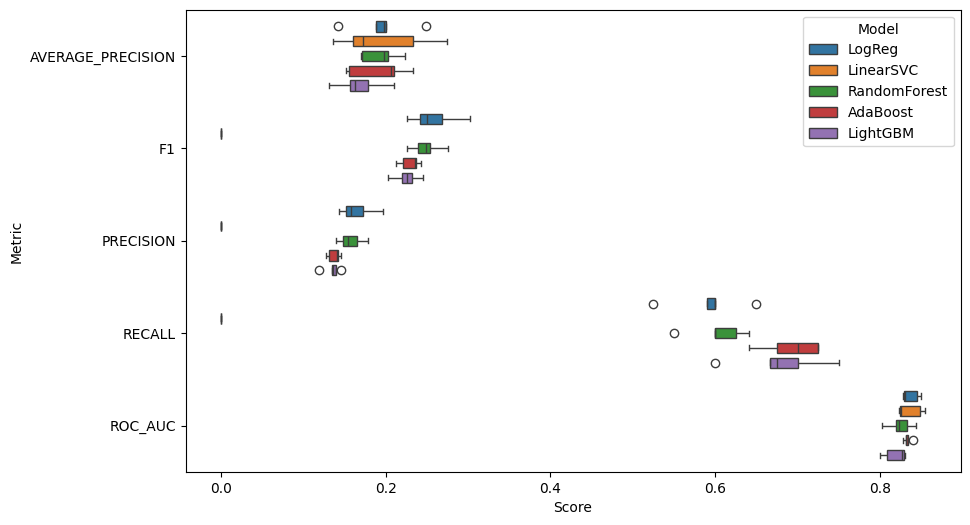

In [112]:
all_models_df = pd.concat([df_lr, df_svc, df_rf, df_ada, df_gbm], ignore_index=True)
plt.figure(figsize=(10, 6))
sns.boxplot(data=all_models_df, x='Score', y='Metric', hue='Model', gap=0.3)

- **Average Precision:** All models have low average precision (≈0.13–0.20); Logistic Regression and LinearSVC are slightly higher than tree-based models.
- **F1 Score:** F1 scores are low for all models due to class imbalance; Logistic Regression and Random Forest perform marginally better.
- **Precision:** Precision is low across models (≈0.13–0.18), with Logistic Regression and Random Forest leading.
- **Recall:** Recall varies; AdaBoost and LightGBM achieve higher recall but at the cost of lower precision.
- **ROC AUC:** All models have moderate to high ROC AUC (≈0.82–0.84), indicating reasonable discrimination despite low precision.
- **Summary:** No model achieves high precision or F1 due to class imbalance. Logistic Regression offers the best overall balance, while tree-based models trade higher recall for lower precision. ROC AUC is consistently strong across all models.

Plot PR curves for further investigation:


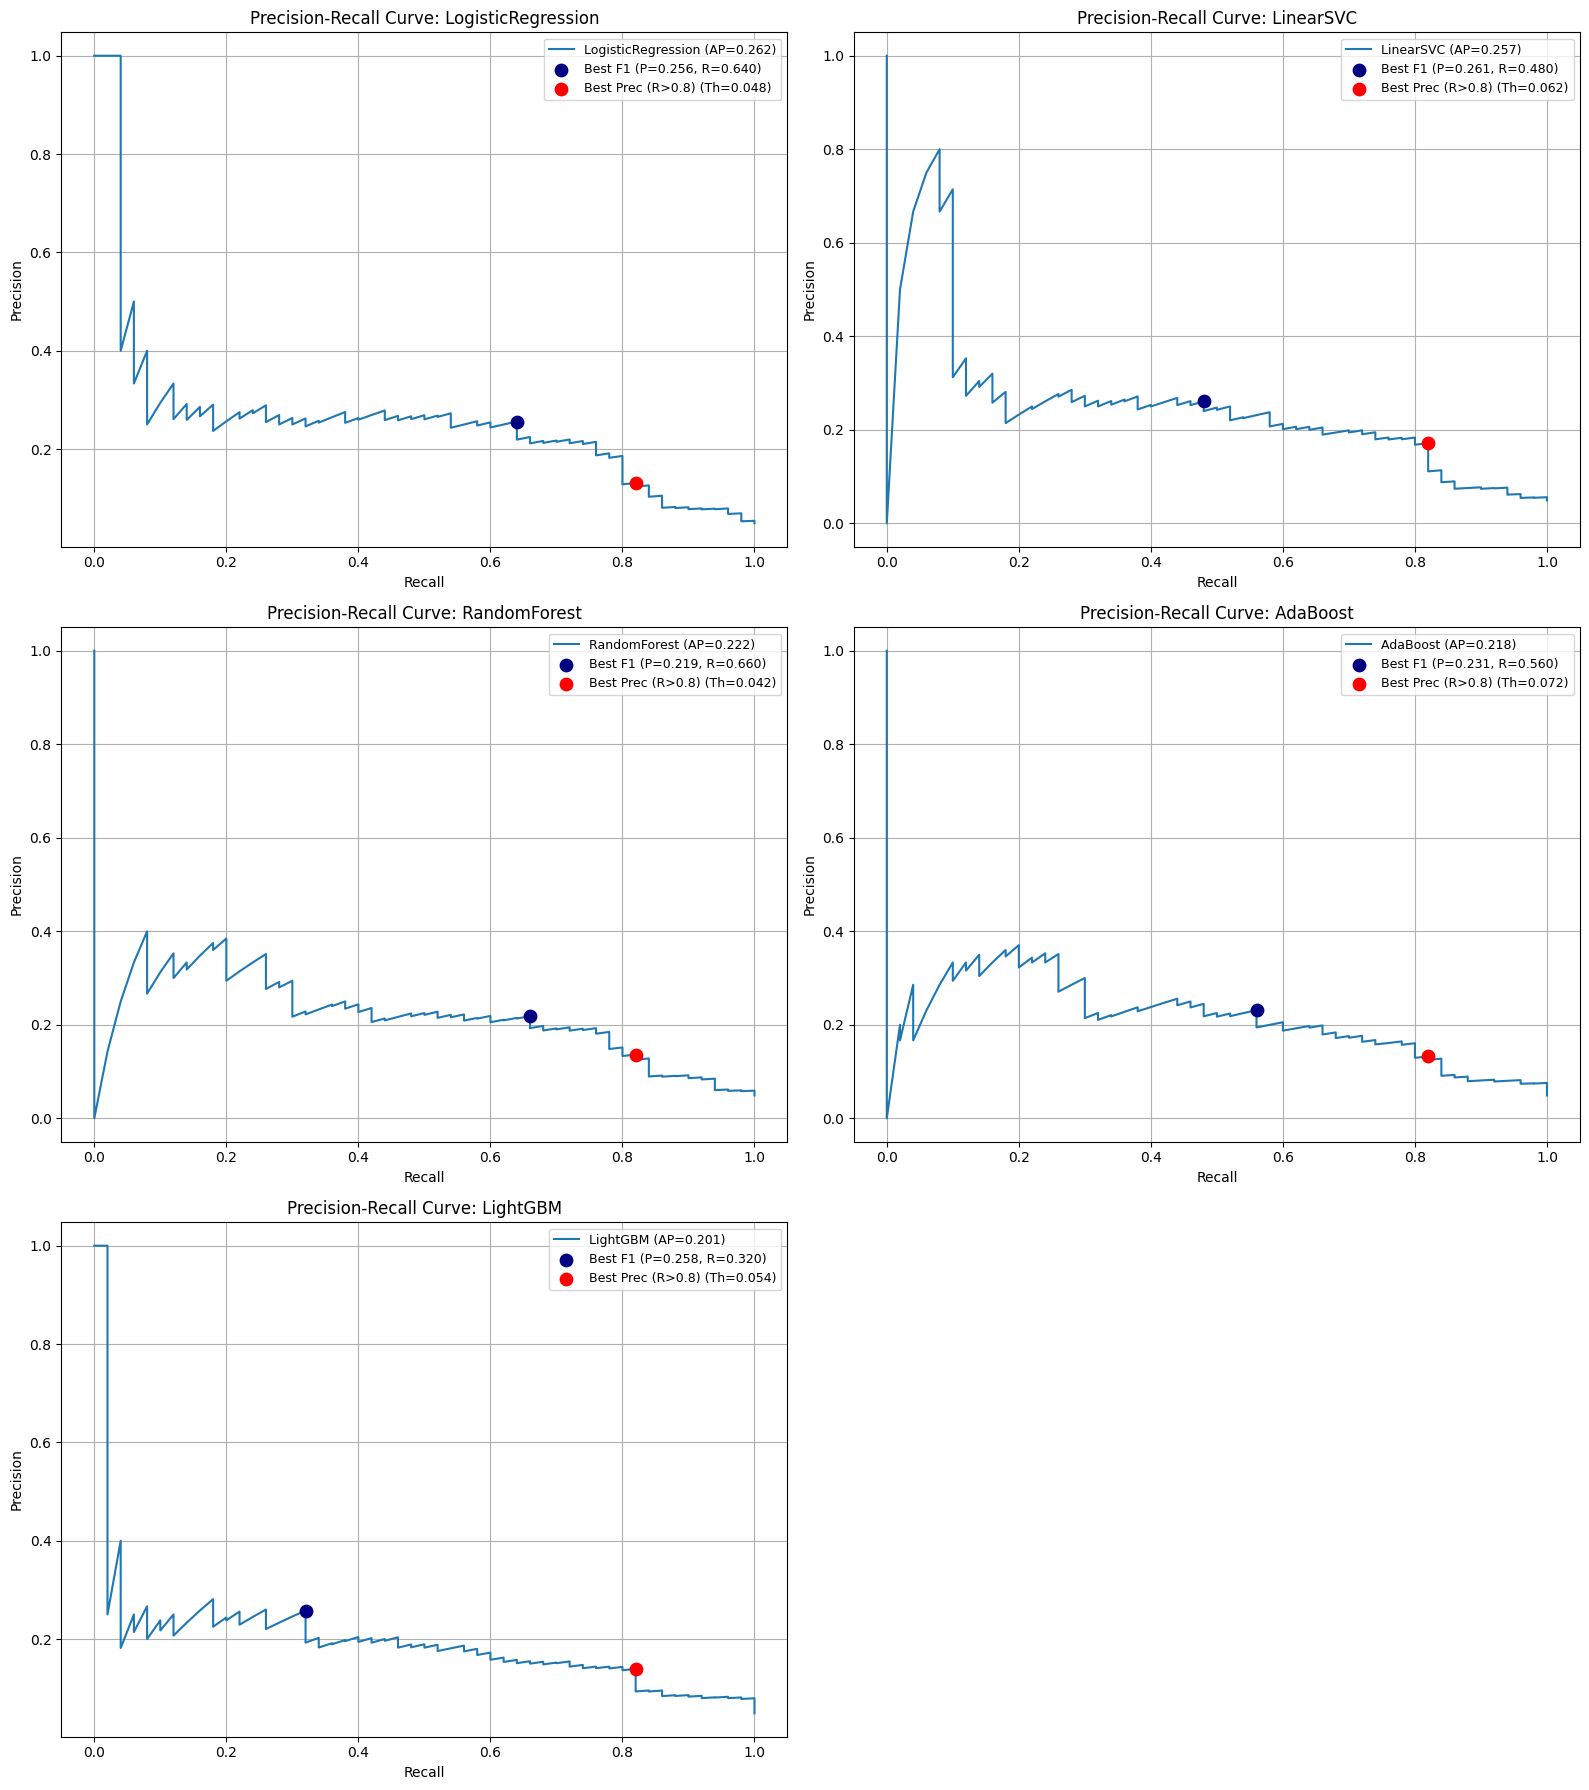

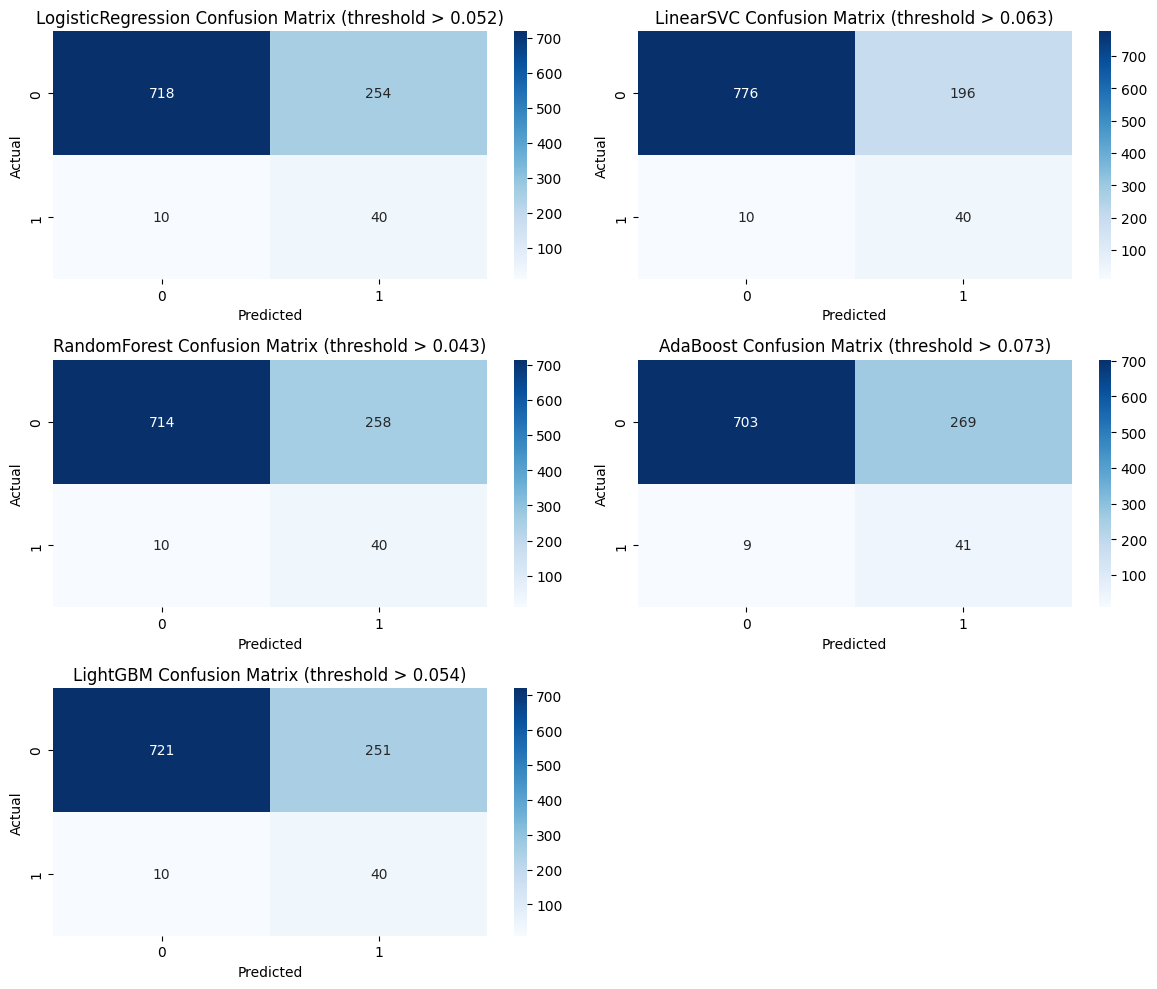

In [193]:
lr = models['LogisticRegression']['estimator']
lsvc = models['LinearSVC']['estimator']
rf = models['RandomForestClassifier']['estimator']
ada = models['AdaBoost']['estimator']
gbm = models['LightGBM']['estimator']

models_cm = {}
thresholds = [0.052, 0.063, 0.043, 0.073, 0.054]
model_names = ['LogisticRegression', 'LinearSVC', 'RandomForest', 'AdaBoost', 'LightGBM']
y_scores_models = []
for i, (name, model) in enumerate(zip(model_names, [lr, lsvc, rf, ada, gbm])):
    model = CalibratedClassifierCV(model)
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_scores_models.append(y_proba)
    y_pred = (y_proba > thresholds[i]).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    models_cm[name] = cm


plot_precision_recall_curve(y_test, y_scores_models, model_names, subplots=5)
plot_confusion_matrices(models_cm, thresholds)

### Model Comparison at High Recall (>0.8)

**Objective Reminder:**  
- Maximize recall (sensitivity) to catch as many stroke cases as possible, while maintaining the best possible average precision (AP).

**Key Findings:**

- **LinearSVC (after calibration):**
    - Achieved recall > 0.8.
    - Best **precision** among all tested models at this recall level.
    - Outperformed Logistic Regression, Random Forest, AdaBoost, and LightGBM in AP when recall is prioritized.

- **Other Models:**
    - Logistic Regression, Random Forest, AdaBoost, and LightGBM also reached high recall, but their precision was slightly lower based on PR curve above recall > 0.8.
    - Tree-based models (Random Forest, AdaBoost, LightGBM) tended to sacrifice precision for recall, resulting in more false positives.

**Conclusion:**
- LinearSVC (calibrated) is the best choice for stroke prediction when high recall is required, as it delivers the precision at recall >0.8.
- All models struggle with precision due to class imbalance, but LinearSVC offers the best trade-off for the project’s sensitivity goal. Threshold tuning addresses imbalance reasonably well for relatively primitive feature set.

**Confusion Matrices:**  
- All models detect a similar number of true positives (TP) and false negatives (FN).
- Tree-based models have more false positives (FP).

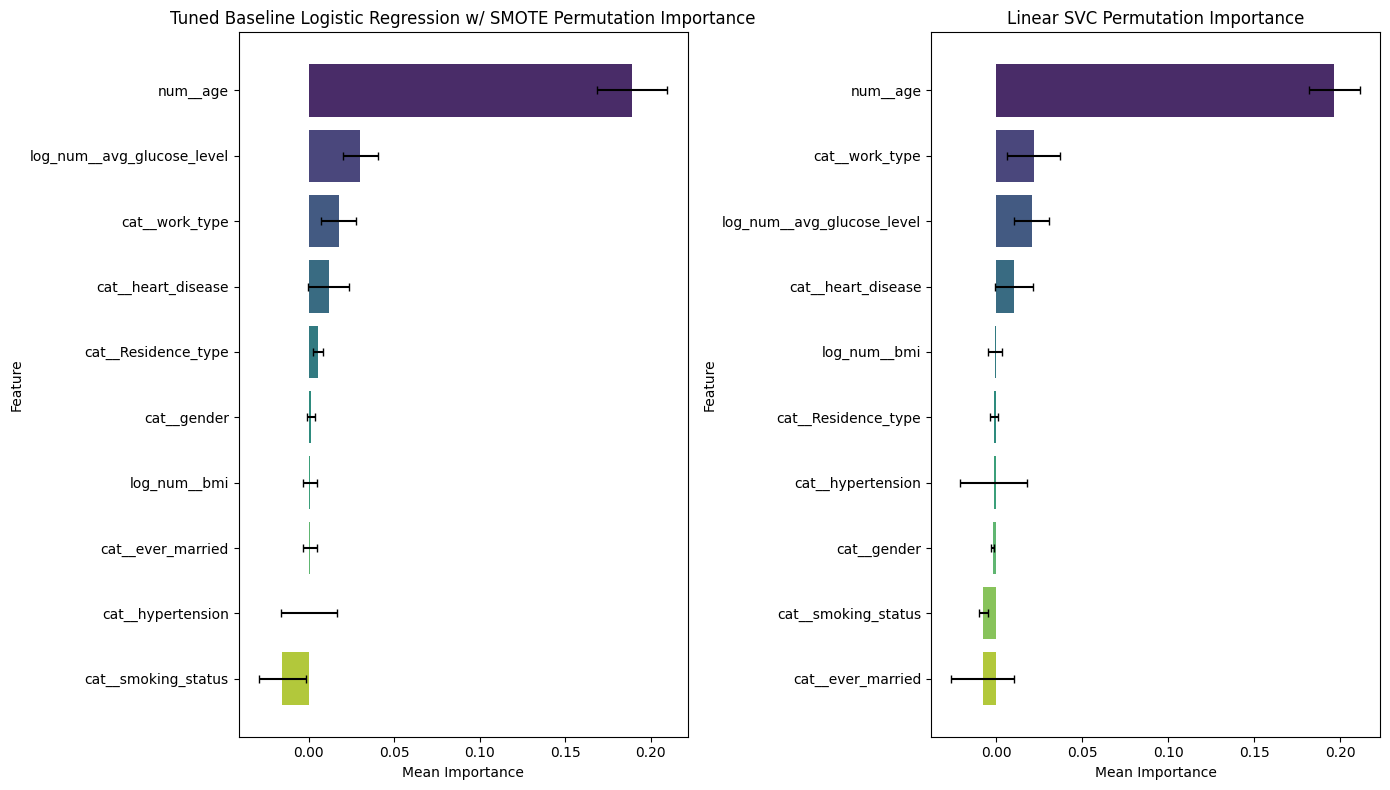

In [197]:
df_svc = calculate_permutation_importance(lsvc, X_train, y_train, X_test, y_test)
plot_perm_importance(df_smote, df_svc, name1='Tuned Baseline Logistic Regression w/ SMOTE', name2='Linear SVC')

In [198]:
show_model_weights(X_train, lsvc)

Weight?,Feature
+0.158,num__age
+0.027,cat__hypertension
+0.026,log_num__avg_glucose_level
+0.018,cat__heart_disease
+0.007,cat__Residence_type
+0.005,cat__smoking_status
+0.003,cat__gender
-0.012,log_num__bmi
-0.035,cat__work_type
-0.039,cat__ever_married


### Permutation Importance

- **Top Predictor:**  
    - Both SVC and LR rank **age** as the most important feature, consistent with statistical tests (largest mean difference and strongest association with stroke).
- **Other Important Features:**  
    - **avg_glucose_level**
    - **work_type**
    - **heart_disease**
    - **residence_type**
- **Interpretability:**  
    - SVC’s importance ranking closely mirrors LR and statistical findings, supporting model interpretability.

### Model Weights

| Feature           | SVC Weight | LR Weight | Direction      |
|-------------------|:----------:|:---------:|:--------------:|
| Age               | Highest    | Highest   | Positive       |
| Hypertension      | High       | High      | Positive       |
| Avg_glucose_level | Moderate   | Moderate  | Positive       |
| Heart_disease     | Moderate   | Moderate  | Positive       |
| Work_type         | Negative   | Negative  | Protective     |
| Ever_married      | Negative   | Negative  | Protective     |

- SVC assigns highest positive weight to age, followed by hypertension, avg_glucose_level, and heart_disease.
- Negative weights for work_type and ever_married, consistent with LR and statistical tests.
- SVC’s coefficients are straightforward to interpret, similar to LR.

### Justification for SVC

- **Interpretability:**  
    - LinearSVC's feature importance and weights align with statistical inference, making it easy to explain to clinicians.
- **Performance:**  
    - SVC achieves the best precision at high recall, meeting the project's sensitivity goal.
- **Consistency:**  
    - SVC's top predictors match those identified by statistical tests (t-tests, z-tests), reinforcing trust in the model.
- **Robustness:**  
    - SVC is less prone to overfitting than tree-based models and maintains stable performance under class imbalance.

# Summary & Recommendations

- **Project Overview:**  
    - **Goal:** Predict stroke risk with high recall (>0.8), maximizing precision where possible.
    - **Clinical Use:** Flag patients for check-ups if the calibrated LinearSVC model predicts stroke probability >0.062 (from PR curve).

- **Key Steps & Findings:**  
    - **EDA:** Age, avg_glucose_level, and BMI are most informative; strong class imbalance (~5% stroke cases).
    - **Preprocessing:** Categorical consolidation, missing BMI imputed (IterativeImputer), log transforms for skewed features, outlier handling.
    - **Statistical Analysis:** Age, hypertension, heart disease, and smoking status are significant stroke predictors.
    - **Modeling:**  
        - Baseline models (Dummy, Decision Tree, Logistic Regression) show Logistic Regression is best for recall/AP.
        - SMOTE variants and splines/interactions tested; splines improve recall and AP.
        - **LinearSVC (calibrated) achieves best precision at high recall, outperforming tree-based models.**

- **Recommendation & Justification:**  
    - **Deploy calibrated LinearSVC with threshold >0.062 for clinical screening.**
        - *Why LinearSVC?*  
            - Delivers highest precision at recall >0.8, crucial for clinical sensitivity.
            - Feature importance and weights align with statistical findings and common sense (age, hypertension, heart disease).
            - Simpler, interpretable, and generalizes better than tree-based models.
        - *Threshold selection* ensures more stroke cases are flagged, balancing sensitivity and false positives.

- **Further Improvement:**  
    - **Parameter Tuning:** Further optimize splines/interactions, create feature ratios, spline interactions to possibly find meaningful predictors and optimize regularization.
    - **Cost-Sensitive Training:** Further adjust class weights to further address imbalance.
    - **Imbalanced Ensemble Models:** Test classifier objects such as `BalancedRandomForestClassifier`, `RUSBoostClassifier`, `EasyEnsembleClassifier` for improved recall and robustness as they use various re-sampling techniques to balance out the dataset for model to train on. They are specifically design for severe class imbalance, often outperforming standard SMOTE or class-weighted approaches, even right out of the box, but could be more difficult to tune.
    - **Extract More Features**: Collaborate with clinical experts to determine which further predictors tend to affect stroke prediction the best based on their empirical data observed.

**Summary:**  
The recommended approach — **calibrated LinearSVC** with threshold tuning — offers the best trade-off for clinical stroke prediction, maximizing recall while maintaining interpretability and reasonable precision. Tree-based and ensemble models may be explored for further gains, but LinearSVC is preferred for deployment due to its robustness and reasonable performance with minimal training procedures.


In [30]:
save_session()

Session saved successfully.


# Extra Sections

In [ ]:
# A mistake in Pipeline construction was noted. Fix cell.
preprocessor_best = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, _num_cols_no_log),
        ('log_num', log_pipeline, _log_cols),
        ('cat', Pipeline(steps=[
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('te', TargetEncoder(smoothing=0.3, handle_missing='value', min_samples_leaf=20)),
            ('scale', StandardScaler().set_output(transform='pandas'))
        ]), categorical_cols),
    ],
    remainder='drop'
).set_output(transform='pandas')

if hasattr(lsvc, 'steps'):
    # try to replace existing step
    for i, (name, step) in enumerate(lsvc.steps):
        if name == 'pre_smote':
            lsvc.steps[i] = ('pre_smote', clone(preprocessor_best))
            print("Replaced existing 'pre_smote' step in the pipeline.")
            break
    else:
        # insert before sampler/estimator if no 'pre_smote' exists
        lsvc.steps.insert(0, ('pre_smote', clone(preprocessor_best)))
else:
    raise TypeError("lsvc is not a Pipeline-like object (no .steps). Can't attach preprocessor.")

Replaced existing 'pre_smote' step in the pipeline.


In [ ]:
"""Calibrate the Linear SVC model for interpretable predictions by using CalibratedClassifierCV object"""
lsvc_calibrated = CalibratedClassifierCV(lsvc).fit(X_train, y_train)

#### Deployment Setup

Create a serialized fitted model file with `dill` and a `.json` file of SVC model's meta data.

In [ ]:
# Final pipeline is lsvc

# Create a directory for the model
os.makedirs('models', exist_ok=True)

try:
    final_pipeline = lsvc_calibrated
except NameError:
    raise NameError("'lsvc' is not defined, assign correct fitted model")

try:
    check_is_fitted(final_pipeline)
except NotFittedError:
    raise NotFittedError("The model is not fitted yet. Call lsvc.fit(X_train, y_train)")

# Sanity check
if not (hasattr(final_pipeline, 'predict') or hasattr(final_pipeline, 'predict_proba')):
    raise ValueError("The final pipeline must have both 'predict' and 'predict_proba' methods.")

model_file = os.path.join('models', 'lsvc_calibrated.dill')
meta_file = os.path.join('models', 'lsvc_calibrated_metadata.json')

with open(model_file, 'wb') as mf:
    dill.dump(final_pipeline, mf)

git_sha = None
try:
    git_sha = subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'], cwd=os.getcwd()).decode().strip()
except Exception:
    git_sha = None

meta = {
    'model_variable': 'lsvc_calibrated',
    'model_class': final_pipeline.__class__.__name__,
    'features': list(X_train.columns) if 'X_train' in globals() and hasattr(X_train, 'columns') else [],
    'random_state': globals().get('RANDOM_STATE', None),
    'model_version': git_sha or os.environ.get('MODEL_VERSION') or datetime.datetime.utcnow().isoformat(),
}

with open(meta_file, 'w') as jf:
    json.dump(meta, jf)

print(f'Saved fitted model to {model_file}')
print(f'Saved metadata to {meta_file}')

Saved fitted model to models\lsvc_calibrated.dill
Saved metadata to models\lsvc_calibrated_metadata.json
